In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from sklearn.metrics import mean_squared_error

In [ ]:
dataset=pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
print(dataset.head(5))
print(dataset.shape)

  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0    None  288.28      0.0      0.0          40       Clouds   
1    None  289.36      0.0      0.0          75       Clouds   
2    None  289.58      0.0      0.0          90       Clouds   
3    None  290.13      0.0      0.0          90       Clouds   
4    None  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds   2012-10-02 9:00:00            5545  
1       broken clouds  2012-10-02 10:00:00            4516  
2     overcast clouds  2012-10-02 11:00:00            4767  
3     overcast clouds  2012-10-02 12:00:00            5026  
4       broken clouds  2012-10-02 13:00:00            4918  
(48204, 9)


### Data exploration - Histogram analysis of target variable

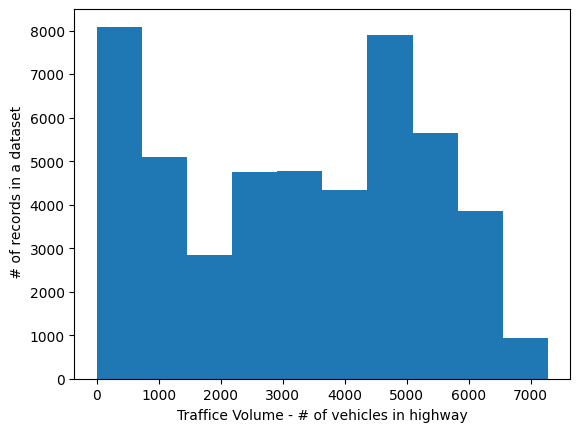

In [ ]:
plt.hist(dataset['traffic_volume'])
plt.xlabel("Traffice Volume - # of vehicles in highway")
plt.ylabel(" # of records in a dataset")
plt.show()

# Data Cleaning

In [ ]:
#remove duplicates
dataset = dataset.drop_duplicates(subset='date_time', keep='first')

In [ ]:
#split date_time attribute to two different columns, date and time
dataset[['date','time']] = dataset.date_time.str.split(expand=True)

#converting temp unit Kelvin to Fahrenheit
dataset["temp"] = round((dataset["temp"]-273.15)*9/5+32)

**Correcting Holidays**

In [ ]:
dataset["holiday"].unique()

array(['None', 'Columbus Day', 'Veterans Day', 'Thanksgiving Day',
       'Christmas Day', 'New Years Day', 'Washingtons Birthday',
       'Memorial Day', 'Independence Day', 'State Fair', 'Labor Day',
       'Martin Luther King Jr Day'], dtype=object)

In [ ]:
dataset[['year', 'month', 'day']] = dataset.date.str.split("-", expand = True)

In [ ]:
dataset['holiday'] = "None"

In [ ]:
dataset["month-day"] = dataset[["month", "day"]].apply("-".join, axis=1)
dataset = dataset.drop(['month'], axis=1)
dataset = dataset.drop(['day'], axis=1)

In [ ]:
dataset.loc[dataset['month-day'] == "12-25", 'holiday'] = 'Christmas Day'
dataset.loc[dataset['month-day'] == "07-04", 'holiday'] = 'Independence Day'
dataset.loc[dataset['month-day'] == "01-01", 'holiday'] = 'New Years Day'
dataset.loc[dataset['month-day'] == "12-24", 'holiday'] = 'Christmas Eve'
dataset.loc[dataset['month-day'] == "12-31", 'holiday'] = 'New Years Eve'
dataset.loc[dataset['month-day'] == "11-11", 'holiday'] = 'Veterans Day'
dataset.loc[dataset['date'] == "2012-10-08", 'holiday'] = 'Columbus Day'
dataset.loc[dataset['date'] == "2013-10-14", 'holiday'] = 'Columbus Day'
dataset.loc[dataset['date'] == "2014-10-13", 'holiday'] = 'Columbus Day'
dataset.loc[dataset['date'] == "2015-10-12", 'holiday'] = 'Columbus Day'
dataset.loc[dataset['date'] == "2016-10-10", 'holiday'] = 'Columbus Day'
dataset.loc[dataset['date'] == "2017-10-09", 'holiday'] = 'Columbus Day'
dataset.loc[dataset['date'] == "2018-10-08", 'holiday'] = 'Columbus Day'
dataset.loc[dataset['date'] == "2018-11-22", 'holiday'] = 'Thanksgiving Day'
dataset.loc[dataset['date'] == "2017-11-23", 'holiday'] = 'Thanksgiving Day'
dataset.loc[dataset['date'] == "2016-11-24", 'holiday'] = 'Thanksgiving Day'
dataset.loc[dataset['date'] == "2015-11-26", 'holiday'] = 'Thanksgiving Day'
dataset.loc[dataset['date'] == "2014-11-27", 'holiday'] = 'Thanksgiving Day'
dataset.loc[dataset['date'] == "2013-11-28", 'holiday'] = 'Thanksgiving Day'
dataset.loc[dataset['date'] == "2012-11-22", 'holiday'] = 'Thanksgiving Day'
dataset.loc[dataset['date'] == "2012-02-20", 'holiday'] = 'Presidents Day'
dataset.loc[dataset['date'] == "2013-02-18", 'holiday'] = 'Presidents Day'
dataset.loc[dataset['date'] == "2014-02-17", 'holiday'] = 'Presidents Day'
dataset.loc[dataset['date'] == "2015-02-16", 'holiday'] = 'Presidents Day'
dataset.loc[dataset['date'] == "2016-02-15", 'holiday'] = 'Presidents Day'
dataset.loc[dataset['date'] == "2017-02-20", 'holiday'] = 'Presidents Day'
dataset.loc[dataset['date'] == "2018-02-19", 'holiday'] = 'Presidents Day'
dataset.loc[dataset['date'] == "2018-05-28", 'holiday'] = 'Memorial Day'
dataset.loc[dataset['date'] == "2017-05-29", 'holiday'] = 'Memorial Day'
dataset.loc[dataset['date'] == "2016-05-30", 'holiday'] = 'Memorial Day'
dataset.loc[dataset['date'] == "2015-05-25", 'holiday'] = 'Memorial Day'
dataset.loc[dataset['date'] == "2014-05-26", 'holiday'] = 'Memorial Day'
dataset.loc[dataset['date'] == "2013-05-27", 'holiday'] = 'Memorial Day'
dataset.loc[dataset['date'] == "2012-05-28", 'holiday'] = 'Memorial Day'
dataset.loc[dataset['date'] == "2012-08-23", 'holiday'] = 'First Day State Fair'
dataset.loc[dataset['date'] == "2013-08-22", 'holiday'] = 'First Day State Fair'
dataset.loc[dataset['date'] == "2014-08-21", 'holiday'] = 'First Day State Fair'
dataset.loc[dataset['date'] == "2015-08-27", 'holiday'] = 'First Day State Fair'
dataset.loc[dataset['date'] == "2016-08-25", 'holiday'] = 'First Day State Fair'
dataset.loc[dataset['date'] == "2017-08-24", 'holiday'] = 'First Day State Fair'
dataset.loc[dataset['date'] == "2018-08-23", 'holiday'] = 'First Day State Fair'
dataset.loc[dataset['date'] == "2018-09-03", 'holiday'] = 'Labor Day'
dataset.loc[dataset['date'] == "2017-09-04", 'holiday'] = 'Labor Day'
dataset.loc[dataset['date'] == "2016-09-05", 'holiday'] = 'Labor Day'
dataset.loc[dataset['date'] == "2015-09-07", 'holiday'] = 'Labor Day'
dataset.loc[dataset['date'] == "2014-09-01", 'holiday'] = 'Labor Day'
dataset.loc[dataset['date'] == "2013-09-02", 'holiday'] = 'Labor Day'
dataset.loc[dataset['date'] == "2012-09-03", 'holiday'] = 'Labor Day'
dataset.loc[dataset['date'] == "2012-01-16", 'holiday'] = 'Martin Luther King Jr Day'
dataset.loc[dataset['date'] == "2013-01-21", 'holiday'] = 'Martin Luther King Jr Day'
dataset.loc[dataset['date'] == "2014-01-20", 'holiday'] = 'Martin Luther King Jr Day'
dataset.loc[dataset['date'] == "2015-01-19", 'holiday'] = 'Martin Luther King Jr Day'
dataset.loc[dataset['date'] == "2016-01-18", 'holiday'] = 'Martin Luther King Jr Day'
dataset.loc[dataset['date'] == "2017-01-16", 'holiday'] = 'Martin Luther King Jr Day'
dataset.loc[dataset['date'] == "2018-01-15", 'holiday'] = 'Martin Luther King Jr Day'
#display(dataset[dataset["holiday"]=="Christmas"])

**Modifying Date and Time**

In [ ]:
#converting date to number of day
dataset['weekday'] = pd.DatetimeIndex(dataset['date']).weekday
dataset = dataset.drop(columns=['date'])

#converting time to hour in day
dataset['time'] = pd.DatetimeIndex(dataset['time']).hour

**Removing Redundant Columns**

In [ ]:
dataset = dataset.drop(['date_time'], axis=1)
dataset = dataset.drop(['year'], axis=1)
dataset = dataset.drop(['month-day'], axis=1)
dataset = dataset.drop(['weather_description'], axis=1)

In [ ]:
dataset['holiday'].mask(dataset['holiday'] != 'None' ,1, inplace=True)
dataset['holiday'].mask(dataset['holiday'] == 'None' ,0, inplace=True)

In [ ]:
dataset.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,traffic_volume,time,weekday
0,0,59.0,0.0,0.0,40,Clouds,5545,9,1
1,0,61.0,0.0,0.0,75,Clouds,4516,10,1
2,0,62.0,0.0,0.0,90,Clouds,4767,11,1
3,0,63.0,0.0,0.0,90,Clouds,5026,12,1
4,0,64.0,0.0,0.0,75,Clouds,4918,13,1


In [ ]:
#Extracting the independent and dependent variables
X = dataset.iloc[:, dataset.columns != 'traffic_volume'].values
y = dataset.iloc[:, dataset.columns == 'traffic_volume'].values

In [ ]:
#Converting to numpy array
X = np.array(X)
y = np.array(y)

In [ ]:
print(X[0,:])

[0 59.0 0.0 0.0 40 'Clouds' 9 1]


In [ ]:
#One Hot Encoding Categorical Columns
from sklearn.preprocessing import OneHotEncoder

non_categorical_Cols = X[:,[0,1,2,3,4,6,7]]
categorical_Cols = X[:,[5]]

OHE = OneHotEncoder(sparse_output= False, drop= 'first')

categorical_cols_ohe = OHE.fit_transform(categorical_Cols)
X = np.concatenate((non_categorical_Cols,categorical_cols_ohe),axis = 1)

In [ ]:
#Splitting the data into training and testing set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Splitting the data into training and validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [ ]:
#Normalizing the Data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
X_train.shape

(24345, 17)

**The final columns produced from the One Hot Encoding are:**
0. Holiday
1. Temp
2. Rain_1h
3. Snow_1h
4. Clouds_all
5. Time
6. Weekday
7. Clouds
8. Drizzle
9. Fog
10. Haze
11. Mist
12. Rain
13. Smoke
14. Snow
15. Squall
16. Thunderstorm

### Run all models on all features
(Features considered are
Holiday
Temp
Rain_1h
Snow_1h
Clouds_all
Time
Weekday
Clouds
Drizzle
Fog
Haze
Mist
Rain
Smoke
Snow
Squall
Thunderstorm)

### Run Linear Regression on all features

In [ ]:
#Linear Regression
from sklearn.linear_model import LinearRegression
LnReg = LinearRegression()
LnReg.fit(X_train,y_train)

#Prediction on Val Set
y_val_pred = LnReg.predict(X_val)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = LnReg.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  3255941.0971760983
MSE on Test Set:  3234522.018308135
RMSE on Val Set:  1804.4226492637745
RMSE on Test Set:  1798.4776946929687


### Run Decision Tree on all features

In [ ]:
#DecisionTree
from sklearn.tree import DecisionTreeRegressor
regObj = DecisionTreeRegressor()
regObj.fit(X_train,y_train)

#prediciton on Val set
y_val_pred = regObj.predict(X_val)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = regObj.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  326171.85166074487
MSE on Test Set:  318813.0439613541
RMSE on Val Set:  571.1145696449573
RMSE on Test Set:  564.6353194419864


### Optimal - Polynomial Regression on all features - 3 Components

In [ ]:
#Polynomial
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

polyFeatureObj = PolynomialFeatures(degree=3)
X_poly = polyFeatureObj.fit_transform(X_train)
X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
prObj = LinearRegression()
prObj.fit(X_poly, y_train)

#prediction on Val set
v= polyFeatureObj.fit_transform(X_val)
v = v[:,1:]
y_val_pred=prObj.predict(v)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#prediction on Test set
v= polyFeatureObj.fit_transform(X_test)
v = v[:,1:]
y_test_pred=prObj.predict(v)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  1148041.2256992243
MSE on Test Set:  973454.8175374892
RMSE on Val Set:  1071.4668570232232
RMSE on Test Set:  986.6381391054621


### Run Random Forest on all features

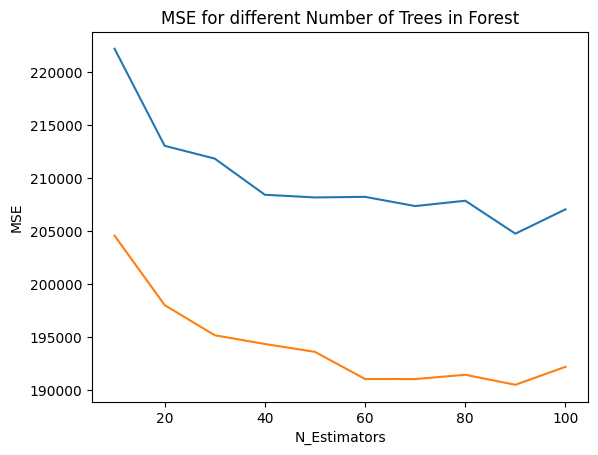

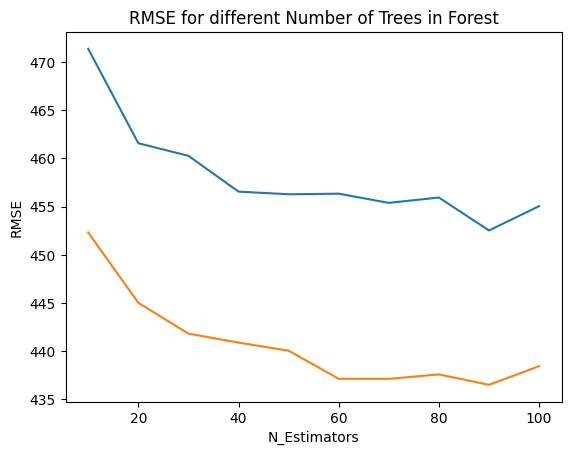

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

tree_count = np.arange(10,110,10)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for trees in tree_count:
    RF_regObj = RandomForestRegressor(n_estimators=trees)
    RF_regObj.fit(X_train,y_train.ravel())

    #prediciton on Val set
    y_val_pred = RF_regObj.predict(X_val)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #Prediction on Test Set
    y_test_pred = RF_regObj.predict(X_test)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(tree_count, mse_val_list)
plt.plot(tree_count, mse_test_list)
plt.title('MSE for different Number of Trees in Forest')
plt.xlabel('N_Estimators')
plt.ylabel('MSE')
plt.show()

plt.plot(tree_count, rmse_val_list)
plt.plot(tree_count, rmse_test_list)
plt.title('RMSE for different Number of Trees in Forest')
plt.xlabel('N_Estimators')
plt.ylabel('RMSE')
plt.show()

### Optimal Random Forest on all features - 30 Estimators

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

RF_regObj = RandomForestRegressor(n_estimators=50)
RF_regObj.fit(X_train,y_train.ravel())

#prediciton on Val set
y_val_pred = RF_regObj.predict(X_val)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = RF_regObj.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  208171.45741287505
MSE on Test Set:  190524.99296664997
RMSE on Val Set:  456.2581039421383
RMSE on Test Set:  436.49168716786573


### Run AdaBoost on all features

In [ ]:
#AdaBoost
from sklearn.ensemble import AdaBoostRegressor
AB_regObj = AdaBoostRegressor()
AB_regObj.fit(X_train,y_train.ravel())

#prediciton on Val set
y_val_pred = AB_regObj.predict(X_val)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = AB_regObj.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  537456.8369888844
MSE on Test Set:  530988.8347985552
RMSE on Val Set:  733.1144774105095
RMSE on Test Set:  728.6898069813761


### Run GradientBoost on all features

In [ ]:
#GradientBoost
from sklearn.ensemble import GradientBoostingRegressor
GB_regObj = GradientBoostingRegressor()
GB_regObj.fit(X_train,y_train.ravel())

#prediciton on Val set
y_val_pred = GB_regObj.predict(X_val)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = GB_regObj.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  281851.0675646795
MSE on Test Set:  278140.0999592952
RMSE on Val Set:  530.896475374135
RMSE on Test Set:  527.389893683312


### Run XGboost on all features

In [ ]:
#XGBoost
from xgboost import XGBRegressor
XGB_regObj = XGBRegressor()
XGB_regObj.fit(X_train,y_train)

#prediciton on Val set
y_val_pred = XGB_regObj.predict(X_val)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = XGB_regObj.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  168294.46853303091
MSE on Test Set:  154318.22392509057
RMSE on Val Set:  410.23708819782604
RMSE on Test Set:  392.8335829904192


### Backward elimination done and below are identified as significant features
0. Holiday
1. Temp
2. Rain_1h
3. Snow_1h
4. Clouds_all
5. Clouds
6. Drizzle
7. Fog
8. Haze
9. Smoke


In [ ]:
#Backward Elimination
import statsmodels.api as sm

X_train = np.append(arr=np.ones((24345,1)), values=X_train, axis=1)

def backwardElimination(x, y, sl):
    numVars = len(x[0])
    for i in range(0, numVars):
        obj_OLS = sm.OLS(endog = y, exog = x).fit()
        maxVar = max(obj_OLS.pvalues).astype(float)
        if maxVar > sl:
            for j in range(0, numVars - i):
                if (obj_OLS.pvalues[j].astype(float) == maxVar):
                    x = np.delete(x, j, 1)
    return x

SL = 0.05
X_train_sig = X_train[:, [0, 1, 2, 3, 4, 5,6,7,8,9,10,11,12,13,14,15,16,17]]
X_Modeled = backwardElimination(X_train_sig, y_train, SL)

In [ ]:
#Removing the column of 1s at the beginning of the training set
X_train = X_train[:,1:]

#Retaining only siginifcant columns (10 columns)
X_train_sig = X_train[:,[1, 2, 3, 4, 5, 8, 9, 10, 11, 14]]
X_val_sig= X_val[:,[0, 1, 2, 3, 4, 7, 8, 9, 10, 13]]
X_test_sig = X_test[:,[0, 1, 2, 3, 4, 7, 8, 9, 10, 13]]

### Use significant features and run all regression models

### Run Linear Regression on significant features

In [ ]:
#Linear Regression
from sklearn.linear_model import LinearRegression
LnReg = LinearRegression()
LnReg.fit(X_train_sig,y_train)

#Prediction on Val Set
y_val_pred = LnReg.predict(X_val_sig)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = LnReg.predict(X_test_sig)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  4254038.079802647
MSE on Test Set:  4281168.980273137
RMSE on Val Set:  2062.531958492437
RMSE on Test Set:  2069.0985912404312


### Run Desicion Tree on significant features

In [ ]:
#DecisionTree
from sklearn.tree import DecisionTreeRegressor
regObj = DecisionTreeRegressor()
regObj.fit(X_train_sig,y_train)

#prediciton on Val set
y_val_pred = regObj.predict(X_val_sig)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = regObj.predict(X_test_sig)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  6863954.5335954
MSE on Test Set:  6834207.391853221
RMSE on Val Set:  2619.9149859480935
RMSE on Test Set:  2614.2317020213072


### Run Polynomial Regression on significant features

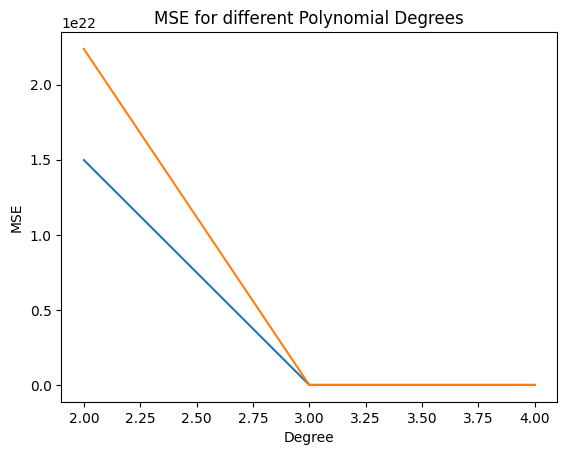

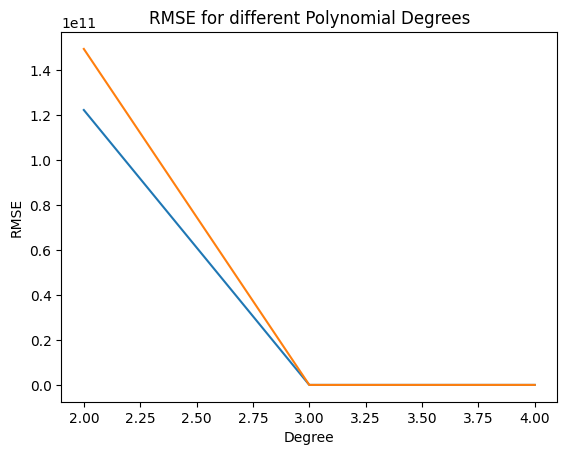

In [ ]:
#Polynomial
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

degrees = np.arange(2,5)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for d in degrees:
    polyFeatureObj = PolynomialFeatures(degree=d)
    X_poly = polyFeatureObj.fit_transform(X_train_sig)
    X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
    prObj = LinearRegression()
    prObj.fit(X_poly, y_train)

    #prediction on Val set
    v= polyFeatureObj.fit_transform(X_val_sig)
    v = v[:,1:]
    y_val_pred=prObj.predict(v)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #prediction on Test set
    v= polyFeatureObj.fit_transform(X_test_sig)
    v = v[:,1:]
    y_test_pred=prObj.predict(v)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(degrees, mse_val_list)
plt.plot(degrees, mse_test_list)
plt.title('MSE for different Polynomial Degrees')
plt.xlabel('Degree')
plt.ylabel('MSE')
plt.show()

plt.plot(degrees, rmse_val_list)
plt.plot(degrees, rmse_test_list)
plt.title('RMSE for different Polynomial Degrees')
plt.xlabel('Degree')
plt.ylabel('RMSE')
plt.show()


### Optimal - Polynomial Regression on significant features - 3 Components

In [ ]:
polyFeatureObj = PolynomialFeatures(degree=3)
X_poly = polyFeatureObj.fit_transform(X_train_sig)
X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
prObj = LinearRegression()
prObj.fit(X_poly, y_train)

#prediction on Val set
v= polyFeatureObj.fit_transform(X_val_sig)
v = v[:,1:]
y_val_pred=prObj.predict(v)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#prediction on Test set
v= polyFeatureObj.fit_transform(X_test_sig)
v = v[:,1:]
y_test_pred=prObj.predict(v)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  4904293202.035305
MSE on Test Set:  5202332017.177534
RMSE on Val Set:  70030.65901471516
RMSE on Test Set:  72127.19332663329


### Run Random Forest significant features

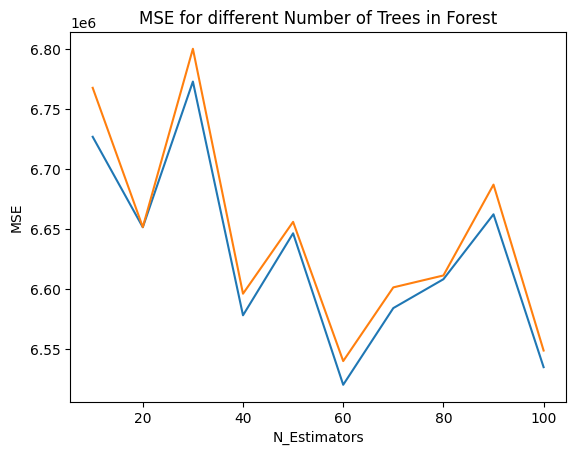

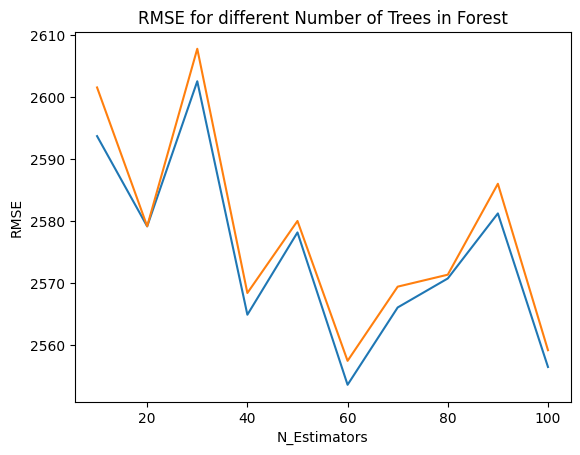

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

tree_count= np.arange(10,110,10)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for trees in tree_count:
    RF_regObj = RandomForestRegressor(n_estimators=trees)
    RF_regObj.fit(X_train_sig,y_train.ravel())

    #prediciton on Val set
    y_val_pred = RF_regObj.predict(X_val_sig)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #Prediction on Test Set
    y_test_pred = RF_regObj.predict(X_test_sig)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(tree_count, mse_val_list)
plt.plot(tree_count, mse_test_list)
plt.title('MSE for different Number of Trees in Forest')
plt.xlabel('N_Estimators')
plt.ylabel('MSE')
plt.show()

plt.plot(tree_count, rmse_val_list)
plt.plot(tree_count, rmse_test_list)
plt.title('RMSE for different Number of Trees in Forest')
plt.xlabel('N_Estimators')
plt.ylabel('RMSE')
plt.show()

### Optimal - Random Forest significant features -  60 Estimators

In [ ]:
RF_regObj = RandomForestRegressor(n_estimators=60)
RF_regObj.fit(X_train_sig,y_train.ravel())

#prediciton on Val set
y_val_pred = RF_regObj.predict(X_val_sig)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = RF_regObj.predict(X_test_sig)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  6665030.022927001
MSE on Test Set:  6678012.060271333
RMSE on Val Set:  2581.671943320259
RMSE on Test Set:  2584.184989560796


### Run AdaBoost on significant features

In [ ]:
#AdaBoost
from sklearn.ensemble import AdaBoostRegressor
AB_regObj = AdaBoostRegressor()
AB_regObj.fit(X_train_sig,y_train.ravel())

#prediciton on Val set
y_val_pred = AB_regObj.predict(X_val_sig)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = AB_regObj.predict(X_test_sig)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  6514304.838314138
MSE on Test Set:  6540228.051535064
RMSE on Val Set:  2552.3136245990886
RMSE on Test Set:  2557.3869577236574


### Run Gradient Boost on significant features

In [ ]:
#GradientBoost
from sklearn.ensemble import GradientBoostingRegressor
GB_regObj = GradientBoostingRegressor()
GB_regObj.fit(X_train_sig,y_train.ravel())

#prediciton on Val set
y_val_pred = GB_regObj.predict(X_val_sig)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = GB_regObj.predict(X_test_sig)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  7536005.00611193
MSE on Test Set:  7484743.874394521
RMSE on Val Set:  2745.178501684714
RMSE on Test Set:  2735.8259949043763


### Run XGBoost on significant features

In [ ]:
#XGBoost
from xgboost import XGBRegressor
XGB_regObj = XGBRegressor()
XGB_regObj.fit(X_train_sig,y_train)

#prediciton on Val set
y_val_pred = XGB_regObj.predict(X_val_sig)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = XGB_regObj.predict(X_test_sig)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  8386163.600135349
MSE on Test Set:  8305796.135875048
RMSE on Val Set:  2895.887359711242
RMSE on Test Set:  2881.9778166868405


### PCA Linear Regression on all features

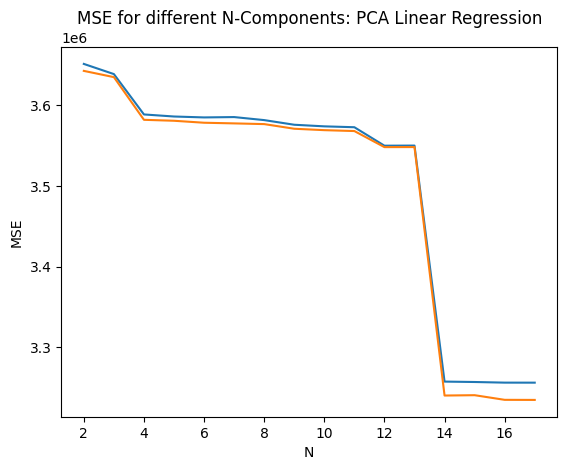

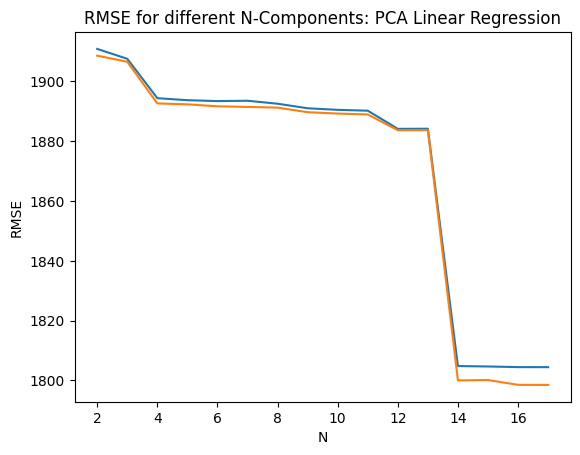

In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

x_axis_n = np.arange(2,18)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    pcaObj = PCA(n_components=i)

    X_train_pca = pcaObj.fit_transform(X_train)
    X_val_pca = pcaObj.transform(X_val)
    X_test_pca = pcaObj.transform(X_test)

    LinReg = LinearRegression()
    LinReg.fit(X_train_pca,y_train)
    y_val_pred2 = LinReg.predict(X_val_pca)
    y_test_pred2 = LinReg.predict(X_test_pca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: PCA Linear Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: PCA Linear Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - PCA Linear regression on all features - components = 14.


In [ ]:
pcaObj = PCA(n_components=14)

X_train_pca = pcaObj.fit_transform(X_train)
X_val_pca = pcaObj.transform(X_val)
X_test_pca = pcaObj.transform(X_test)

LinReg = LinearRegression()
LinReg.fit(X_train_pca,y_train)
y_val_pred2 = LinReg.predict(X_val_pca)
y_test_pred2 = LinReg.predict(X_test_pca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)
rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  3257260.0672636013
MSE on Test Set:  3239961.437895072
RMSE on Val Set:  1804.7880948365105
RMSE on Test Set:  1799.989288272314


### PCA Decision Tree on all features

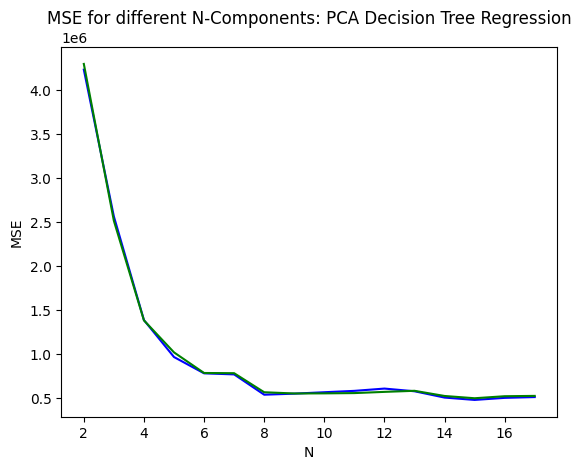

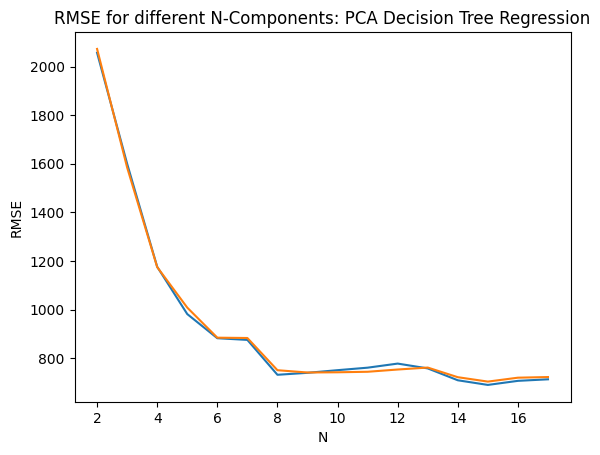

In [ ]:
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeRegressor

x_axis_n = np.arange(2,18)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    pcaObj = PCA(n_components=i)

    X_train_pca = pcaObj.fit_transform(X_train)
    X_val_pca = pcaObj.transform(X_val)
    X_test_pca = pcaObj.transform(X_test)

    DTReg = DecisionTreeRegressor()
    DTReg.fit(X_train_pca,y_train)
    y_val_pred2 = DTReg.predict(X_val_pca)
    y_test_pred2 = DTReg.predict(X_test_pca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list,color='blue', label='Validation MSE')
plt.plot(x_axis_n, mse_test_list,color='green', label='Test MSE')
plt.title('MSE for different N-Components: PCA Decision Tree Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: PCA Decision Tree Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - PCA Decision tree on all features - components = 5

In [ ]:
pcaObj = PCA(n_components=5)

X_train_pca = pcaObj.fit_transform(X_train)
X_val_pca = pcaObj.transform(X_val)
X_test_pca = pcaObj.transform(X_test)

DTReg = DecisionTreeRegressor()
DTReg.fit(X_train_pca,y_train)
y_val_pred2 = DTReg.predict(X_val_pca)
y_test_pred2 = DTReg.predict(X_test_pca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)
rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  736255.3620831793
MSE on Test Set:  755417.1934854522
RMSE on Val Set:  858.0532396554303
RMSE on Test Set:  869.1473945686383


### PCA Polynomial Regression on all features

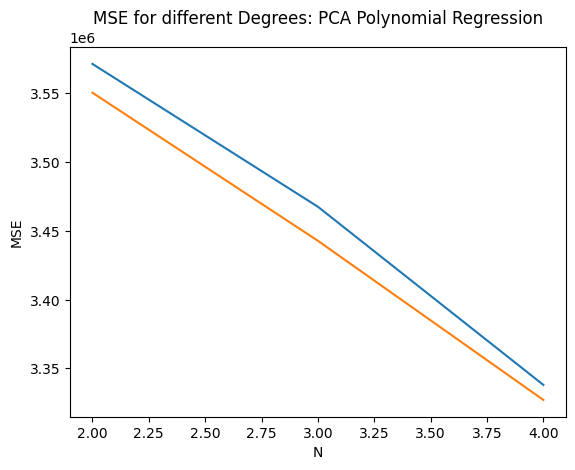

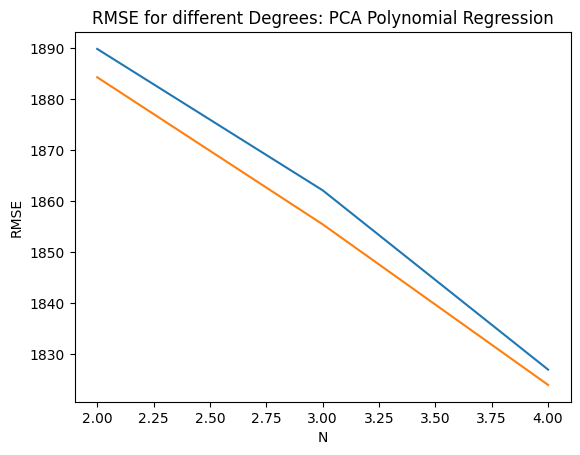

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []
pcaObj = PCA(n_components=3)

X_train_pca = pcaObj.fit_transform(X_train)
X_val_pca = pcaObj.transform(X_val)
X_test_pca = pcaObj.transform(X_test)

degrees = np.arange(2,5)
for d in degrees:
  polyFeatureObj = PolynomialFeatures(degree=d)
  X_poly = polyFeatureObj.fit_transform(X_train_pca)
  X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
  prObj = LinearRegression()
  prObj.fit(X_poly, y_train)

  #prediction on Val set
  v = polyFeatureObj.fit_transform(X_val_pca)
  v = v[:,1:]
  y_val_pred=prObj.predict(v)
  mse_val = mean_squared_error(y_val, y_val_pred)
  rmse_val = sqrt(mse_val)

  #prediction on Test set
  v= polyFeatureObj.fit_transform(X_test_pca)
  v = v[:,1:]
  y_test_pred=prObj.predict(v)
  mse_test = mean_squared_error(y_test, y_test_pred)
  rmse_test = sqrt(mse_test)

  #Appending Lists
  mse_val_list.append(mse_val)
  mse_test_list.append(mse_test)
  rmse_val_list.append(rmse_val)
  rmse_test_list.append(rmse_test)

plt.plot(degrees, mse_val_list)
plt.plot(degrees, mse_test_list)
plt.title('MSE for different Degrees: PCA Polynomial Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(degrees, rmse_val_list)
plt.plot(degrees, rmse_test_list)
plt.title('RMSE for different Degrees: PCA Polynomial Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - PCA Polynomial Regression on all features - 3 Components - 3 degrees

In [ ]:
pcaObj = PCA(n_components=3)

X_train_pca = pcaObj.fit_transform(X_train)
X_val_pca = pcaObj.transform(X_val)
X_test_pca = pcaObj.transform(X_test)

polyFeatureObj = PolynomialFeatures(degree=3)
X_poly = polyFeatureObj.fit_transform(X_train_pca)
X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
prObj = LinearRegression()
prObj.fit(X_poly, y_train)

#prediction on Val set
v= polyFeatureObj.fit_transform(X_val_pca)
v = v[:,1:]
y_val_pred=prObj.predict(v)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#prediction on Test set
v= polyFeatureObj.fit_transform(X_test_pca)
v = v[:,1:]
y_test_pred=prObj.predict(v)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  3396284.3693164564
MSE on Test Set:  3375769.5770472502
RMSE on Val Set:  1842.9010742078524
RMSE on Test Set:  1837.3267474913791


### PCA  Random Forest Regression on all features - 3 Components


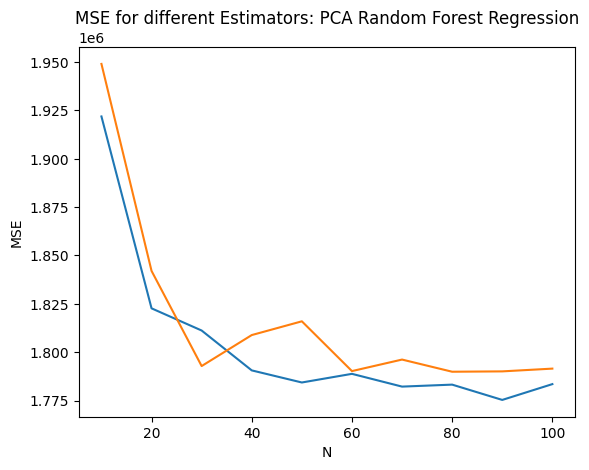

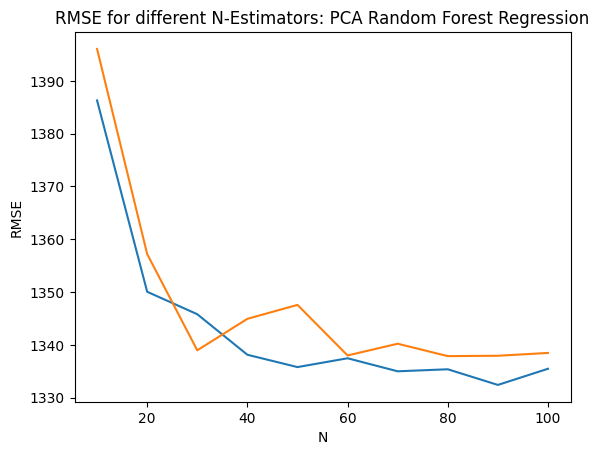

In [ ]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

pcaObj = PCA(n_components=3)

X_train_pca = pcaObj.fit_transform(X_train)
X_val_pca = pcaObj.transform(X_val)
X_test_pca = pcaObj.transform(X_test)

tree_count= np.arange(10,110,10)
for trees in tree_count:
    RF_regObj = RandomForestRegressor(n_estimators=trees)
    RF_regObj.fit(X_train_pca,y_train.ravel())

    #prediciton on Val set
    y_val_pred = RF_regObj.predict(X_val_pca)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #Prediction on Test Set
    y_test_pred = RF_regObj.predict(X_test_pca)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(tree_count, mse_val_list)
plt.plot(tree_count, mse_test_list)
plt.title('MSE for different Estimators: PCA Random Forest Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(tree_count, rmse_val_list)
plt.plot(tree_count, rmse_test_list)
plt.title('RMSE for different N-Estimators: PCA Random Forest Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - PCA  Random Forest Regression on all features - 3 Components and 10 Estimators

In [ ]:
from sklearn.decomposition import PCA

pcaObj = PCA(n_components=3)
X_train_pca = pcaObj.fit_transform(X_train)

X_train_pca = pcaObj.fit_transform(X_train)
X_val_pca = pcaObj.transform(X_val)
X_test_pca = pcaObj.transform(X_test)

RF_regObj = RandomForestRegressor(n_estimators=10)
RF_regObj.fit(X_train_pca,y_train.ravel())

#prediciton on Val set
y_val_pred = RF_regObj.predict(X_val_pca)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = RF_regObj.predict(X_test_pca)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

#Appending Lists
mse_val_list.append(mse_val)
mse_test_list.append(mse_test)
rmse_val_list.append(rmse_val)
rmse_test_list.append(rmse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  1322485.9793124932
MSE on Test Set:  1286318.4066217404
RMSE on Val Set:  1149.9939040327533
RMSE on Test Set:  1134.159780022965


### PCA AdaBoost on all features

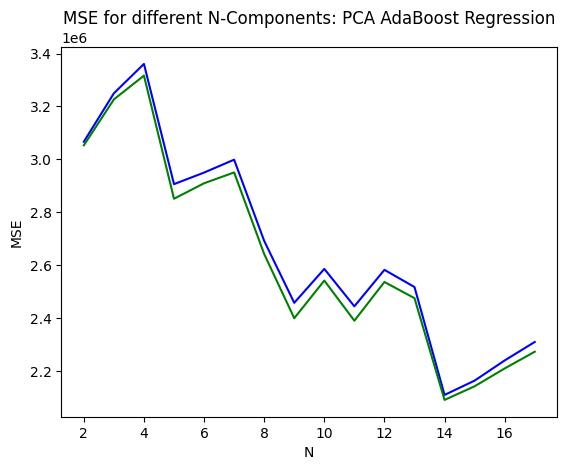

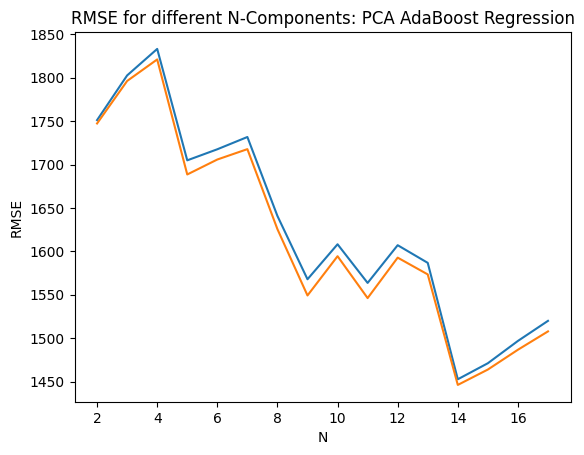

In [ ]:
from sklearn.decomposition import PCA
from sklearn.ensemble import AdaBoostRegressor

x_axis_n = np.arange(2,18)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    pcaObj = PCA(n_components=i)

    X_train_pca = pcaObj.fit_transform(X_train)
    X_val_pca = pcaObj.transform(X_val)
    X_test_pca = pcaObj.transform(X_test)

    ABReg = AdaBoostRegressor()
    ABReg.fit(X_train_pca,y_train.ravel())
    y_val_pred2 = ABReg.predict(X_val_pca)
    y_test_pred2 = ABReg.predict(X_test_pca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list,color='blue', label='Validation MSE')
plt.plot(x_axis_n, mse_test_list,color='green', label='Test MSE')
plt.title('MSE for different N-Components: PCA AdaBoost Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: PCA AdaBoost Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - PCA ADA boost on all features with Components = 14


In [ ]:
pcaObj = PCA(n_components=14)

X_train_pca = pcaObj.fit_transform(X_train)
X_val_pca = pcaObj.transform(X_val)
X_test_pca = pcaObj.transform(X_test)

ABReg = AdaBoostRegressor()
ABReg.fit(X_train_pca,y_train.ravel())
y_val_pred2 = ABReg.predict(X_val_pca)
y_test_pred2 = ABReg.predict(X_test_pca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)


MSE on Val Set:  2322777.209273778
MSE on Test Set:  2299214.8668158473
RMSE on Val Set:  1524.0660121116073
RMSE on Test Set:  1516.3162159707479


### PCA GradientBoost on all features

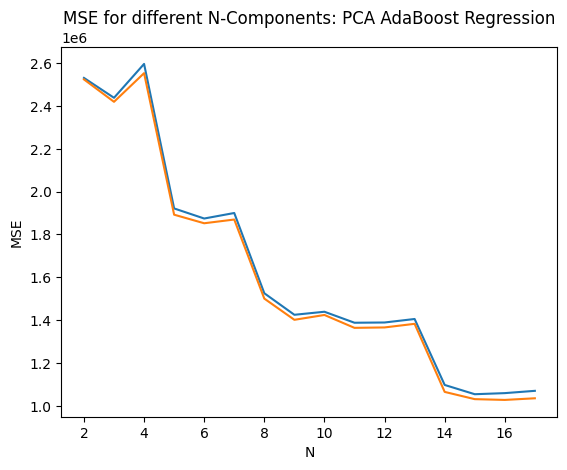

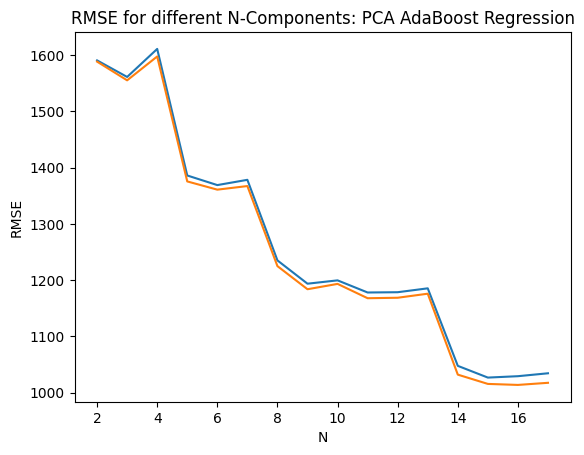

In [ ]:
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor

x_axis_n = np.arange(2,18)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    pcaObj = PCA(n_components=i)

    X_train_pca = pcaObj.fit_transform(X_train)
    X_val_pca = pcaObj.transform(X_val)
    X_test_pca = pcaObj.transform(X_test)

    GBReg = GradientBoostingRegressor()
    GBReg.fit(X_train_pca,y_train.ravel())
    y_val_pred2 = GBReg.predict(X_val_pca)
    y_test_pred2 = GBReg.predict(X_test_pca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: PCA AdaBoost Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: PCA AdaBoost Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - PCA Gradient boost on all features with Components = 9

In [ ]:
pcaObj = PCA(n_components=9)

X_train_pca = pcaObj.fit_transform(X_train)
X_val_pca = pcaObj.transform(X_val)
X_test_pca = pcaObj.transform(X_test)

GBReg = GradientBoostingRegressor()
GBReg.fit(X_train_pca,y_train.ravel())
y_val_pred2 = GBReg.predict(X_val_pca)
y_test_pred2 = GBReg.predict(X_test_pca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  1425008.5980404366
MSE on Test Set:  1402432.9041824008
RMSE on Val Set:  1193.7372399487404
RMSE on Test Set:  1184.2436000174966


### PCA XGBoost on all features

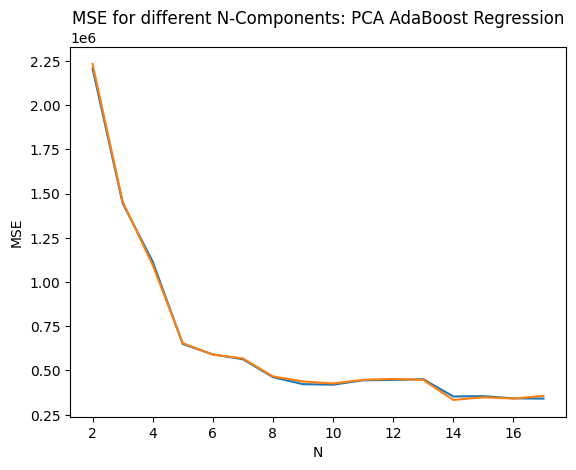

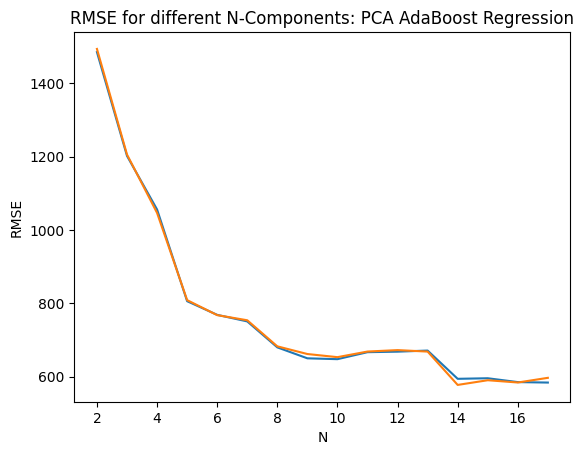

In [ ]:
from sklearn.decomposition import PCA
from xgboost import XGBRegressor

x_axis_n = np.arange(2,18)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    pcaObj = PCA(n_components=i)

    X_train_pca = pcaObj.fit_transform(X_train)
    X_val_pca = pcaObj.transform(X_val)
    X_test_pca = pcaObj.transform(X_test)

    XGBReg = XGBRegressor()
    XGBReg.fit(X_train_pca,y_train)
    y_val_pred2 = XGBReg.predict(X_val_pca)
    y_test_pred2 = XGBReg.predict(X_test_pca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: PCA AdaBoost Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: PCA AdaBoost Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - PCA XGBoost on all features with Components = 6

In [ ]:
pcaObj = PCA(n_components=6)

X_train_pca = pcaObj.fit_transform(X_train)
X_val_pca = pcaObj.transform(X_val)
X_test_pca = pcaObj.transform(X_test)

XGBReg = XGBRegressor()
XGBReg.fit(X_train_pca,y_train)
y_val_pred2 = XGBReg.predict(X_val_pca)
y_test_pred2 = XGBReg.predict(X_test_pca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  597231.5653060147
MSE on Test Set:  592041.87775614
RMSE on Val Set:  772.8075862114804
RMSE on Test Set:  769.4425759965067


### KPCA - linear Linear Regression on all features

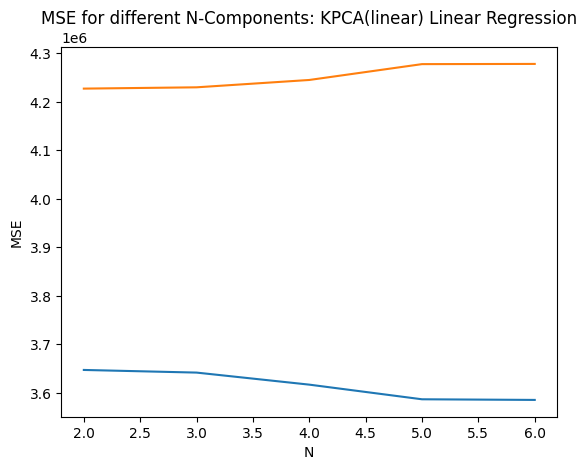

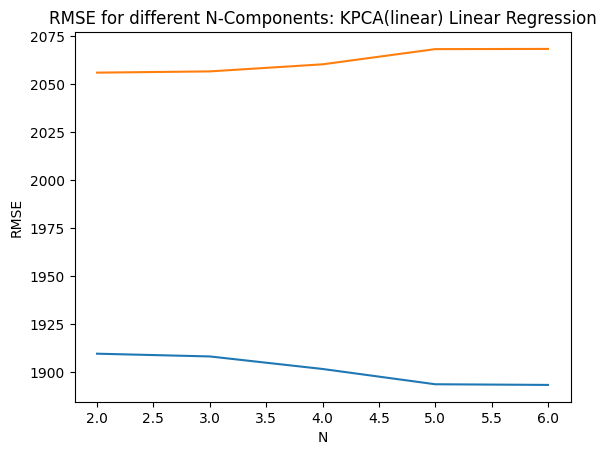

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LinearRegression

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='linear')

    X_train_kpca = kpcaObj.fit_transform(X_train)
    X_val_kpca = kpcaObj.transform(X_val)
    X_test_kpca = kpcaObj.transform(X_test)

    LinReg = LinearRegression()
    LinReg.fit(X_train_kpca,y_train)
    y_val_pred2 = LinReg.predict(X_val_kpca)
    y_test_pred2 = LinReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_val, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(linear) Linear Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(linear) Linear Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - linear Linear Regression on all features - Components = 3

In [ ]:
kpcaObj = KernelPCA(n_components=3, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

LinReg = LinearRegression()
LinReg.fit(X_train_kpca,y_train)
y_val_pred2 = LinReg.predict(X_val_kpca)
y_test_pred2 = LinReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_val, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  3641404.752831216
MSE on Test Set:  4229570.375061411
RMSE on Val Set:  1908.2465125950619
RMSE on Test Set:  2056.591932071458


### KPCA - linear Decision Tree on all features

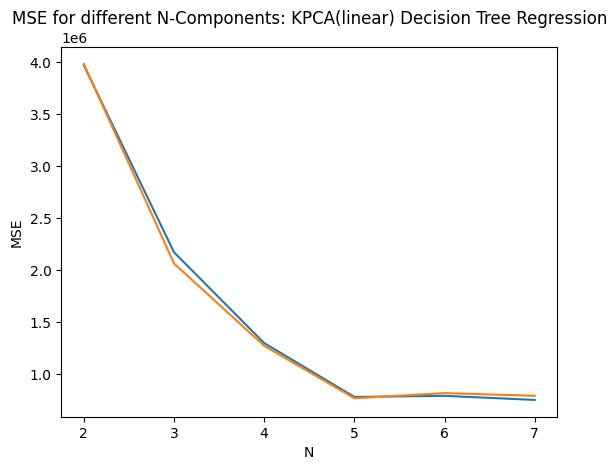

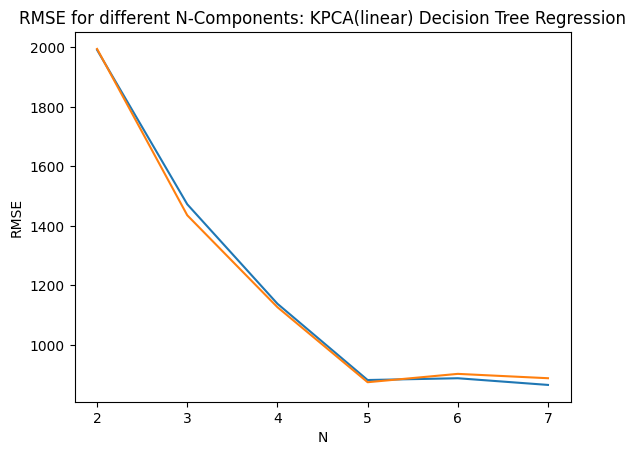

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.tree import DecisionTreeRegressor

x_axis_n = np.arange(2,8)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='linear')

    X_train_kpca = kpcaObj.fit_transform(X_train)
    X_val_kpca = kpcaObj.transform(X_val)
    X_test_kpca = kpcaObj.transform(X_test)

    DTReg = DecisionTreeRegressor()
    DTReg.fit(X_train_kpca,y_train)
    y_val_pred2 = DTReg.predict(X_val_kpca)
    y_test_pred2 = DTReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(linear) Decision Tree Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(linear) Decision Tree Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - linear Decision Tree on all features - 4 Components


In [ ]:
kpcaObj = KernelPCA(n_components=4, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

DTReg = DecisionTreeRegressor()
DTReg.fit(X_train_kpca,y_train)
y_val_pred2 = DTReg.predict(X_val_kpca)
y_test_pred2 = DTReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_val, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  1281986.0956986716
MSE on Test Set:  7926723.467042582
RMSE on Val Set:  1132.2482482647838
RMSE on Test Set:  2815.443742475168


### KPCA - linear Polynomial Regression on all features

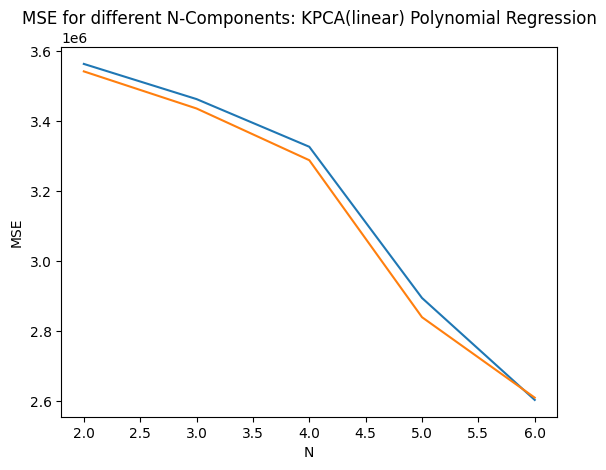

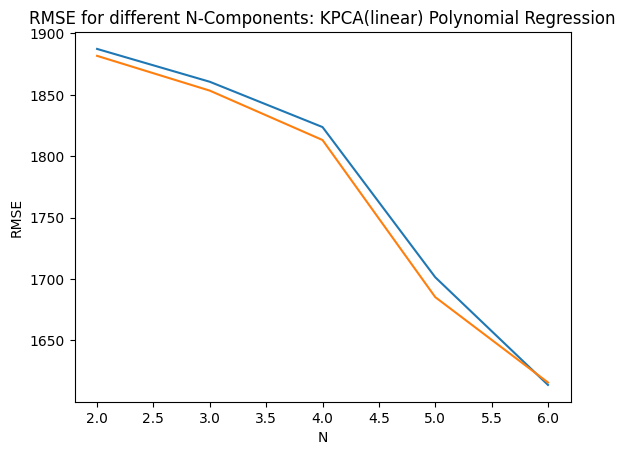

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []
degrees = np.arange(2,7)

kpcaObj = KernelPCA(n_components=3, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

for d in degrees:
    polyFeatureObj = PolynomialFeatures(degree=d)
    X_poly = polyFeatureObj.fit_transform(X_train_kpca)
    X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
    prObj = LinearRegression()
    prObj.fit(X_poly, y_train)

    #prediction on Val set
    v= polyFeatureObj.fit_transform(X_val_kpca)
    v = v[:,1:]
    y_val_pred=prObj.predict(v)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #prediction on Test set
    v= polyFeatureObj.fit_transform(X_test_kpca)
    v = v[:,1:]
    y_test_pred=prObj.predict(v)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(degrees, mse_val_list)
plt.plot(degrees, mse_test_list)
plt.title('MSE for different N-Components: KPCA(linear) Polynomial Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(degrees, rmse_val_list)
plt.plot(degrees, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(linear) Polynomial Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - linear Polynomial Regression on all features - 3 Components - 5 Degrees

In [ ]:
kpcaObj = KernelPCA(n_components=3, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

polyFeatureObj = PolynomialFeatures(degree=5)
X_poly = polyFeatureObj.fit_transform(X_train_kpca)
X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
prObj = LinearRegression()
prObj.fit(X_poly, y_train)

#prediction on Val set
v= polyFeatureObj.fit_transform(X_val_kpca)
v = v[:,1:]
y_val_pred=prObj.predict(v)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#prediction on Test set
v= polyFeatureObj.fit_transform(X_test_kpca)
v = v[:,1:]
y_test_pred=prObj.predict(v)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  2894914.9592574267
MSE on Test Set:  2840079.897701801
RMSE on Val Set:  1701.4449621593485
RMSE on Test Set:  1685.2536597503063


### KPCA - linear Random Forest Regression on all features

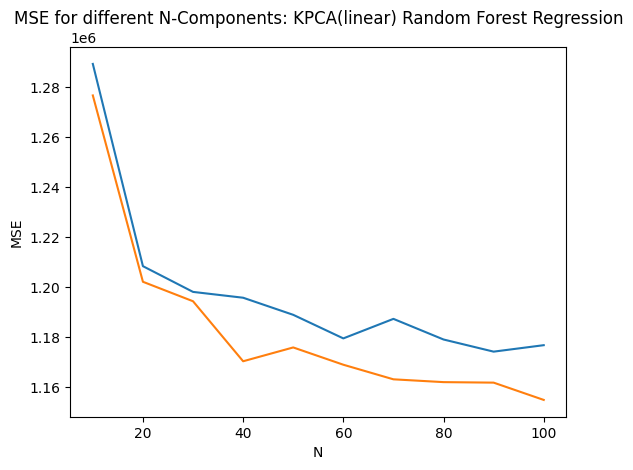

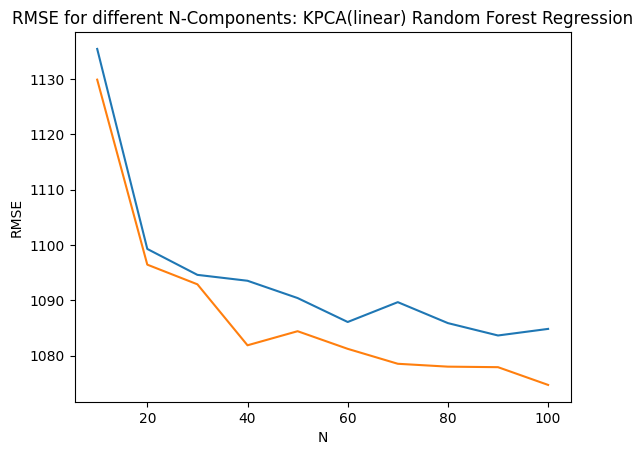

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import RandomForestRegressor

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

tree_count= np.arange(10,110,10)

kpcaObj = KernelPCA(n_components=3, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

for trees in tree_count:
    RF_regObj = RandomForestRegressor(n_estimators=trees)
    RF_regObj.fit(X_train_kpca,y_train.ravel())

    #prediciton on Val set
    y_val_pred = RF_regObj.predict(X_val_kpca)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #Prediction on Test Set
    y_test_pred = RF_regObj.predict(X_test_kpca)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(tree_count, mse_val_list)
plt.plot(tree_count, mse_test_list)
plt.title('MSE for different N-Components: KPCA(linear) Random Forest Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(tree_count, rmse_val_list)
plt.plot(tree_count, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(linear) Random Forest Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - linear Random Forest Regression on all features - Components = 3, Degrees = 30

In [ ]:
kpcaObj = KernelPCA(n_components=3, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

RF_regObj = RandomForestRegressor(n_estimators=30)
RF_regObj.fit(X_train_kpca,y_train.ravel())

#prediciton on Val set
y_val_pred = RF_regObj.predict(X_val_kpca)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = RF_regObj.predict(X_test_kpca)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  1203303.1394976352
MSE on Test Set:  1200977.5168966625
RMSE on Val Set:  1096.9517489377713
RMSE on Test Set:  1095.891197563272


### KPCA - linear AdaBoost on all features

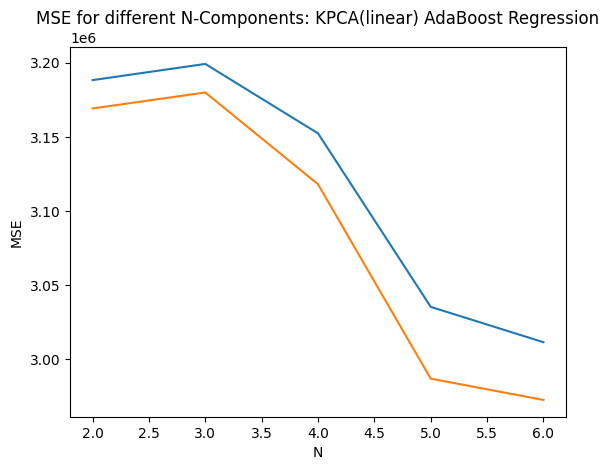

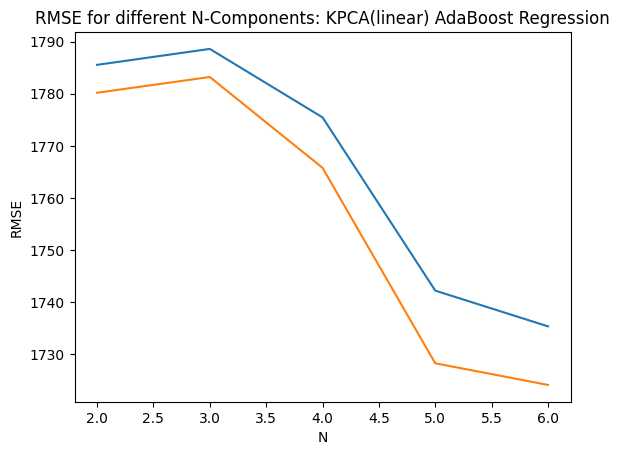

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import AdaBoostRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='linear')

    X_train_kpca = kpcaObj.fit_transform(X_train)
    X_val_kpca = kpcaObj.transform(X_val)
    X_test_kpca = kpcaObj.transform(X_test)

    ABReg = AdaBoostRegressor()
    ABReg.fit(X_train_kpca,y_train.ravel())
    y_val_pred2 = ABReg.predict(X_val_kpca)
    y_test_pred2 = ABReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(linear) AdaBoost Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(linear) AdaBoost Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - linear AdaBoost on all features - Components = 5

In [ ]:
kpcaObj = KernelPCA(n_components=5, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

ABReg = AdaBoostRegressor()
ABReg.fit(X_train_kpca,y_train.ravel())
y_val_pred2 = ABReg.predict(X_val_kpca)
y_test_pred2 = ABReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  3001896.2469011936
MSE on Test Set:  2963222.0543596703
RMSE on Val Set:  1732.5981204252744
RMSE on Test Set:  1721.401189252427


### KPCA - linear GradientBoost on all features

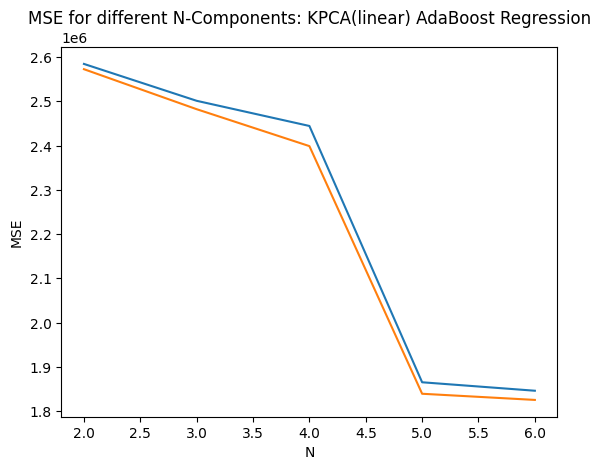

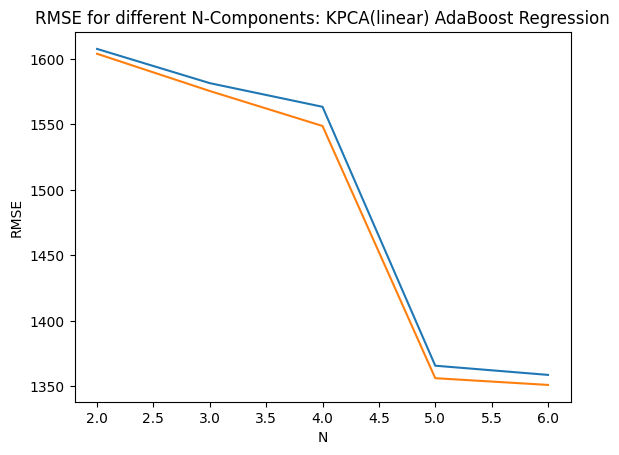

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import GradientBoostingRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='linear')

    X_train_kpca = kpcaObj.fit_transform(X_train)
    X_val_kpca = kpcaObj.transform(X_val)
    X_test_kpca = kpcaObj.transform(X_test)

    GBReg = GradientBoostingRegressor()
    GBReg.fit(X_train_kpca,y_train.ravel())
    y_val_pred2 = GBReg.predict(X_val_kpca)
    y_test_pred2 = GBReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(linear) AdaBoost Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(linear) AdaBoost Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - linear GradientBoost on all features - Components = 5

In [ ]:
kpcaObj = KernelPCA(n_components=5, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

GBReg = GradientBoostingRegressor()
GBReg.fit(X_train_kpca,y_train.ravel())
y_val_pred2 = GBReg.predict(X_val_kpca)
y_test_pred2 = GBReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  1865396.4171230402
MSE on Test Set:  1839406.2294709422
RMSE on Val Set:  1365.7951592837926
RMSE on Test Set:  1356.2471122442776


### KPCA - linear XGBoost on all features


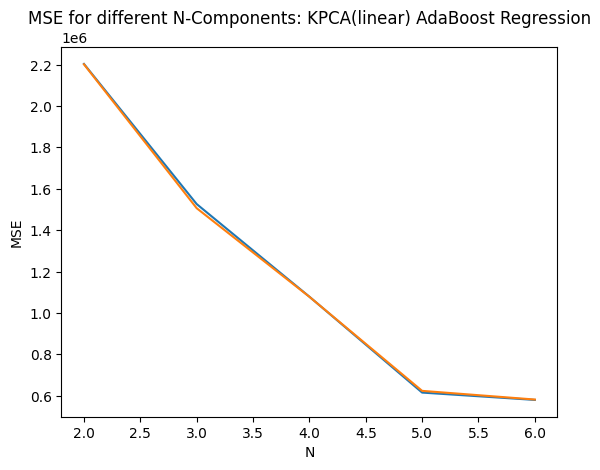

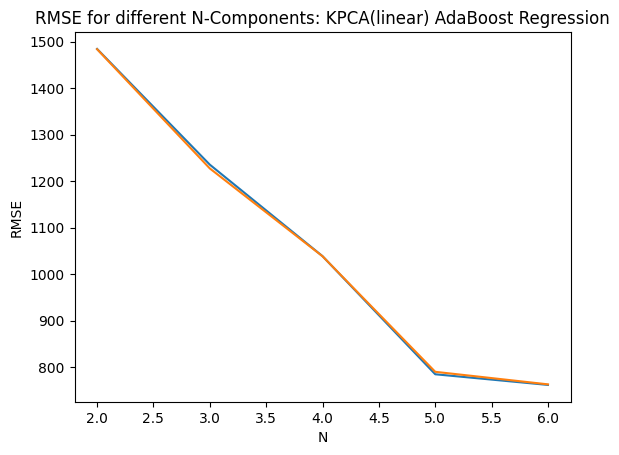

In [ ]:
from sklearn.decomposition import KernelPCA
from xgboost import XGBRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='linear')

    X_train_kpca = kpcaObj.fit_transform(X_train)
    X_val_kpca = kpcaObj.transform(X_val)
    X_test_kpca = kpcaObj.transform(X_test)

    XGBReg = XGBRegressor()
    XGBReg.fit(X_train_kpca,y_train)
    y_val_pred2 = XGBReg.predict(X_val_kpca)
    y_test_pred2 = XGBReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(linear) AdaBoost Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(linear) AdaBoost Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - linear XGBoost on all features - Components = 5


In [ ]:
kpcaObj = KernelPCA(n_components=5, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

XGBReg = XGBRegressor()
XGBReg.fit(X_train_kpca,y_train)
y_val_pred2 = XGBReg.predict(X_val_kpca)
y_test_pred2 = XGBReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  615969.0442632096
MSE on Test Set:  624307.7317248335
RMSE on Val Set:  784.8369539357901
RMSE on Test Set:  790.1314648366014


### KPCA - poly Linear Regression on all features

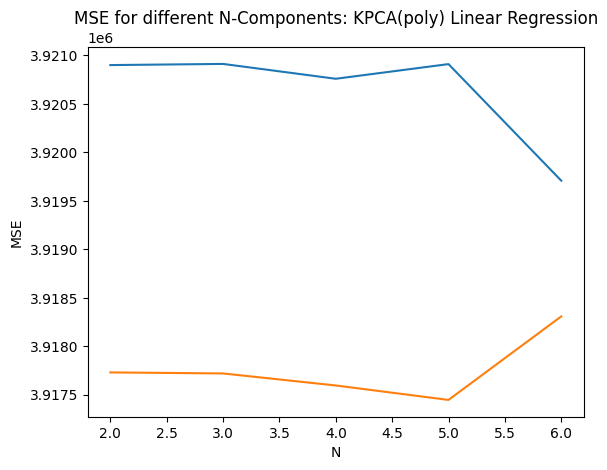

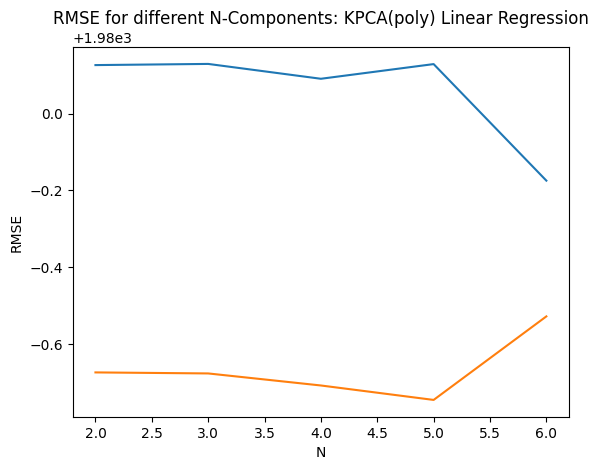

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LinearRegression

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='poly')

    X_train_kpca = kpcaObj.fit_transform(X_train)
    X_val_kpca = kpcaObj.transform(X_val)
    X_test_kpca = kpcaObj.transform(X_test)

    LinReg = LinearRegression()
    LinReg.fit(X_train_kpca,y_train)
    y_val_pred2 = LinReg.predict(X_val_kpca)
    y_test_pred2 = LinReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(poly) Linear Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(poly) Linear Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal KPCA - poly Linear Regression on all features. Component = 4

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LinearRegression

kpcaObj = KernelPCA(n_components=4, kernel='poly')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

LinReg = LinearRegression()
LinReg.fit(X_train_kpca,y_train)
y_val_pred2 = LinReg.predict(X_val_kpca)
y_test_pred2 = LinReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  3920759.1360583236
MSE on Test Set:  3917594.176526121
RMSE on Val Set:  1980.0906888469335
RMSE on Test Set:  1979.2913318978894


### KPCA - poly Decision Tree on all features

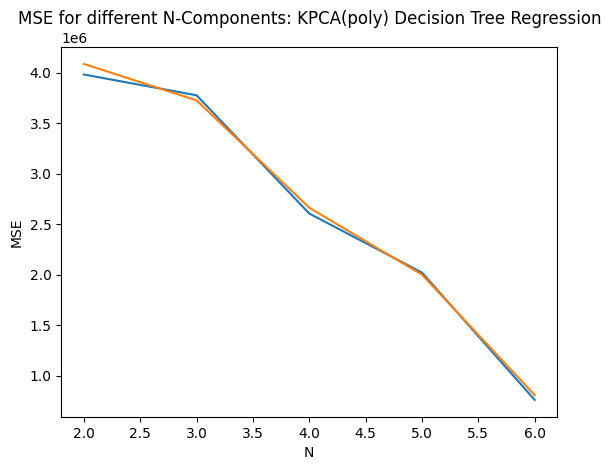

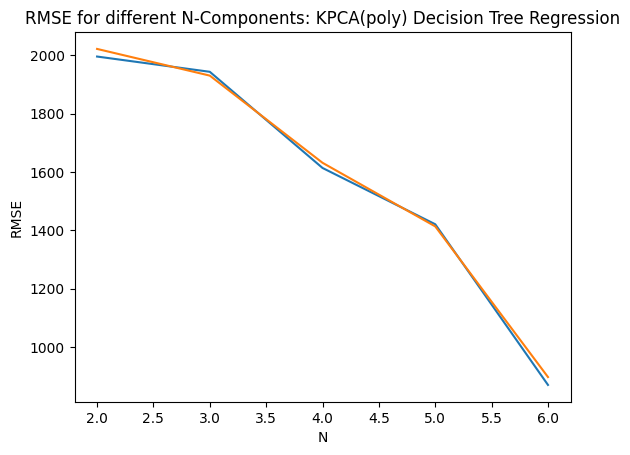

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.tree import DecisionTreeRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='poly')

    X_train_kpca = kpcaObj.fit_transform(X_train)
    X_val_kpca = kpcaObj.transform(X_val)
    X_test_kpca = kpcaObj.transform(X_test)

    DTReg = DecisionTreeRegressor()
    DTReg.fit(X_train_kpca,y_train)
    y_val_pred2 = DTReg.predict(X_val_kpca)
    y_test_pred2 = DTReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(poly) Decision Tree Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(poly) Decision Tree Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal KPCA - poly Decision Tree on all features components = 6

In [ ]:
kpcaObj = KernelPCA(n_components=6, kernel='poly')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

DTReg = DecisionTreeRegressor()
DTReg.fit(X_train_kpca,y_train)
y_val_pred2 = DTReg.predict(X_val_kpca)
y_test_pred2 = DTReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  734572.9978722531
MSE on Test Set:  790162.8750320736
RMSE on Val Set:  857.072341096277
RMSE on Test Set:  888.9110613734501


### KPCA - poly Polynomial Regression on all features

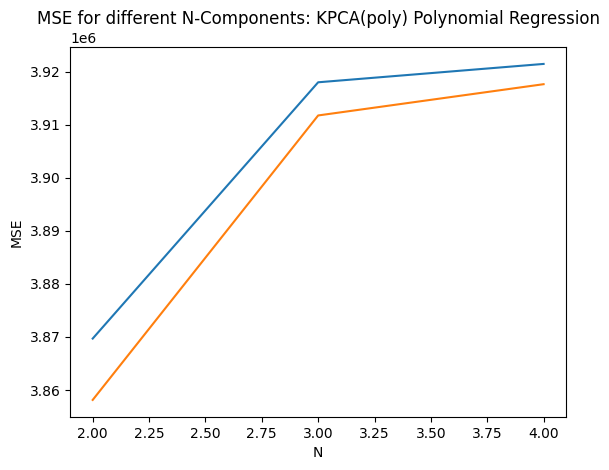

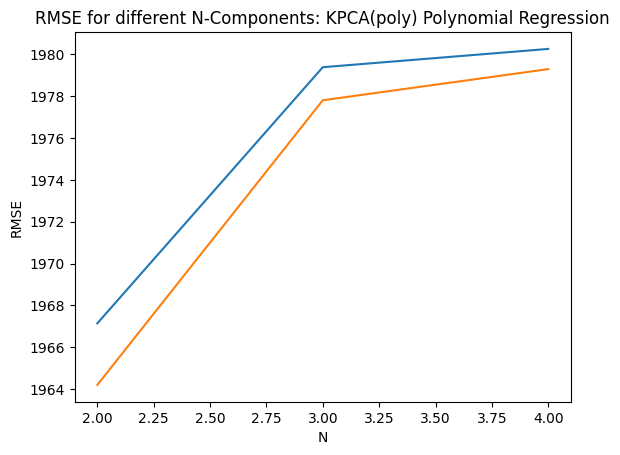

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []
degrees = np.arange(2,5)

kpcaObj = KernelPCA(n_components=3, kernel='poly')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)


for d in degrees:
    polyFeatureObj = PolynomialFeatures(degree=d)
    X_poly = polyFeatureObj.fit_transform(X_train_kpca)
    X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
    prObj = LinearRegression()
    prObj.fit(X_poly, y_train)

    #prediction on Val set
    v= polyFeatureObj.fit_transform(X_val_kpca)
    v = v[:,1:]
    y_val_pred=prObj.predict(v)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #prediction on Test set
    v= polyFeatureObj.fit_transform(X_test_kpca)
    v = v[:,1:]
    y_test_pred=prObj.predict(v)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(degrees, mse_val_list)
plt.plot(degrees, mse_test_list)
plt.title('MSE for different N-Components: KPCA(poly) Polynomial Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(degrees, rmse_val_list)
plt.plot(degrees, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(poly) Polynomial Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal KPCA - poly Polynomial Regression on all features Degree = 2

In [ ]:
polyFeatureObj = PolynomialFeatures(degree=2)
X_poly = polyFeatureObj.fit_transform(X_train_kpca)
X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
prObj = LinearRegression()
prObj.fit(X_poly, y_train)

#prediction on Val set
v= polyFeatureObj.fit_transform(X_val_kpca)
v = v[:,1:]
y_val_pred=prObj.predict(v)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#prediction on Test set
v= polyFeatureObj.fit_transform(X_test_kpca)
v = v[:,1:]
y_test_pred=prObj.predict(v)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  3869633.2982861293
MSE on Test Set:  3858057.165371314
RMSE on Val Set:  1967.1383526041398
RMSE on Test Set:  1964.1937698127733


### KPCA - poly Random Forest Regression on all features

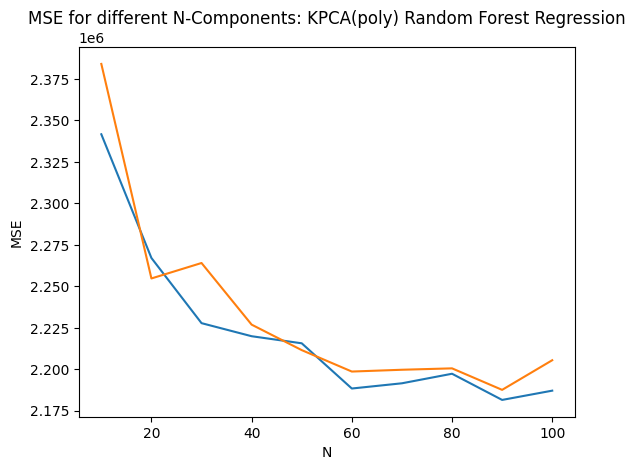

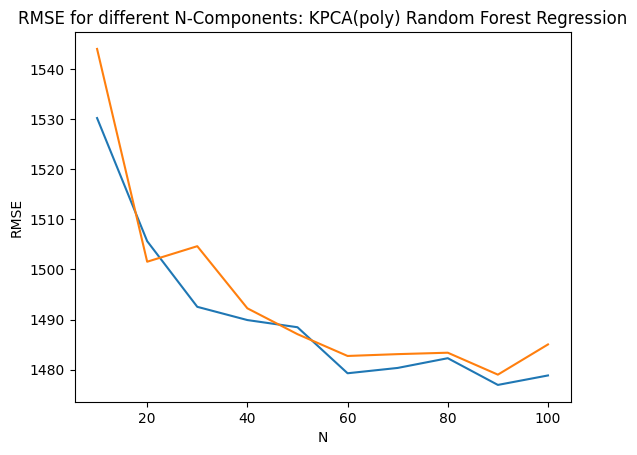

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import RandomForestRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []
tree_count= np.arange(10,110,10)

kpcaObj = KernelPCA(n_components=3, kernel='poly')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

for trees in tree_count:
    RF_regObj = RandomForestRegressor(n_estimators=trees)
    RF_regObj.fit(X_train_kpca,y_train.ravel())

    #prediciton on Val set
    y_val_pred = RF_regObj.predict(X_val_kpca)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #Prediction on Test Set
    y_test_pred = RF_regObj.predict(X_test_kpca)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(tree_count, mse_val_list)
plt.plot(tree_count, mse_test_list)
plt.title('MSE for different N-Components: KPCA(poly) Random Forest Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(tree_count, rmse_val_list)
plt.plot(tree_count, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(poly) Random Forest Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal KPCA - poly Random Forest Regression on all features, estimator = 50

In [ ]:
RF_regObj = RandomForestRegressor(n_estimators=50)
RF_regObj.fit(X_train_kpca,y_train.ravel())

#prediciton on Val set
y_val_pred = RF_regObj.predict(X_val_kpca)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = RF_regObj.predict(X_test_kpca)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  1373602.5441572235
MSE on Test Set:  1346287.2022444017
RMSE on Val Set:  1172.0079113031718
RMSE on Test Set:  1160.2961700550431


### KPCA - poly AdaBoost on all features

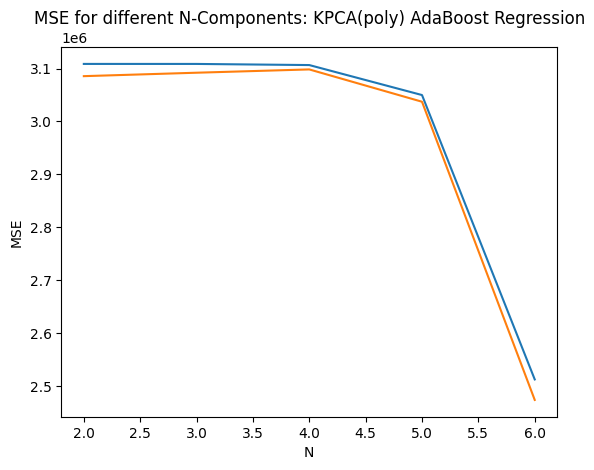

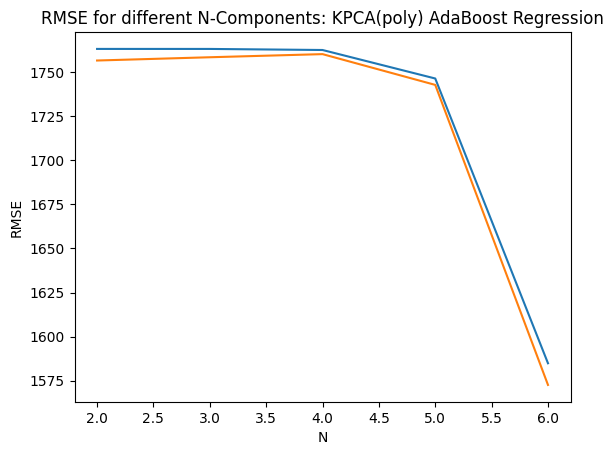

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import AdaBoostRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='poly')

    X_train_kpca = kpcaObj.fit_transform(X_train)
    X_val_kpca = kpcaObj.transform(X_val)
    X_test_kpca = kpcaObj.transform(X_test)

    ABReg = AdaBoostRegressor()
    ABReg.fit(X_train_kpca,y_train.ravel())
    y_val_pred2 = ABReg.predict(X_val_kpca)
    y_test_pred2 = ABReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(poly) AdaBoost Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(poly) AdaBoost Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal KPCA - poly AdaBoost on all features Component = 5

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import AdaBoostRegressor

kpcaObj = KernelPCA(n_components=5, kernel='poly')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

ABReg = AdaBoostRegressor()
ABReg.fit(X_train_kpca,y_train.ravel())
y_val_pred2 = ABReg.predict(X_val_kpca)
y_test_pred2 = ABReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)
print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  3077126.8820930524
MSE on Test Set:  3054531.732518701
RMSE on Val Set:  1754.17413106369
RMSE on Test Set:  1747.7218693255231


### KPCA - poly GradientBoost on all features

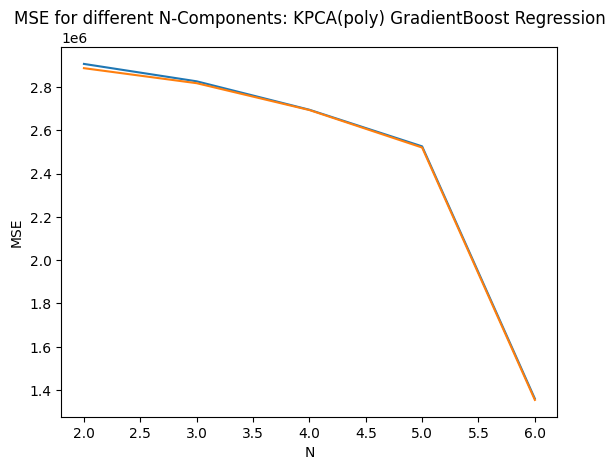

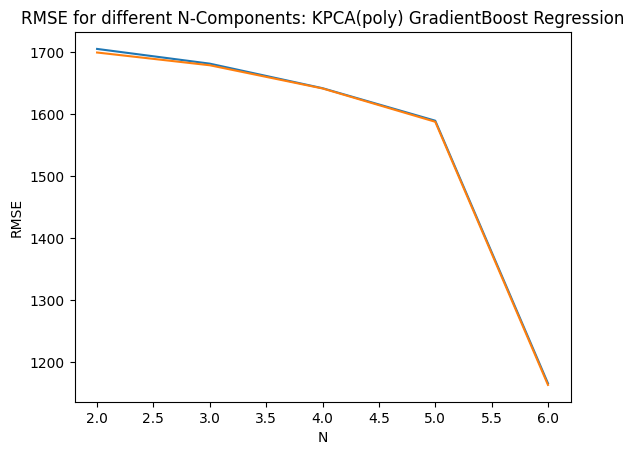

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import GradientBoostingRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='poly')

    X_train_kpca = kpcaObj.fit_transform(X_train)
    X_val_kpca = kpcaObj.transform(X_val)
    X_test_kpca = kpcaObj.transform(X_test)

    GBReg = GradientBoostingRegressor()
    GBReg.fit(X_train_kpca,y_train.ravel())
    y_val_pred2 = GBReg.predict(X_val_kpca)
    y_test_pred2 = GBReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(poly) GradientBoost Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(poly) GradientBoost Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal KPCA - poly GradientBoost on all features Component = 6

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import GradientBoostingRegressor

kpcaObj = KernelPCA(n_components=6, kernel='poly')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

GBReg = GradientBoostingRegressor()
GBReg.fit(X_train_kpca,y_train.ravel())
y_val_pred2 = GBReg.predict(X_val_kpca)
y_test_pred2 = GBReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  1359527.7604091237
MSE on Test Set:  1353722.9668778302
RMSE on Val Set:  1165.9878903355402
RMSE on Test Set:  1163.4960106841063


### KPCA - poly XGBoost on all features

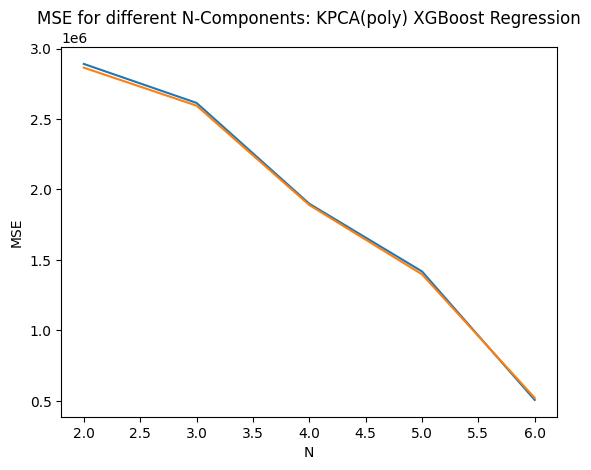

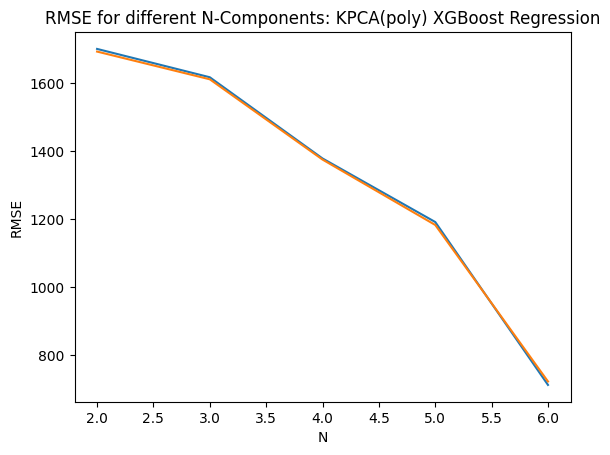

In [ ]:
from sklearn.decomposition import KernelPCA
from xgboost import XGBRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='poly')

    X_train_kpca = kpcaObj.fit_transform(X_train)
    X_val_kpca = kpcaObj.transform(X_val)
    X_test_kpca = kpcaObj.transform(X_test)

    XGBReg = XGBRegressor()
    XGBReg.fit(X_train_kpca,y_train)
    y_val_pred2 = XGBReg.predict(X_val_kpca)
    y_test_pred2 = XGBReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(poly) XGBoost Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(poly) XGBoost Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal KPCA - poly XGBoost on all features components = 6

In [ ]:
kpcaObj = KernelPCA(n_components=6, kernel='poly')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

XGBReg = XGBRegressor()
XGBReg.fit(X_train_kpca,y_train)
y_val_pred2 = XGBReg.predict(X_val_kpca)
y_test_pred2 = XGBReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  506189.6642527582
MSE on Test Set:  520627.77428588
RMSE on Val Set:  711.4700726332474
RMSE on Test Set:  721.5454069467007


### KPCA - rbf Linear Regression on all features

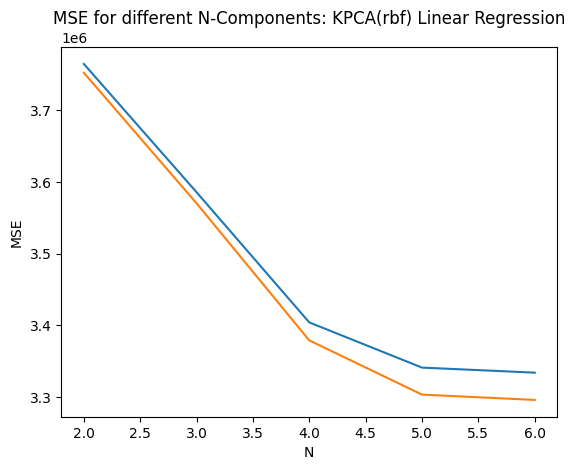

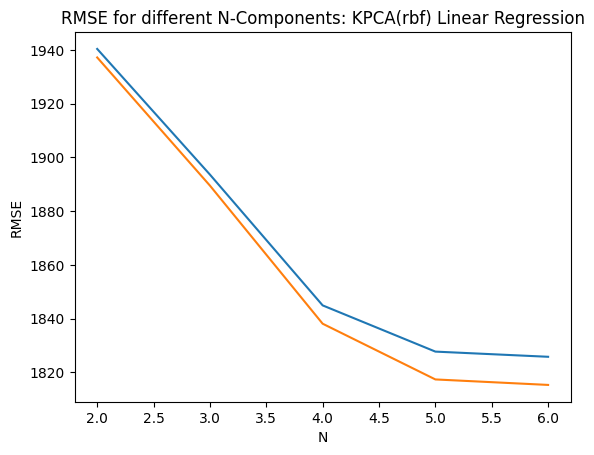

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LinearRegression

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='rbf')

    X_train_kpca = kpcaObj.fit_transform(X_train)
    X_val_kpca = kpcaObj.transform(X_val)
    X_test_kpca = kpcaObj.transform(X_test)

    LinReg = LinearRegression()
    LinReg.fit(X_train_kpca,y_train)
    y_val_pred2 = LinReg.predict(X_val_kpca)
    y_test_pred2 = LinReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(rbf) Linear Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(rbf) Linear Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal KPCA - rbf Linear Regression on all features component = 5

In [ ]:
kpcaObj = KernelPCA(n_components=5, kernel='rbf')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

LinReg = LinearRegression()
LinReg.fit(X_train_kpca,y_train)
y_val_pred2 = LinReg.predict(X_val_kpca)
y_test_pred2 = LinReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  3340726.3377503706
MSE on Test Set:  3302998.3607609016
RMSE on Val Set:  1827.7653946145197
RMSE on Test Set:  1817.4152967224913


### KPCA - rbf Decision Tree on all features

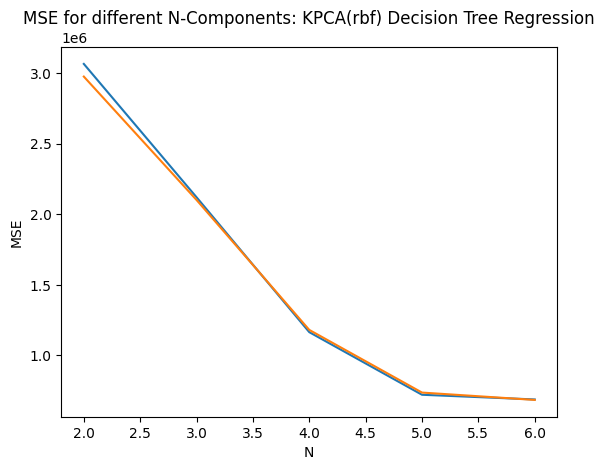

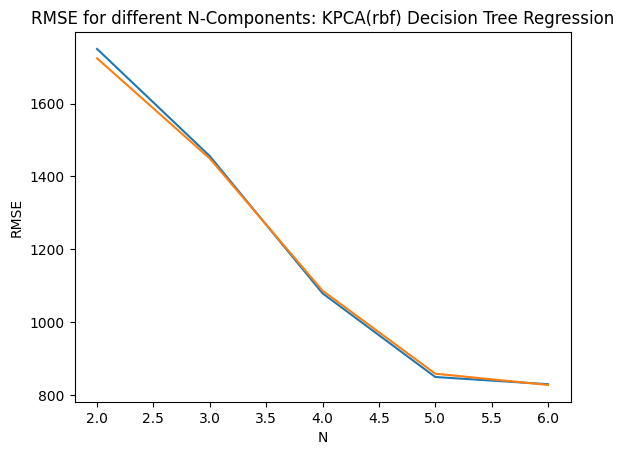

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.tree import DecisionTreeRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='rbf')

    X_train_kpca = kpcaObj.fit_transform(X_train)
    X_val_kpca = kpcaObj.transform(X_val)
    X_test_kpca = kpcaObj.transform(X_test)

    DTReg = DecisionTreeRegressor()
    DTReg.fit(X_train_kpca,y_train)
    y_val_pred2 = DTReg.predict(X_val_kpca)
    y_test_pred2 = DTReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(rbf) Decision Tree Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(rbf) Decision Tree Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal KPCA - rbf Decision Tree on all features components = 5

In [ ]:
kpcaObj = KernelPCA(n_components=5, kernel='rbf')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

DTReg = DecisionTreeRegressor()
DTReg.fit(X_train_kpca,y_train)
y_val_pred2 = DTReg.predict(X_val_kpca)
y_test_pred2 = DTReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  721306.9048885809
MSE on Test Set:  769818.7600778736
RMSE on Val Set:  849.2978893701437
RMSE on Test Set:  877.3931616315879


### KPCA - rbf Polynomial Regression on all features

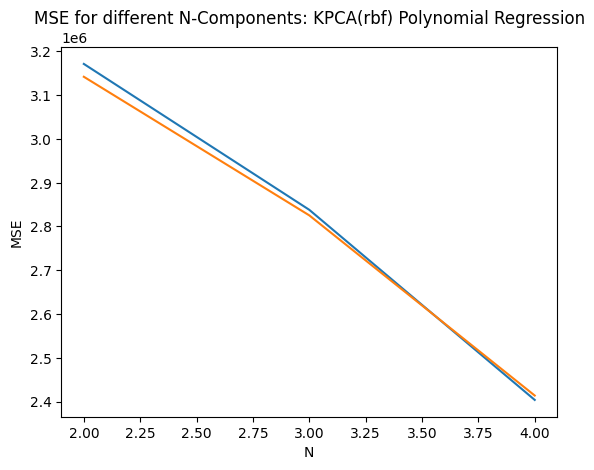

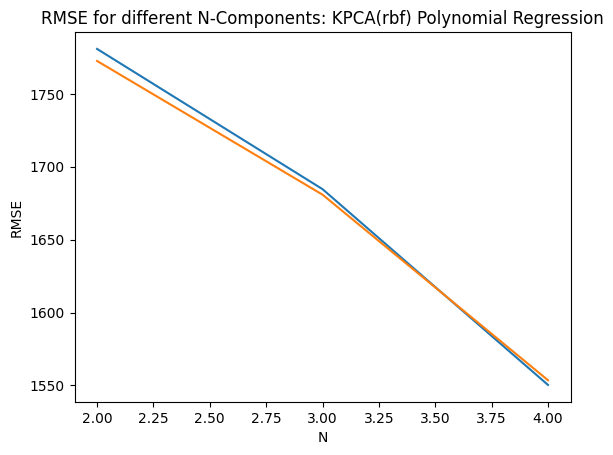

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []
degrees = np.arange(2,5)

kpcaObj = KernelPCA(n_components=3, kernel='rbf')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

for d in degrees:
    polyFeatureObj = PolynomialFeatures(degree=d)
    X_poly = polyFeatureObj.fit_transform(X_train_kpca)
    X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
    prObj = LinearRegression()
    prObj.fit(X_poly, y_train)

    #prediction on Val set
    v= polyFeatureObj.fit_transform(X_val_kpca)
    v = v[:,1:]
    y_val_pred=prObj.predict(v)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #prediction on Test set
    v= polyFeatureObj.fit_transform(X_test_kpca)
    v = v[:,1:]
    y_test_pred=prObj.predict(v)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(degrees, mse_val_list)
plt.plot(degrees, mse_test_list)
plt.title('MSE for different N-Components: KPCA(rbf) Polynomial Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(degrees, rmse_val_list)
plt.plot(degrees, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(rbf) Polynomial Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal KPCA - rbf Polynomial Regression on all features degree = 4

In [ ]:
polyFeatureObj = PolynomialFeatures(degree=4)
X_poly = polyFeatureObj.fit_transform(X_train_kpca)
X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
prObj = LinearRegression()
prObj.fit(X_poly, y_train)

#prediction on Val set
v= polyFeatureObj.fit_transform(X_val_kpca)
v = v[:,1:]
y_val_pred=prObj.predict(v)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#prediction on Test set
v= polyFeatureObj.fit_transform(X_test_kpca)
v = v[:,1:]
y_test_pred=prObj.predict(v)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  2403609.6481484408
MSE on Test Set:  2413616.8179664286
RMSE on Val Set:  1550.3579096932556
RMSE on Test Set:  1553.5819315267634


### KPCA - rbf Random Forest Regression on all features

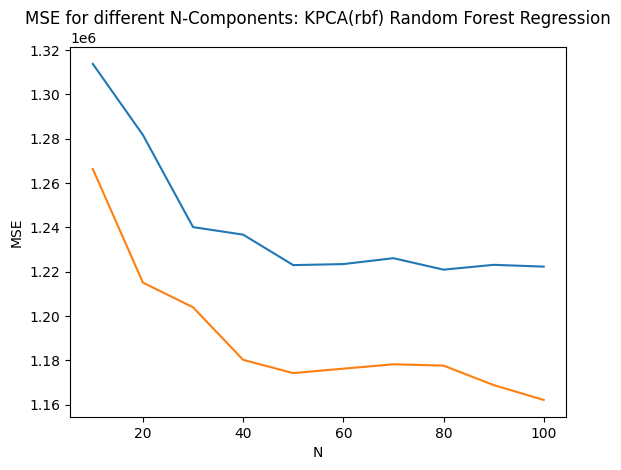

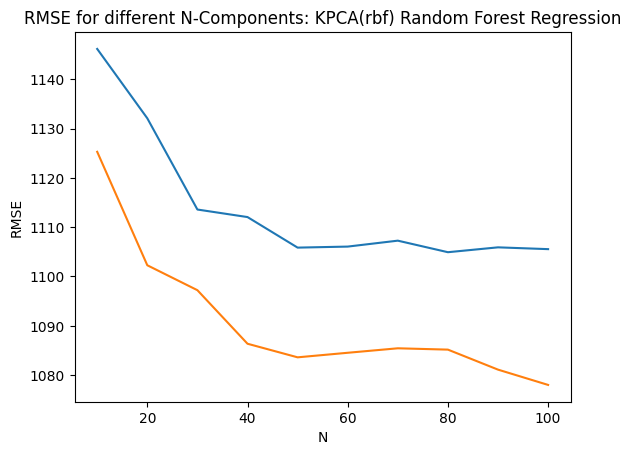

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import RandomForestRegressor

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []
tree_count= np.arange(10,110,10)

kpcaObj = KernelPCA(n_components=3, kernel='rbf')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

for trees in tree_count:
    RF_regObj = RandomForestRegressor(n_estimators=trees)
    RF_regObj.fit(X_train_kpca,y_train.ravel())

    #prediciton on Val set
    y_val_pred = RF_regObj.predict(X_val_kpca)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #Prediction on Test Set
    y_test_pred = RF_regObj.predict(X_test_kpca)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(tree_count, mse_val_list)
plt.plot(tree_count, mse_test_list)
plt.title('MSE for different N-Components: KPCA(rbf) Random Forest Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(tree_count, rmse_val_list)
plt.plot(tree_count, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(rbf) Random Forest Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal KPCA - rbf Random Forest Regression on all features estimator = 60

In [ ]:
RF_regObj = RandomForestRegressor(n_estimators=60)
RF_regObj.fit(X_train_kpca,y_train.ravel())

#prediciton on Val set
y_val_pred = RF_regObj.predict(X_val_kpca)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = RF_regObj.predict(X_test_kpca)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  1218446.649437335
MSE on Test Set:  1182724.040527615
RMSE on Val Set:  1103.8327089905133
RMSE on Test Set:  1087.5311676120436


### KPCA - rbf AdaBoost on all features

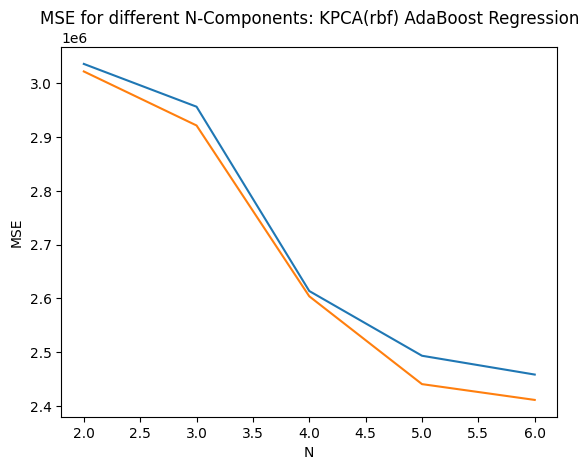

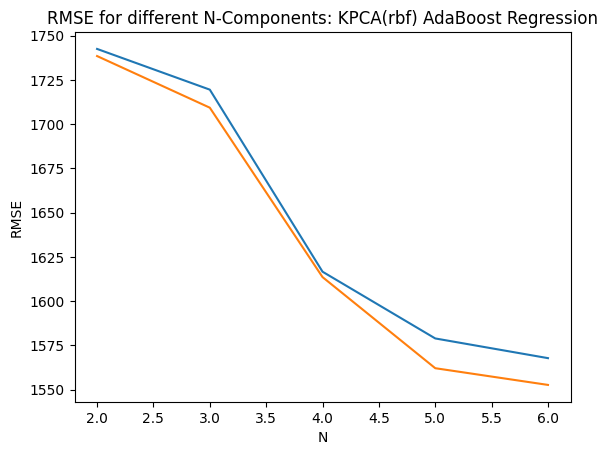

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import AdaBoostRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='rbf')

    X_train_kpca = kpcaObj.fit_transform(X_train)
    X_val_kpca = kpcaObj.transform(X_val)
    X_test_kpca = kpcaObj.transform(X_test)

    ABReg = AdaBoostRegressor()
    ABReg.fit(X_train_kpca,y_train.ravel())
    y_val_pred2 = ABReg.predict(X_val_kpca)
    y_test_pred2 = ABReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(rbf) AdaBoost Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(rbf) AdaBoost Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal KPCA - rbf AdaBoost on all features components = 5

In [ ]:
kpcaObj = KernelPCA(n_components=5, kernel='rbf')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

ABReg = AdaBoostRegressor()
ABReg.fit(X_train_kpca,y_train.ravel())
y_val_pred2 = ABReg.predict(X_val_kpca)
y_test_pred2 = ABReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  2478608.517060867
MSE on Test Set:  2436809.2612571185
RMSE on Val Set:  1574.3597165390338
RMSE on Test Set:  1561.028270486194


### KPCA - rbf GradientBoost on all features

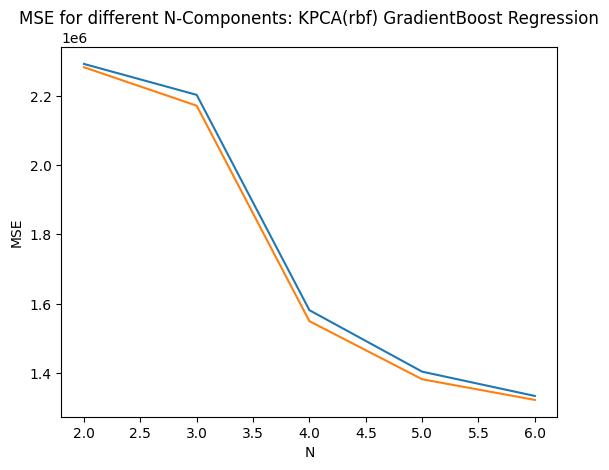

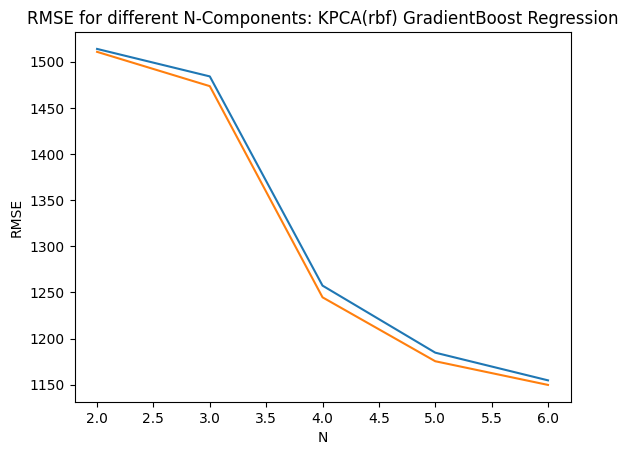

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import GradientBoostingRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='rbf')

    X_train_kpca = kpcaObj.fit_transform(X_train)
    X_val_kpca = kpcaObj.transform(X_val)
    X_test_kpca = kpcaObj.transform(X_test)

    GBReg = GradientBoostingRegressor()
    GBReg.fit(X_train_kpca,y_train.ravel())
    y_val_pred2 = GBReg.predict(X_val_kpca)
    y_test_pred2 = GBReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(rbf) GradientBoost Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(rbf) GradientBoost Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal KPCA - rbf GradientBoost on all features compoents = 4

In [ ]:
kpcaObj = KernelPCA(n_components=4, kernel='rbf')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

GBReg = GradientBoostingRegressor()
GBReg.fit(X_train_kpca,y_train.ravel())
y_val_pred2 = GBReg.predict(X_val_kpca)
y_test_pred2 = GBReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  1581123.0616607782
MSE on Test Set:  1549404.6631680503
RMSE on Val Set:  1257.4271595845137
RMSE on Test Set:  1244.7508438109412


### KPCA - rbf XGBoost on all features

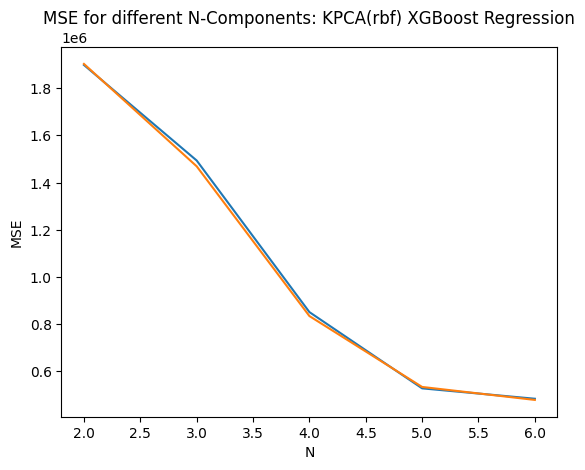

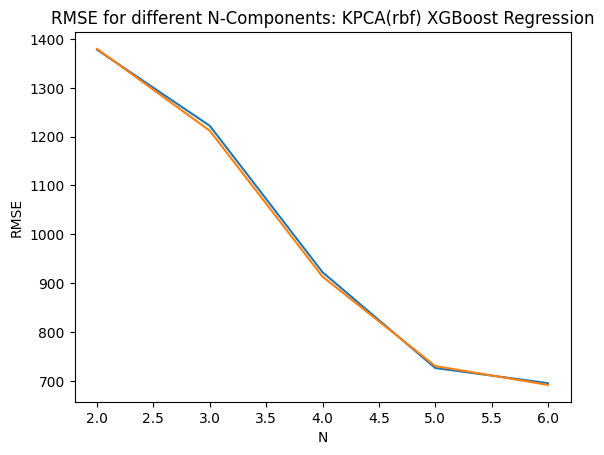

In [ ]:
from sklearn.decomposition import KernelPCA
from xgboost import XGBRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='rbf')

    X_train_kpca = kpcaObj.fit_transform(X_train)
    X_val_kpca = kpcaObj.transform(X_val)
    X_test_kpca = kpcaObj.transform(X_test)

    XGBReg = XGBRegressor()
    XGBReg.fit(X_train_kpca,y_train)
    y_val_pred2 = XGBReg.predict(X_val_kpca)
    y_test_pred2 = XGBReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(rbf) XGBoost Regression')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(rbf) XGBoost Regression')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal KPCA - rbf XGBoost on all features components = 5

In [ ]:
kpcaObj = KernelPCA(n_components=5, kernel='rbf')

X_train_kpca = kpcaObj.fit_transform(X_train)
X_val_kpca = kpcaObj.transform(X_val)
X_test_kpca = kpcaObj.transform(X_test)

XGBReg = XGBRegressor()
XGBReg.fit(X_train_kpca,y_train)
y_val_pred2 = XGBReg.predict(X_val_kpca)
y_test_pred2 = XGBReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  527380.7895418241
MSE on Test Set:  533296.320154848
RMSE on Val Set:  726.2098798156247
RMSE on Test Set:  730.2714017095617


### PCA Linear Regression on significant features

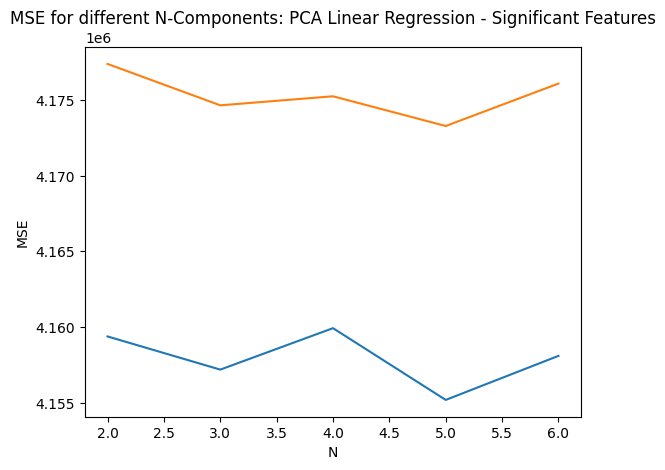

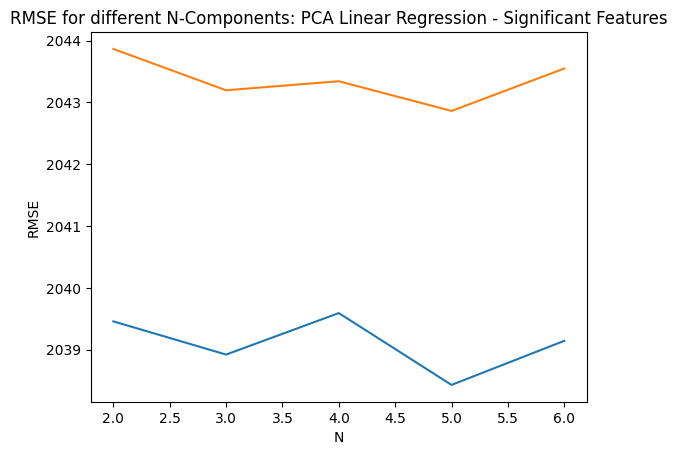

In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    pcaObj = PCA(n_components=i)

    X_train_pca = pcaObj.fit_transform(X_train_sig)
    X_val_pca = pcaObj.transform(X_val_sig)
    X_test_pca = pcaObj.transform(X_test_sig)

    LinReg = LinearRegression()
    LinReg.fit(X_train_pca,y_train)
    y_val_pred2 = LinReg.predict(X_val_pca)
    y_test_pred2 = LinReg.predict(X_test_pca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: PCA Linear Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: PCA Linear Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

###Optimal PCA Linear Regression on significant features - components = 3

In [ ]:
pcaObj = PCA(n_components=3)

X_train_pca = pcaObj.fit_transform(X_train_sig)
X_val_pca = pcaObj.transform(X_val_sig)
X_test_pca = pcaObj.transform(X_test_sig)

LinReg = LinearRegression()
LinReg.fit(X_train_pca,y_train)
y_val_pred2 = LinReg.predict(X_val_pca)
y_test_pred2 = LinReg.predict(X_test_pca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  4157192.5299406163
MSE on Test Set:  4174653.1416220507
RMSE on Val Set:  2038.919451557765
RMSE on Test Set:  2043.1967946387472


### PCA Decision Tree on significant features

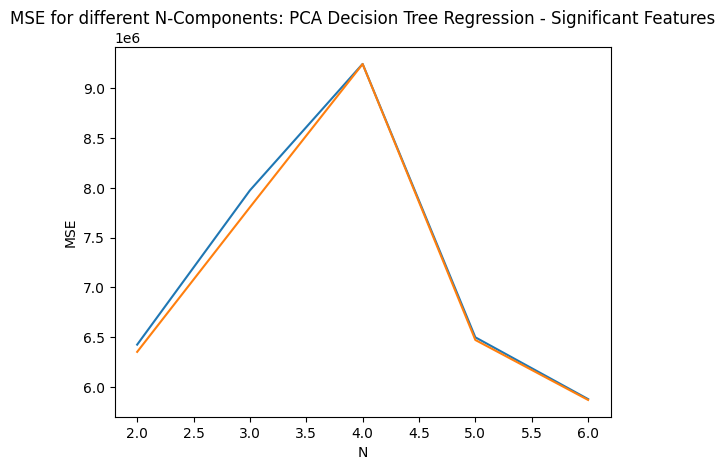

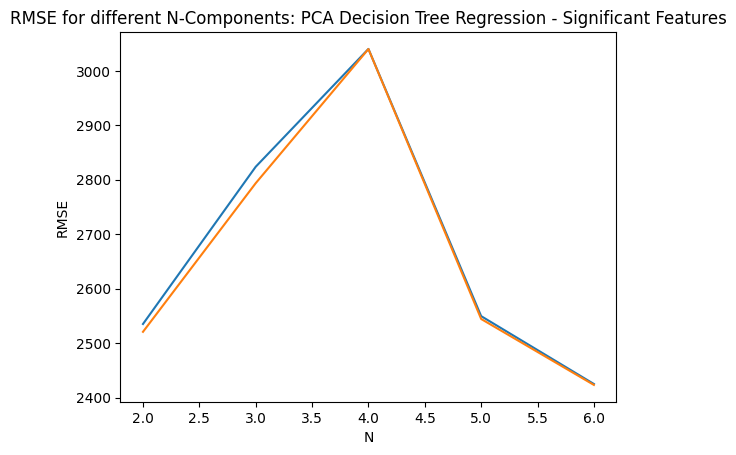

In [ ]:
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    pcaObj = PCA(n_components=i)

    X_train_pca = pcaObj.fit_transform(X_train_sig)
    X_val_pca = pcaObj.transform(X_val_sig)
    X_test_pca = pcaObj.transform(X_test_sig)

    DTReg = DecisionTreeRegressor()
    DTReg.fit(X_train_pca,y_train)
    y_val_pred2 = DTReg.predict(X_val_pca)
    y_test_pred2 = DTReg.predict(X_test_pca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: PCA Decision Tree Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: PCA Decision Tree Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

###Optimal - PCA Decision tree on significant features - components = 2

In [ ]:
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeRegressor

pcaObj = PCA(n_components=2)

X_train_pca = pcaObj.fit_transform(X_train_sig)
X_val_pca = pcaObj.transform(X_val_sig)
X_test_pca = pcaObj.transform(X_test_sig)

DTReg = DecisionTreeRegressor()
DTReg.fit(X_train_pca,y_train.ravel())
y_val_pred2 = DTReg.predict(X_val_pca)
y_test_pred2 = DTReg.predict(X_test_pca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)
rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  6578860.150575067
MSE on Test Set:  6488263.644700418
RMSE on Val Set:  2564.9288782683757
RMSE on Test Set:  2547.2070282370883


### PCA Polynomial Regression on significant features

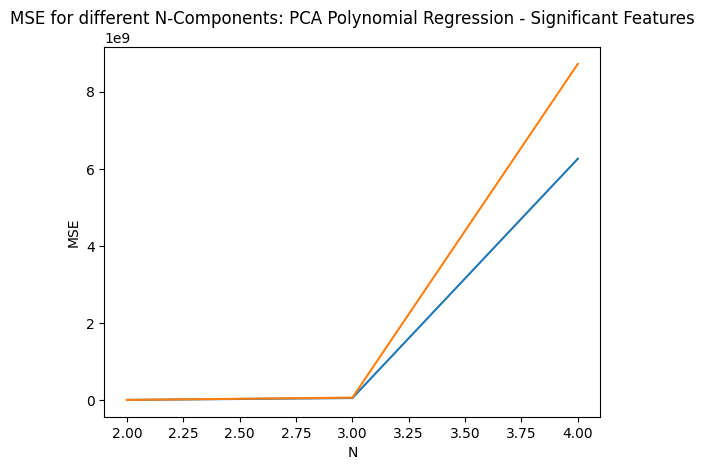

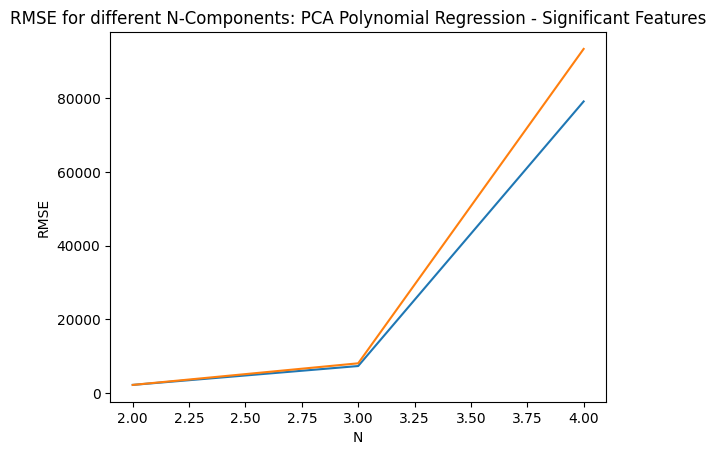

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []
degrees = np.arange(2,5)

pcaObj = PCA(n_components=3)

X_train_pca = pcaObj.fit_transform(X_train_sig)
X_val_pca = pcaObj.transform(X_val_sig)
X_test_pca = pcaObj.transform(X_test_sig)

for d in degrees:
    polyFeatureObj = PolynomialFeatures(degree=d)
    X_poly = polyFeatureObj.fit_transform(X_train_pca)
    X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
    prObj = LinearRegression()
    prObj.fit(X_poly, y_train)

    #prediction on Val set
    v= polyFeatureObj.fit_transform(X_val_pca)
    v = v[:,1:]
    y_val_pred=prObj.predict(v)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #prediction on Test set
    v= polyFeatureObj.fit_transform(X_test_pca)
    v = v[:,1:]
    y_test_pred=prObj.predict(v)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(degrees, mse_val_list)
plt.plot(degrees, mse_test_list)
plt.title('MSE for different N-Components: PCA Polynomial Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(degrees, rmse_val_list)
plt.plot(degrees, rmse_test_list)
plt.title('RMSE for different N-Components: PCA Polynomial Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal PCA Polynomial Regression on significant features - components = 3

In [ ]:
pcaObj = PCA(n_components=3)

X_train_pca = pcaObj.fit_transform(X_train_sig)
X_val_pca = pcaObj.transform(X_val_sig)
X_test_pca = pcaObj.transform(X_test_sig)

polyFeatureObj = PolynomialFeatures(degree=2)
X_poly = polyFeatureObj.fit_transform(X_train_pca)
X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
prObj = LinearRegression()
prObj.fit(X_poly, y_train)

#prediction on Val set
v= polyFeatureObj.fit_transform(X_val_pca)
v = v[:,1:]
y_val_pred=prObj.predict(v)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#prediction on Test set
v= polyFeatureObj.fit_transform(X_test_pca)
v = v[:,1:]
y_test_pred=prObj.predict(v)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  4688653.6215403
MSE on Test Set:  4668822.052860438
RMSE on Val Set:  2165.329910554117
RMSE on Test Set:  2160.745716844173


### PCA  Random Forest Regression on significant features

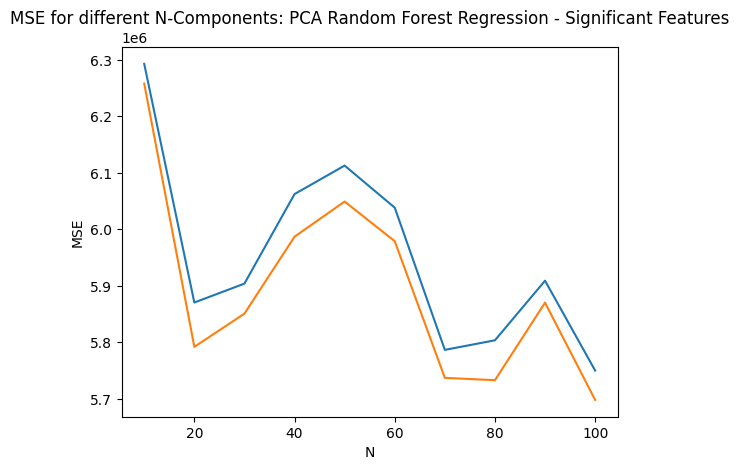

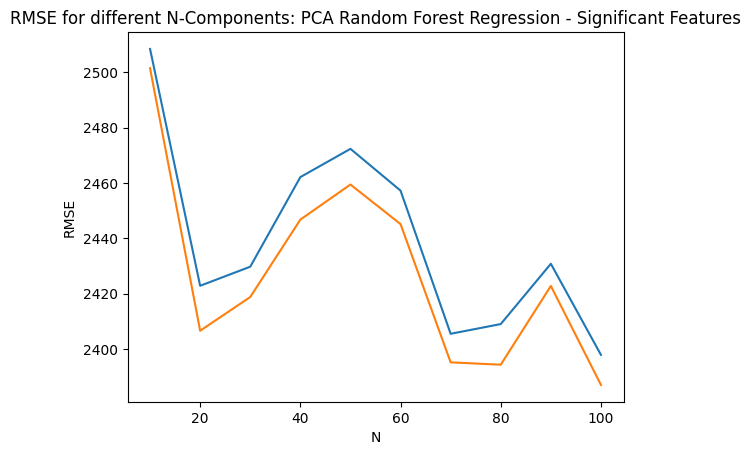

In [ ]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor


mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []
tree_count= np.arange(10,110,10)

pcaObj = PCA(n_components=3)

X_train_pca = pcaObj.fit_transform(X_train_sig)
X_val_pca = pcaObj.transform(X_val_sig)
X_test_pca = pcaObj.transform(X_test_sig)

for trees in tree_count:
    RF_regObj = RandomForestRegressor(n_estimators=trees)
    RF_regObj.fit(X_train_pca,y_train.ravel())

    #prediciton on Val set
    y_val_pred = RF_regObj.predict(X_val_pca)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #Prediction on Test Set
    y_test_pred = RF_regObj.predict(X_test_pca)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(tree_count, mse_val_list)
plt.plot(tree_count, mse_test_list)
plt.title('MSE for different N-Components: PCA Random Forest Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(tree_count, rmse_val_list)
plt.plot(tree_count, rmse_test_list)
plt.title('RMSE for different N-Components: PCA Random Forest Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal PCA  Random Forest Regression on significant features - components = 3, estimators = 20

In [ ]:
pcaObj = PCA(n_components=3)

X_train_pca = pcaObj.fit_transform(X_train_sig)
X_val_pca = pcaObj.transform(X_val_sig)
X_test_pca = pcaObj.transform(X_test_sig)

RF_regObj = RandomForestRegressor(n_estimators=20)
RF_regObj.fit(X_train_pca,y_train.ravel())

#prediciton on Val set
y_val_pred = RF_regObj.predict(X_val_pca)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = RF_regObj.predict(X_test_pca)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

#Appending Lists
mse_val_list.append(mse_val)
mse_test_list.append(mse_test)
rmse_val_list.append(rmse_val)
rmse_test_list.append(rmse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  6100679.396856298
MSE on Test Set:  6049737.046355791
RMSE on Val Set:  2469.9553430894853
RMSE on Test Set:  2459.621321739546


### PCA AdaBoost on significant features

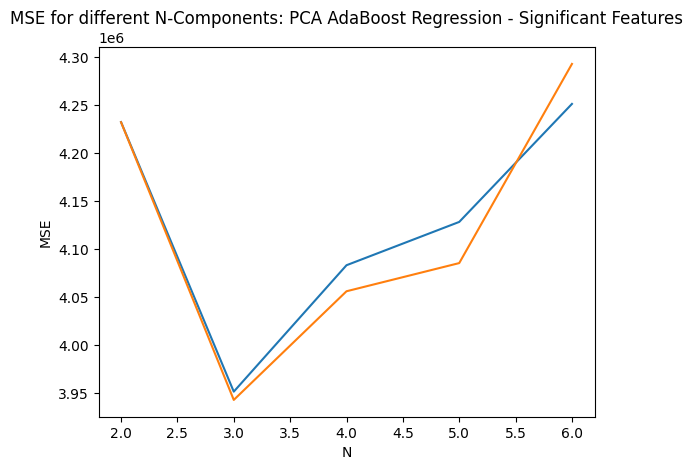

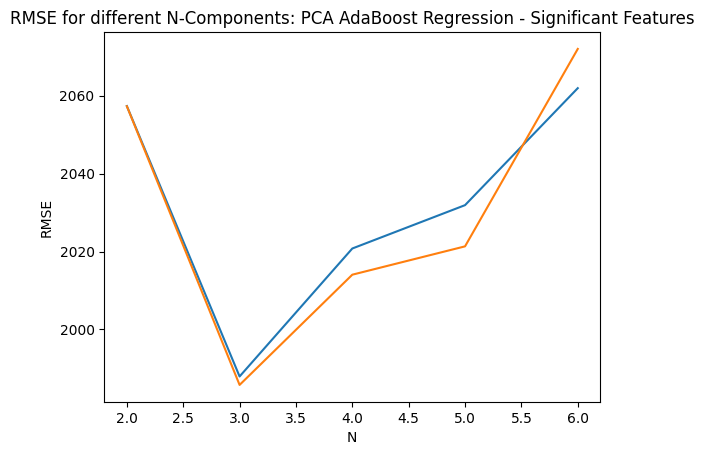

In [ ]:
from sklearn.decomposition import PCA
from sklearn.ensemble import AdaBoostRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    pcaObj = PCA(n_components=i)

    X_train_pca = pcaObj.fit_transform(X_train_sig)
    X_val_pca = pcaObj.transform(X_val_sig)
    X_test_pca = pcaObj.transform(X_test_sig)

    ABReg = AdaBoostRegressor()
    ABReg.fit(X_train_pca,y_train.ravel())
    y_val_pred2 = ABReg.predict(X_val_pca)
    y_test_pred2 = ABReg.predict(X_test_pca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: PCA AdaBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: PCA AdaBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal PCA AdaBoost on significant features - components = 3

In [ ]:
pcaObj = PCA(n_components=3)

X_train_pca = pcaObj.fit_transform(X_train_sig)
X_val_pca = pcaObj.transform(X_val_sig)
X_test_pca = pcaObj.transform(X_test_sig)

ABReg = AdaBoostRegressor()
ABReg.fit(X_train_pca,y_train.ravel())
y_val_pred2 = ABReg.predict(X_val_pca)
y_test_pred2 = ABReg.predict(X_test_pca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)


MSE on Val Set:  4027703.796351313
MSE on Test Set:  4017918.540202244
RMSE on Val Set:  2006.9139982448958
RMSE on Test Set:  2004.4746294733302


### PCA GradientBoost on significant features

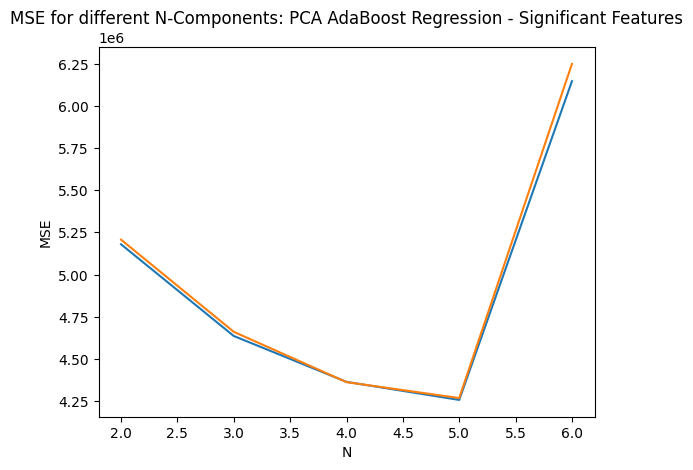

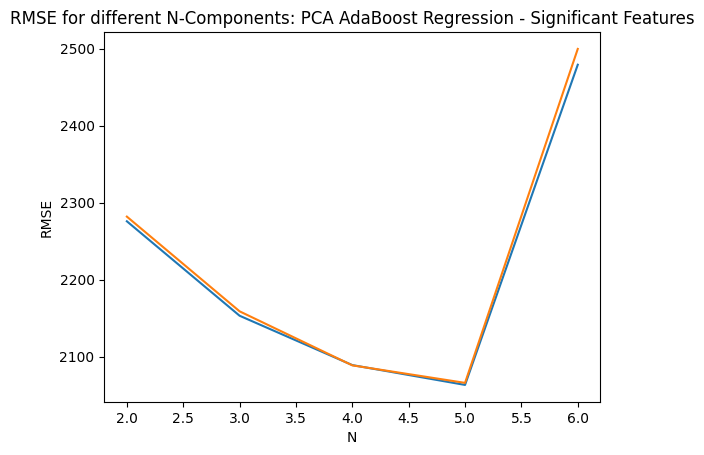

In [ ]:
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    pcaObj = PCA(n_components=i)

    X_train_pca = pcaObj.fit_transform(X_train_sig)
    X_val_pca = pcaObj.transform(X_val_sig)
    X_test_pca = pcaObj.transform(X_test_sig)

    GBReg = GradientBoostingRegressor()
    GBReg.fit(X_train_pca,y_train.ravel())
    y_val_pred2 = GBReg.predict(X_val_pca)
    y_test_pred2 = GBReg.predict(X_test_pca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: PCA AdaBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: PCA AdaBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal PCA GradientBoost on significant features - components = 5

In [ ]:
pcaObj = PCA(n_components=5)

X_train_pca = pcaObj.fit_transform(X_train_sig)
X_val_pca = pcaObj.transform(X_val_sig)
X_test_pca = pcaObj.transform(X_test_sig)

GBReg = GradientBoostingRegressor()
GBReg.fit(X_train_pca,y_train.ravel())
y_val_pred2 = GBReg.predict(X_val_pca)
y_test_pred2 = GBReg.predict(X_test_pca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  4257728.259583556
MSE on Test Set:  4268840.5324028535
RMSE on Val Set:  2063.4263397522955
RMSE on Test Set:  2066.117260080573


### PCA XGBoost on significant features

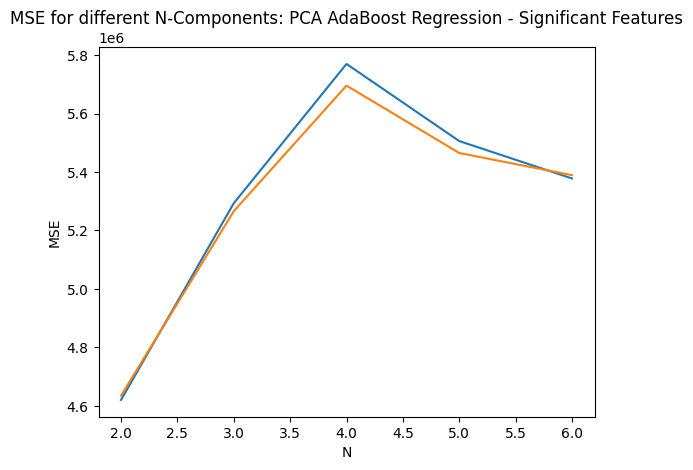

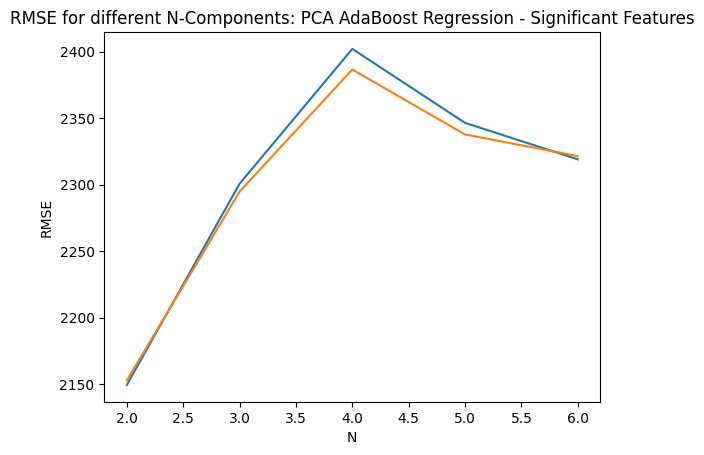

In [ ]:
from sklearn.decomposition import PCA
from xgboost import XGBRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    pcaObj = PCA(n_components=i)

    X_train_pca = pcaObj.fit_transform(X_train_sig)
    X_val_pca = pcaObj.transform(X_val_sig)
    X_test_pca = pcaObj.transform(X_test_sig)

    XGBReg = XGBRegressor()
    XGBReg.fit(X_train_pca,y_train)
    y_val_pred2 = XGBReg.predict(X_val_pca)
    y_test_pred2 = XGBReg.predict(X_test_pca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: PCA AdaBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: PCA AdaBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal PCA XGBoost on significant features - components = 2

In [ ]:
pcaObj = PCA(n_components=2)

X_train_pca = pcaObj.fit_transform(X_train_sig)
X_val_pca = pcaObj.transform(X_val_sig)
X_test_pca = pcaObj.transform(X_test_sig)

XGBReg = XGBRegressor()
XGBReg.fit(X_train_pca,y_train)
y_val_pred2 = XGBReg.predict(X_val_pca)
y_test_pred2 = XGBReg.predict(X_test_pca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  4619655.698097126
MSE on Test Set:  4634145.178987637
RMSE on Val Set:  2149.338432657157
RMSE on Test Set:  2152.706477666576


### KPCA - linear Linear Regression on significant features


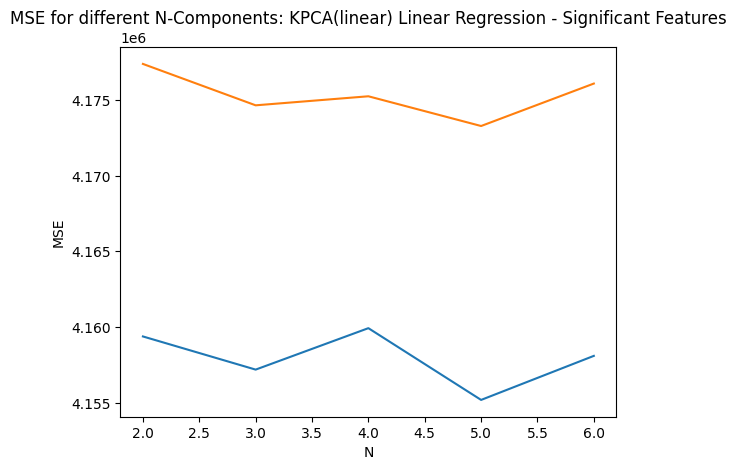

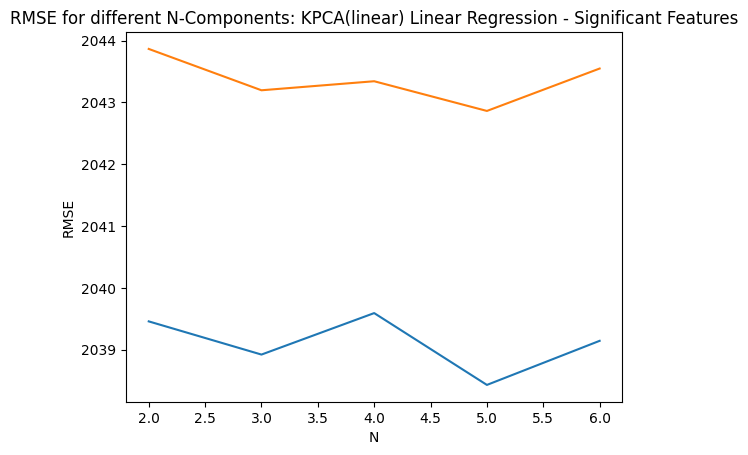

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LinearRegression

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='linear')

    X_train_kpca = kpcaObj.fit_transform(X_train_sig)
    X_val_kpca = kpcaObj.transform(X_val_sig)
    X_test_kpca = kpcaObj.transform(X_test_sig)

    LinReg = LinearRegression()
    LinReg.fit(X_train_kpca,y_train.ravel())
    y_val_pred2 = LinReg.predict(X_val_kpca)
    y_test_pred2 = LinReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(linear) Linear Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(linear) Linear Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal- KPCA - linear Linear Regression on significant features - Components = 3


In [ ]:
kpcaObj = KernelPCA(n_components=3, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

LinReg = LinearRegression()
LinReg.fit(X_train_kpca,y_train.ravel())
y_val_pred2 = LinReg.predict(X_val_kpca)
y_test_pred2 = LinReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  4157192.529940615
MSE on Test Set:  4174653.141622049
RMSE on Val Set:  2038.9194515577644
RMSE on Test Set:  2043.1967946387467


### KPCA - linear Decision Tree on significant features

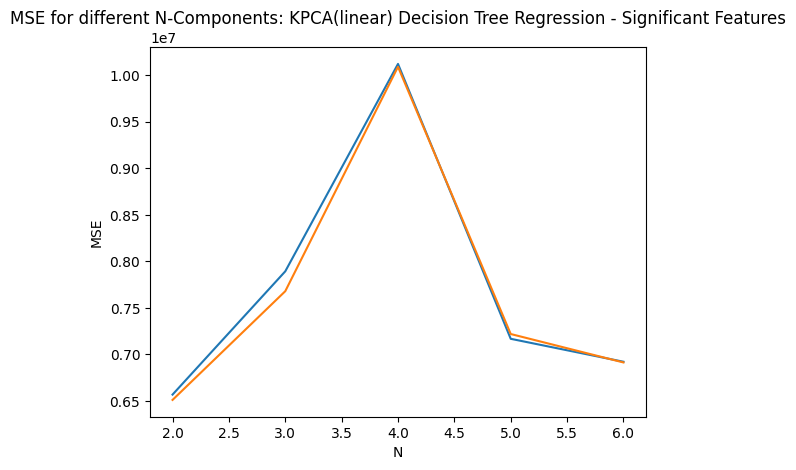

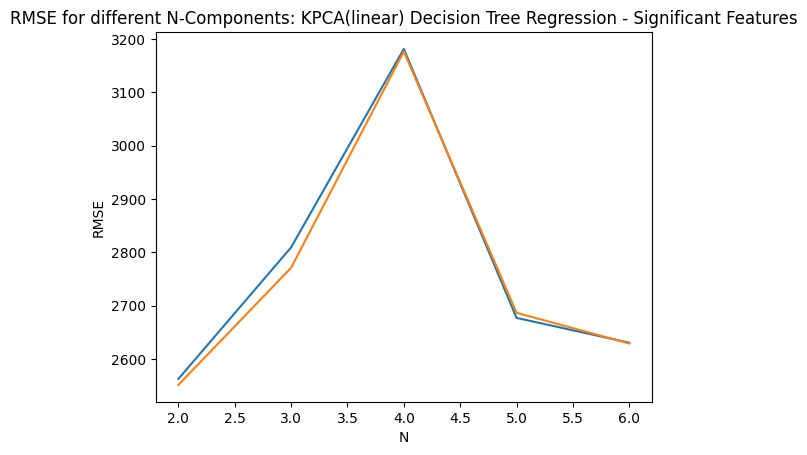

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.tree import DecisionTreeRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='linear')

    X_train_kpca = kpcaObj.fit_transform(X_train_sig)
    X_val_kpca = kpcaObj.transform(X_val_sig)
    X_test_kpca = kpcaObj.transform(X_test_sig)

    DTReg = DecisionTreeRegressor()
    DTReg.fit(X_train_kpca,y_train.ravel())
    y_val_pred2 = DTReg.predict(X_val_kpca)
    y_test_pred2 = DTReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(linear) Decision Tree Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(linear) Decision Tree Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - linear Decision Tree on significant features - Components = 2

In [ ]:
kpcaObj = KernelPCA(n_components=2, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

DTReg = DecisionTreeRegressor()
DTReg.fit(X_train_kpca,y_train.ravel())
y_val_pred2 = DTReg.predict(X_val_kpca)
y_test_pred2 = DTReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  6452136.110760395
MSE on Test Set:  6395826.68741018
RMSE on Val Set:  2540.1055314219516
RMSE on Test Set:  2528.9971703048977


### KPCA - linear Polynomial Regression on significant features

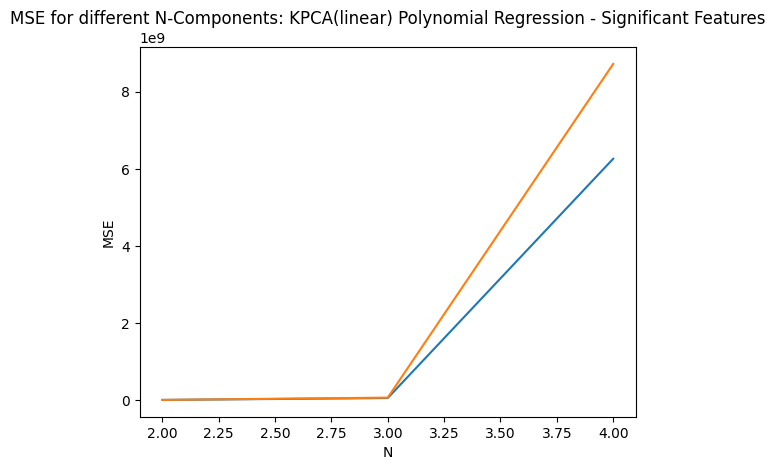

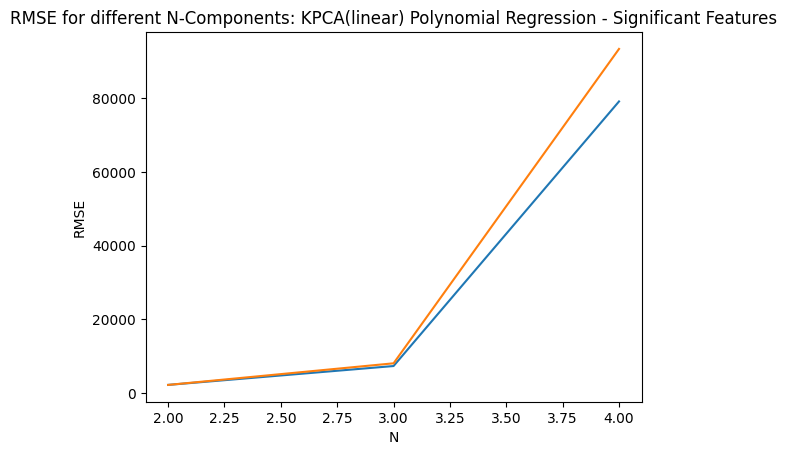

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []
degrees = np.arange(2,5)

kpcaObj = KernelPCA(n_components=3, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

for d in degrees:
    polyFeatureObj = PolynomialFeatures(degree=d)
    X_poly = polyFeatureObj.fit_transform(X_train_kpca)
    X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
    prObj = LinearRegression()
    prObj.fit(X_poly, y_train.ravel())

    #prediction on Val set
    v= polyFeatureObj.fit_transform(X_val_kpca)
    v = v[:,1:]
    y_val_pred=prObj.predict(v)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #prediction on Test set
    v= polyFeatureObj.fit_transform(X_test_kpca)
    v = v[:,1:]
    y_test_pred=prObj.predict(v)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(degrees, mse_val_list)
plt.plot(degrees, mse_test_list)
plt.title('MSE for different N-Components: KPCA(linear) Polynomial Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(degrees, rmse_val_list)
plt.plot(degrees, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(linear) Polynomial Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - linear Polynomial Regression on significant features - Degrees = 2

In [ ]:
kpcaObj = KernelPCA(n_components=3, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

polyFeatureObj = PolynomialFeatures(degree=2)
X_poly = polyFeatureObj.fit_transform(X_train_kpca)
X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
prObj = LinearRegression()
prObj.fit(X_poly, y_train.ravel())

#prediction on Val set
v= polyFeatureObj.fit_transform(X_val_kpca)
v = v[:,1:]
y_val_pred=prObj.predict(v)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#prediction on Test set
v= polyFeatureObj.fit_transform(X_test_kpca)
v = v[:,1:]
y_test_pred=prObj.predict(v)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  4688653.621540333
MSE on Test Set:  4668822.052860468
RMSE on Val Set:  2165.3299105541246
RMSE on Test Set:  2160.7457168441797


### KPCA - linear Random Forest Regression on significant features

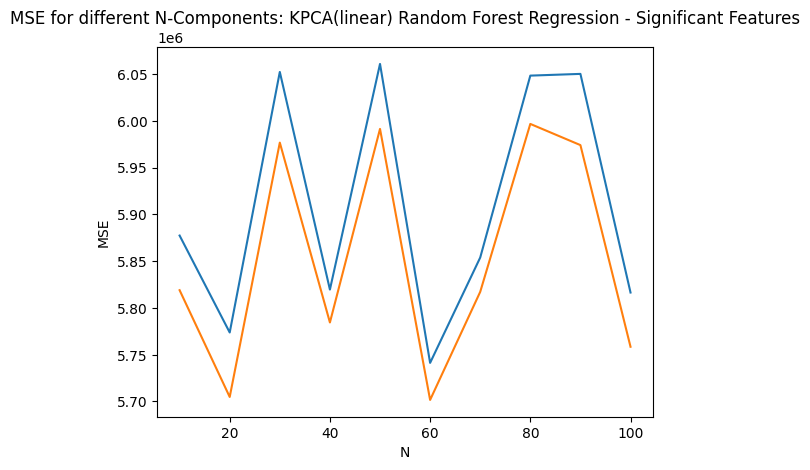

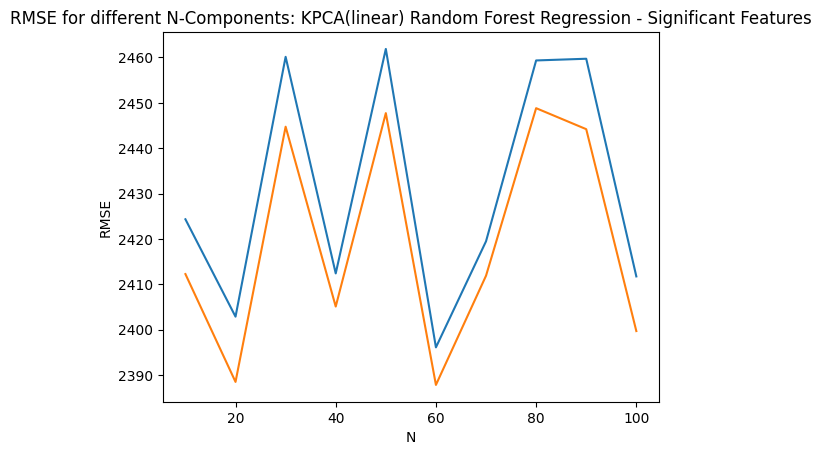

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import RandomForestRegressor

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []
tree_count= np.arange(10,110,10)

kpcaObj = KernelPCA(n_components=3, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

for trees in tree_count:
    RF_regObj = RandomForestRegressor(n_estimators=trees)
    RF_regObj.fit(X_train_kpca,y_train.ravel())

    #prediciton on Val set
    y_val_pred = RF_regObj.predict(X_val_kpca)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #Prediction on Test Set
    y_test_pred = RF_regObj.predict(X_test_kpca)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(tree_count, mse_val_list)
plt.plot(tree_count, mse_test_list)
plt.title('MSE for different N-Components: KPCA(linear) Random Forest Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(tree_count, rmse_val_list)
plt.plot(tree_count, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(linear) Random Forest Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - linear Random Forest Regression on significant features - Estimators = 20

In [ ]:
kpcaObj = KernelPCA(n_components=3, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

RF_regObj = RandomForestRegressor(n_estimators=20)
RF_regObj.fit(X_train_kpca,y_train.ravel())

#prediciton on Val set
y_val_pred = RF_regObj.predict(X_val_kpca)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = RF_regObj.predict(X_test_kpca)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  6038083.923855459
MSE on Test Set:  5981192.140534912
RMSE on Val Set:  2457.2512944050836
RMSE on Test Set:  2445.6475912393657


### KPCA - linear AdaBoost on significant features

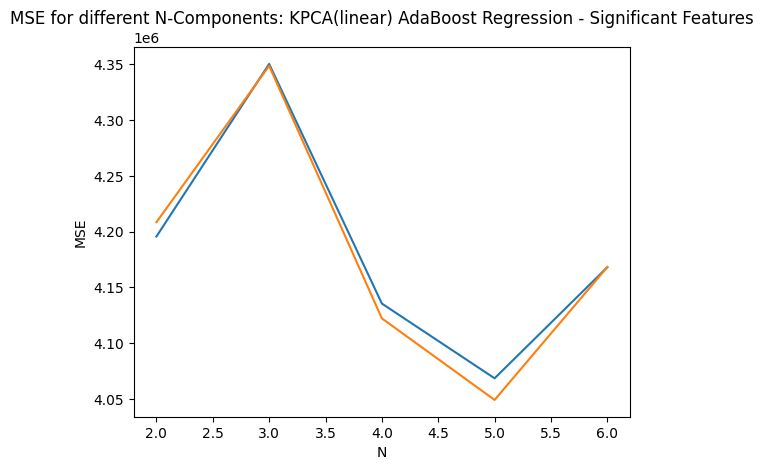

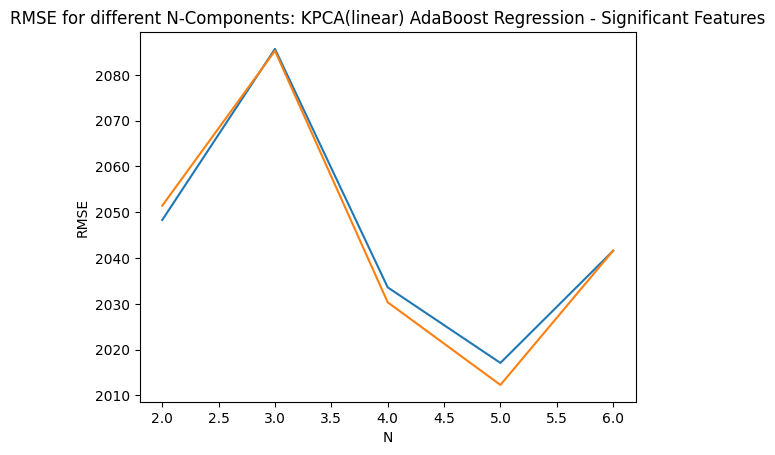

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import AdaBoostRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='linear')

    X_train_kpca = kpcaObj.fit_transform(X_train_sig)
    X_val_kpca = kpcaObj.transform(X_val_sig)
    X_test_kpca = kpcaObj.transform(X_test_sig)

    ABReg = AdaBoostRegressor()
    ABReg.fit(X_train_kpca,y_train.ravel())
    y_val_pred2 = ABReg.predict(X_val_kpca)
    y_test_pred2 = ABReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(linear) AdaBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(linear) AdaBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - linear AdaBoost on significant features- Components = 5

In [ ]:
kpcaObj = KernelPCA(n_components=5, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

ABReg = AdaBoostRegressor()
ABReg.fit(X_train_kpca,y_train.ravel())
y_val_pred2 = ABReg.predict(X_val_kpca)
y_test_pred2 = ABReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  4097032.112689591
MSE on Test Set:  4080334.2887518937
RMSE on Val Set:  2024.1126729235186
RMSE on Test Set:  2019.9837347740931


### KPCA - linear GradientBoost on significant features

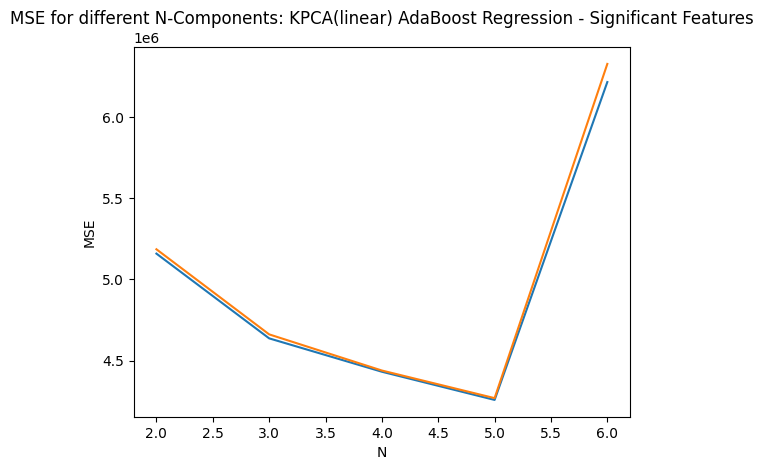

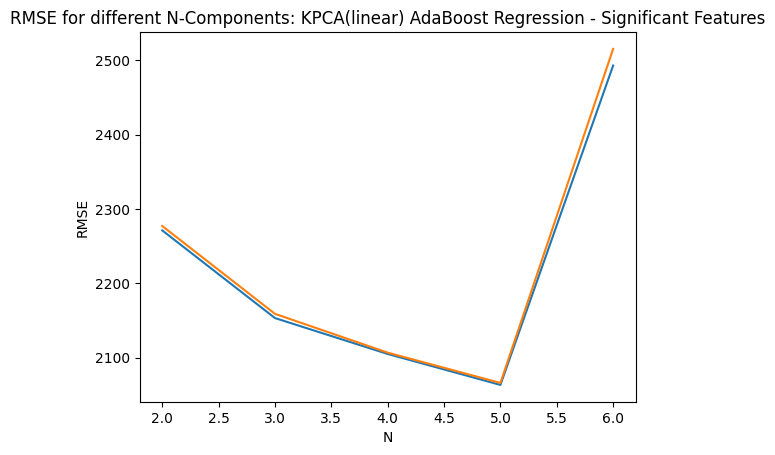

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import GradientBoostingRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='linear')

    X_train_kpca = kpcaObj.fit_transform(X_train_sig)
    X_val_kpca = kpcaObj.transform(X_val_sig)
    X_test_kpca = kpcaObj.transform(X_test_sig)

    GBReg = GradientBoostingRegressor()
    GBReg.fit(X_train_kpca,y_train.ravel())
    y_val_pred2 = GBReg.predict(X_val_kpca)
    y_test_pred2 = GBReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(linear) AdaBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(linear) AdaBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - linear GradientBoost on significant features - Components= 5

In [ ]:
kpcaObj = KernelPCA(n_components=5, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

GBReg = GradientBoostingRegressor()
GBReg.fit(X_train_kpca,y_train.ravel())
y_val_pred2 = GBReg.predict(X_val_kpca)
y_test_pred2 = GBReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  4257728.259583558
MSE on Test Set:  4268840.532402854
RMSE on Val Set:  2063.426339752296
RMSE on Test Set:  2066.117260080573


### KPCA - linear XGBoost on signficant features

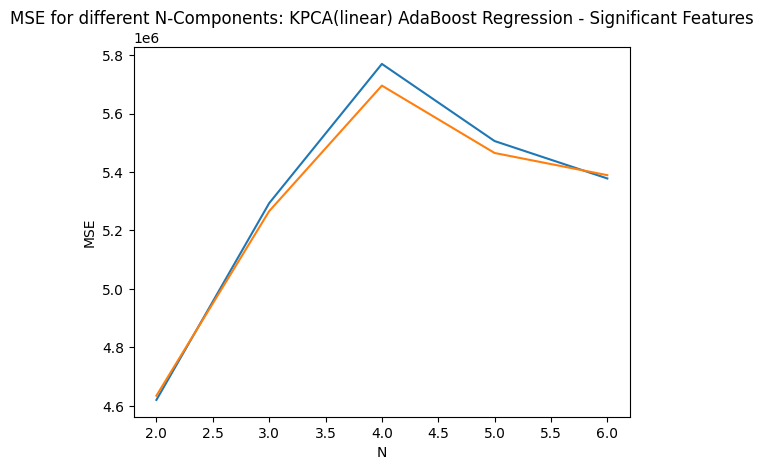

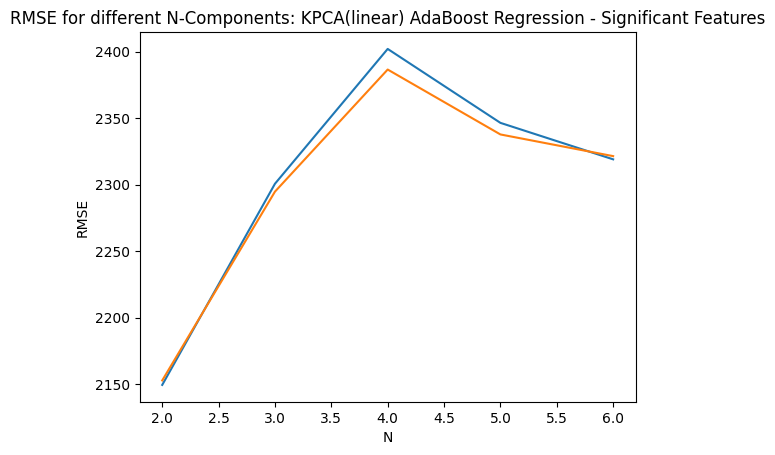

In [ ]:
from sklearn.decomposition import KernelPCA
from xgboost import XGBRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='linear')

    X_train_kpca = kpcaObj.fit_transform(X_train_sig)
    X_val_kpca = kpcaObj.transform(X_val_sig)
    X_test_kpca = kpcaObj.transform(X_test_sig)

    XGBReg = XGBRegressor()
    XGBReg.fit(X_train_kpca,y_train.ravel())
    y_val_pred2 = XGBReg.predict(X_val_kpca)
    y_test_pred2 = XGBReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(linear) AdaBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(linear) AdaBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - linear XGBoost on signficant features - Components = 2

In [ ]:
kpcaObj = KernelPCA(n_components=2, kernel='linear')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

XGBReg = XGBRegressor()
XGBReg.fit(X_train_kpca,y_train.ravel())
y_val_pred2 = XGBReg.predict(X_val_kpca)
y_test_pred2 = XGBReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  4619655.698097126
MSE on Test Set:  4634145.178987637
RMSE on Val Set:  2149.338432657157
RMSE on Test Set:  2152.706477666576


### KPCA - poly Linear Regression on significant features

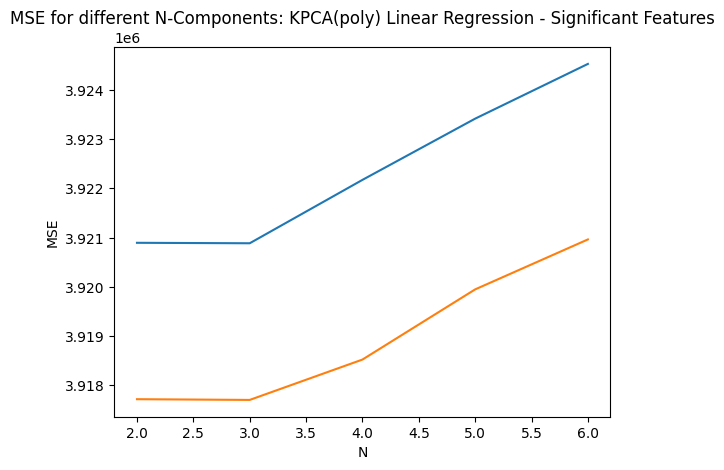

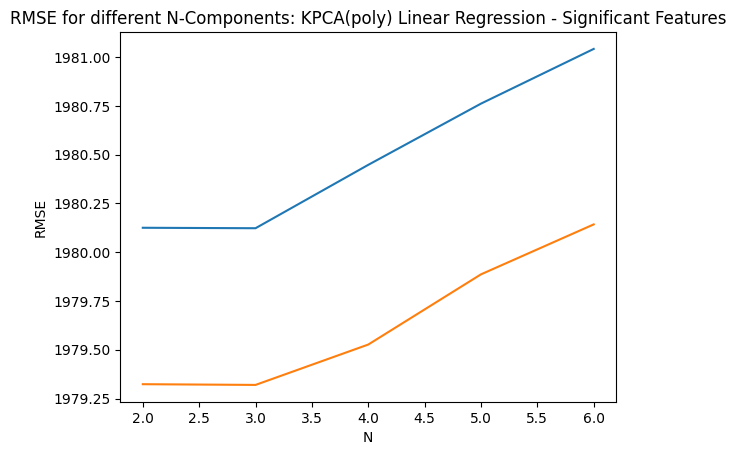

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LinearRegression

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='poly')

    X_train_kpca = kpcaObj.fit_transform(X_train_sig)
    X_val_kpca = kpcaObj.transform(X_val_sig)
    X_test_kpca = kpcaObj.transform(X_test_sig)

    LinReg = LinearRegression()
    LinReg.fit(X_train_kpca,y_train.ravel())
    y_val_pred2 = LinReg.predict(X_val_kpca)
    y_test_pred2 = LinReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(poly) Linear Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(poly) Linear Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - poly Linear Regression on significant features - Components = 2

In [ ]:
kpcaObj = KernelPCA(n_components=2, kernel='poly')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

LinReg = LinearRegression()
LinReg.fit(X_train_kpca,y_train.ravel())
y_val_pred2 = LinReg.predict(X_val_kpca)
y_test_pred2 = LinReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  3920895.3145799018
MSE on Test Set:  3917721.049939421
RMSE on Val Set:  1980.125075488895
RMSE on Test Set:  1979.3233818503284


### KPCA - poly Decision Tree on significant features

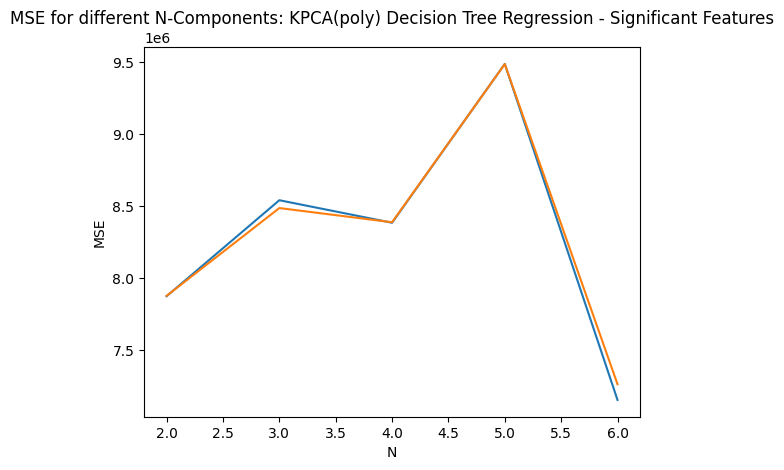

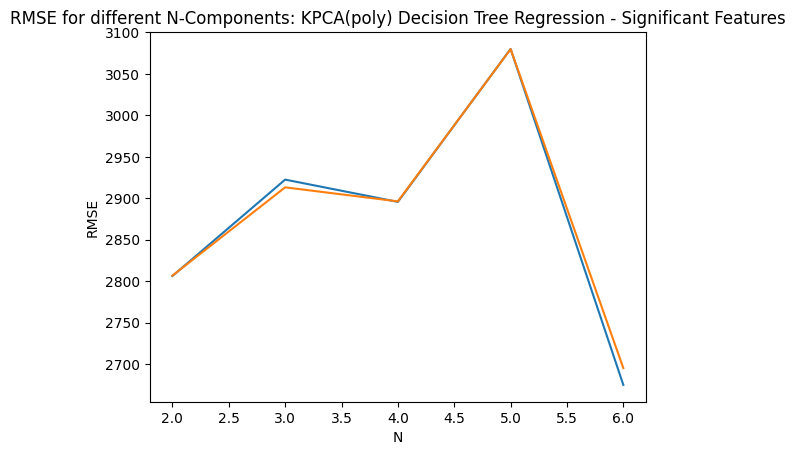

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.tree import DecisionTreeRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='poly')

    X_train_kpca = kpcaObj.fit_transform(X_train_sig)
    X_val_kpca = kpcaObj.transform(X_val_sig)
    X_test_kpca = kpcaObj.transform(X_test_sig)

    DTReg = DecisionTreeRegressor()
    DTReg.fit(X_train_kpca,y_train)
    y_val_pred2 = DTReg.predict(X_val_kpca)
    y_test_pred2 = DTReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(poly) Decision Tree Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(poly) Decision Tree Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - poly Decision Tree on significant features - Components = 6

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.tree import DecisionTreeRegressor

kpcaObj = KernelPCA(n_components=6, kernel='poly')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

DTReg = DecisionTreeRegressor()
DTReg.fit(X_train_kpca,y_train)
y_val_pred2 = DTReg.predict(X_val_kpca)
y_test_pred2 = DTReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  7568427.883742007
MSE on Test Set:  7635622.99345865
RMSE on Val Set:  2751.0775859182904
RMSE on Test Set:  2763.2631060864705


### KPCA - poly Polynomial Regression on significant features

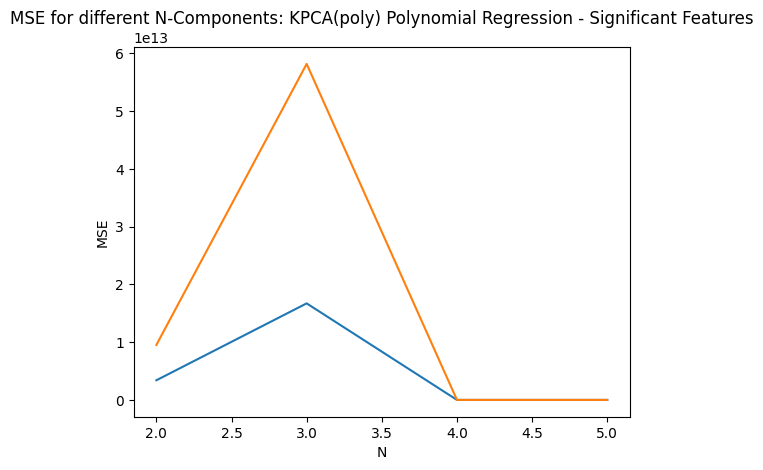

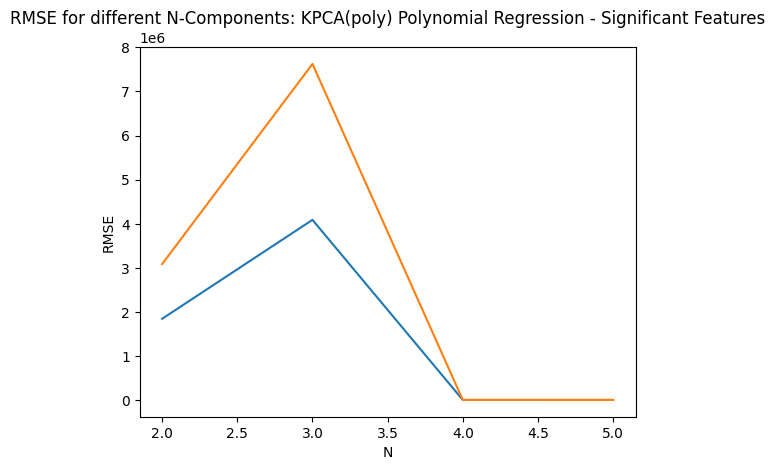

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []
degrees = np.arange(2,6)

kpcaObj = KernelPCA(n_components=i, kernel='poly')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

for d in degrees:
    polyFeatureObj = PolynomialFeatures(degree=d)
    X_poly = polyFeatureObj.fit_transform(X_train_kpca)
    X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
    prObj = LinearRegression()
    prObj.fit(X_poly, y_train)

    #prediction on Val set
    v= polyFeatureObj.fit_transform(X_val_kpca)
    v = v[:,1:]
    y_val_pred=prObj.predict(v)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #prediction on Test set
    v= polyFeatureObj.fit_transform(X_test_kpca)
    v = v[:,1:]
    y_test_pred=prObj.predict(v)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(degrees, mse_val_list)
plt.plot(degrees, mse_test_list)
plt.title('MSE for different N-Components: KPCA(poly) Polynomial Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(degrees, rmse_val_list)
plt.plot(degrees, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(poly) Polynomial Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal- KPCA - poly Polynomial Regression on significant features - Degrees = 4

In [ ]:
kpcaObj = KernelPCA(n_components=3, kernel='poly')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

polyFeatureObj = PolynomialFeatures(degree=4)
X_poly = polyFeatureObj.fit_transform(X_train_kpca)
X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
prObj = LinearRegression()
prObj.fit(X_poly, y_train)

#prediction on Val set
v= polyFeatureObj.fit_transform(X_val_kpca)
v = v[:,1:]
y_val_pred=prObj.predict(v)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#prediction on Test set
v= polyFeatureObj.fit_transform(X_test_kpca)
v = v[:,1:]
y_test_pred=prObj.predict(v)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  4165077.808197844
MSE on Test Set:  4857802.586224894
RMSE on Val Set:  2040.8522259580295
RMSE on Test Set:  2204.04232859192


### KPCA - poly Random Forest Regression on significant features

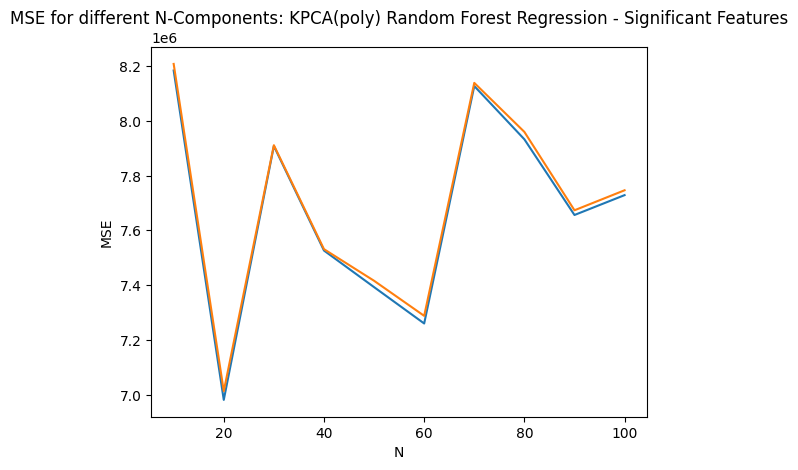

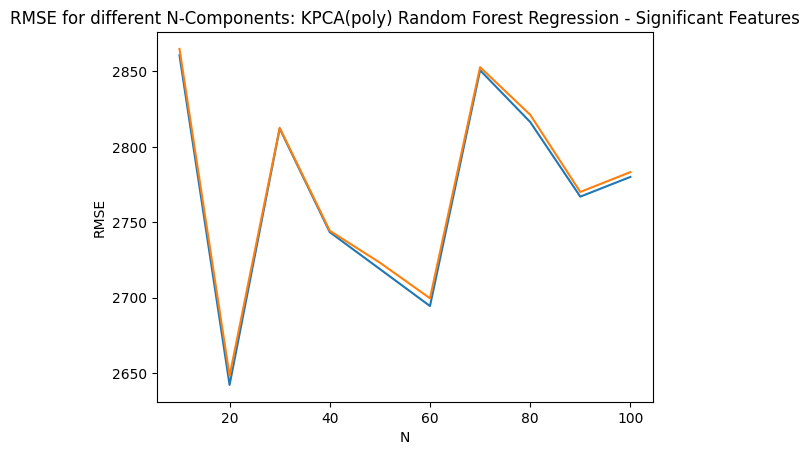

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import RandomForestRegressor

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []
tree_count= np.arange(10,110,10)

kpcaObj = KernelPCA(n_components=3, kernel='poly')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

for trees in tree_count:
    RF_regObj = RandomForestRegressor(n_estimators=trees)
    RF_regObj.fit(X_train_kpca,y_train.ravel())

    #prediciton on Val set
    y_val_pred = RF_regObj.predict(X_val_kpca)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #Prediction on Test Set
    y_test_pred = RF_regObj.predict(X_test_kpca)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(tree_count, mse_val_list)
plt.plot(tree_count, mse_test_list)
plt.title('MSE for different N-Components: KPCA(poly) Random Forest Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(tree_count, rmse_val_list)
plt.plot(tree_count, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(poly) Random Forest Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - poly Random Forest Regression on significant features - Estimators = 20

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import RandomForestRegressor

kpcaObj = KernelPCA(n_components=3, kernel='poly')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

RF_regObj = RandomForestRegressor(n_estimators=20)
RF_regObj.fit(X_train_kpca,y_train.ravel())

#prediciton on Val set
y_val_pred = RF_regObj.predict(X_val_kpca)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = RF_regObj.predict(X_test_kpca)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  7713042.239512444
MSE on Test Set:  7720354.279875137
RMSE on Val Set:  2777.236439252597
RMSE on Test Set:  2778.552551217115


### KPCA - poly AdaBoost on significant features

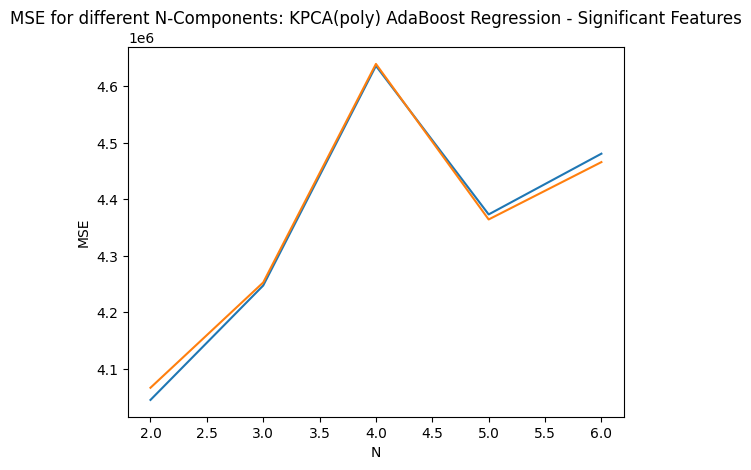

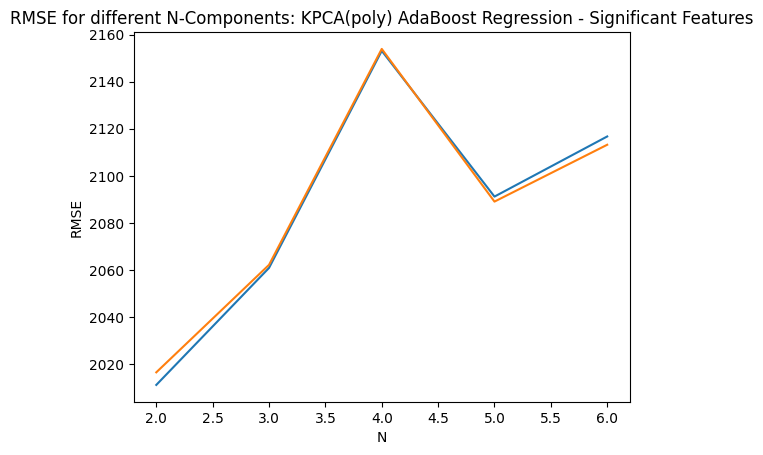

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import AdaBoostRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='poly')

    X_train_kpca = kpcaObj.fit_transform(X_train_sig)
    X_val_kpca = kpcaObj.transform(X_val_sig)
    X_test_kpca = kpcaObj.transform(X_test_sig)

    ABReg = AdaBoostRegressor()
    ABReg.fit(X_train_kpca,y_train.ravel())
    y_val_pred2 = ABReg.predict(X_val_kpca)
    y_test_pred2 = ABReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(poly) AdaBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(poly) AdaBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - poly AdaBoost on significant features - Components = 2

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import AdaBoostRegressor

kpcaObj = KernelPCA(n_components=2, kernel='poly')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

ABReg = AdaBoostRegressor()
ABReg.fit(X_train_kpca,y_train.ravel())
y_val_pred2 = ABReg.predict(X_val_kpca)
y_test_pred2 = ABReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  4085345.1473158062
MSE on Test Set:  4090915.9549545306
RMSE on Val Set:  2021.2236757261196
RMSE on Test Set:  2022.6012842264613


### KPCA - poly GradientBoost on significant features

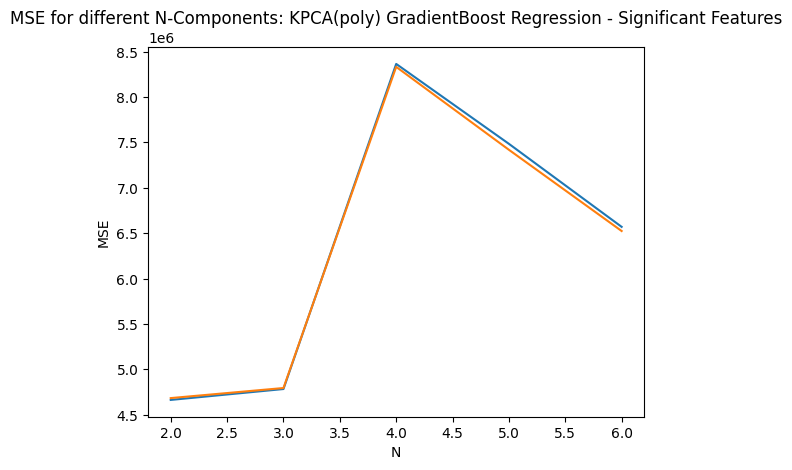

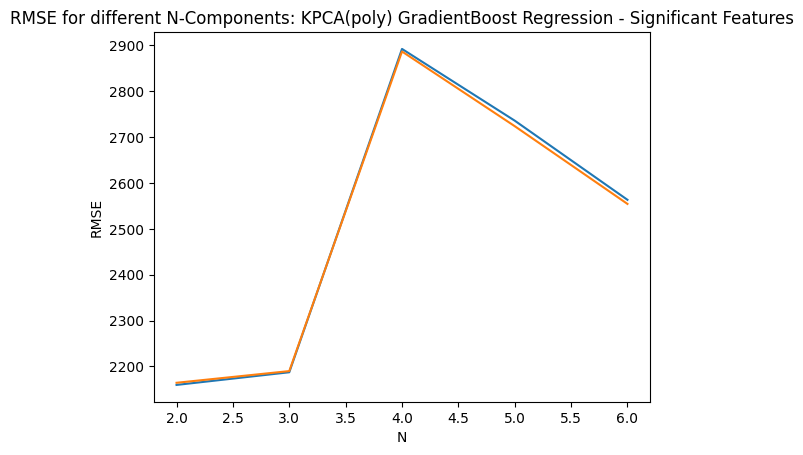

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import GradientBoostingRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='poly')

    X_train_kpca = kpcaObj.fit_transform(X_train_sig)
    X_val_kpca = kpcaObj.transform(X_val_sig)
    X_test_kpca = kpcaObj.transform(X_test_sig)

    GBReg = GradientBoostingRegressor()
    GBReg.fit(X_train_kpca,y_train.ravel())
    y_val_pred2 = GBReg.predict(X_val_kpca)
    y_test_pred2 = GBReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(poly) GradientBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(poly) GradientBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - poly GradientBoost on significant features - Components = 2

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import GradientBoostingRegressor

kpcaObj = KernelPCA(n_components=2, kernel='poly')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

GBReg = GradientBoostingRegressor()
GBReg.fit(X_train_kpca,y_train.ravel())
y_val_pred2 = GBReg.predict(X_val_kpca)
y_test_pred2 = GBReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  4664745.1255870005
MSE on Test Set:  4684893.030156646
RMSE on Val Set:  2159.8021033388686
RMSE on Test Set:  2164.4613718328737


### KPCA - poly XGBoost on significant features

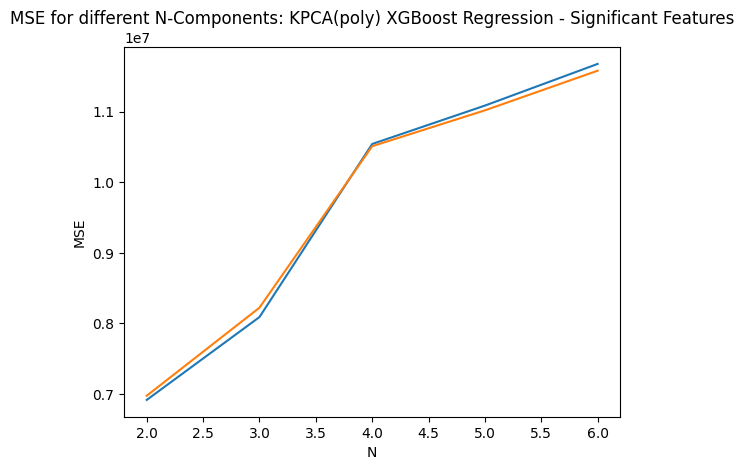

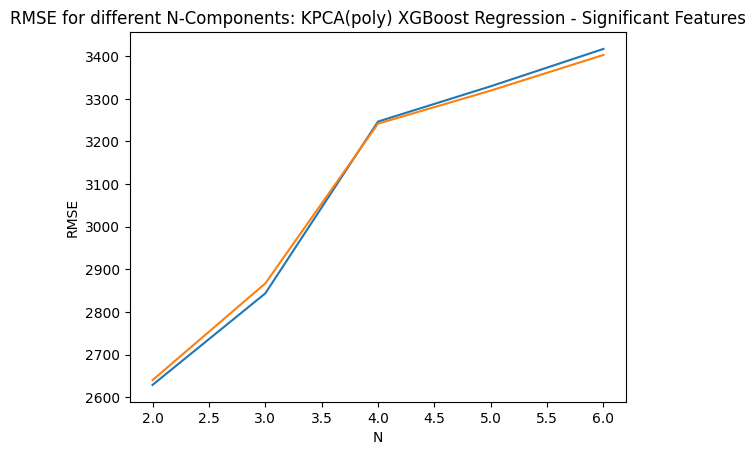

In [ ]:
from sklearn.decomposition import KernelPCA
from xgboost import XGBRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='poly')

    X_train_kpca = kpcaObj.fit_transform(X_train_sig)
    X_val_kpca = kpcaObj.transform(X_val_sig)
    X_test_kpca = kpcaObj.transform(X_test_sig)

    XGBReg = XGBRegressor()
    XGBReg.fit(X_train_kpca,y_train)
    y_val_pred2 = XGBReg.predict(X_val_kpca)
    y_test_pred2 = XGBReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(poly) XGBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(poly) XGBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - poly XGBoost on significant features - Components=2

In [ ]:
kpcaObj = KernelPCA(n_components=2, kernel='poly')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

XGBReg = XGBRegressor()
XGBReg.fit(X_train_kpca,y_train)
y_val_pred2 = XGBReg.predict(X_val_kpca)
y_test_pred2 = XGBReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  6913365.77926901
MSE on Test Set:  6972367.995048802
RMSE on Val Set:  2629.328009067908
RMSE on Test Set:  2640.5241894458763


### KPCA - rbf Linear Regression on significant features


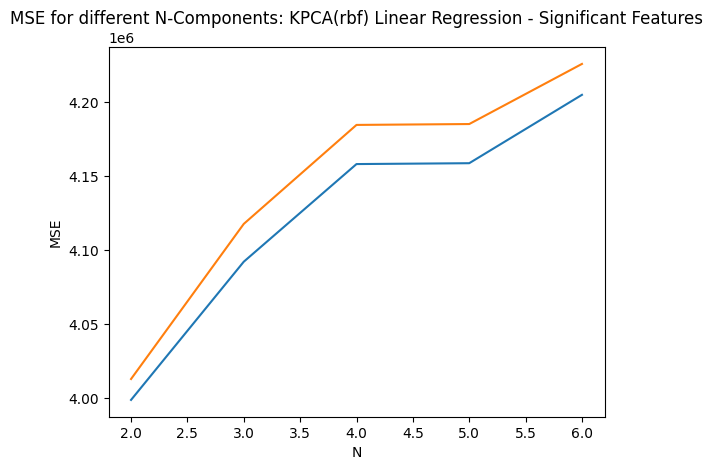

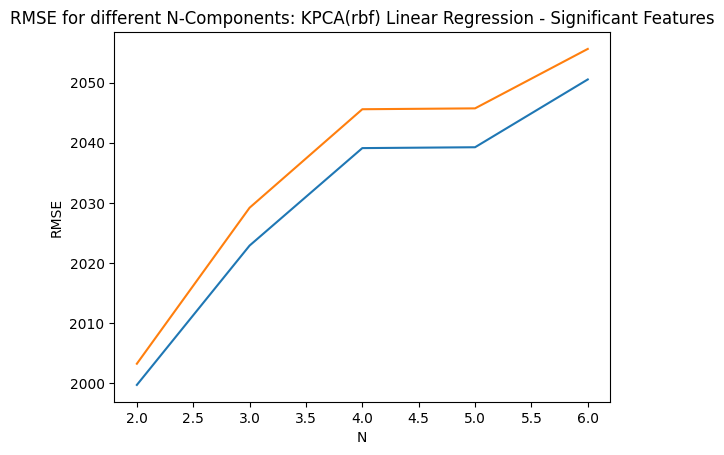

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LinearRegression

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='rbf')

    X_train_kpca = kpcaObj.fit_transform(X_train_sig)
    X_val_kpca = kpcaObj.transform(X_val_sig)
    X_test_kpca = kpcaObj.transform(X_test_sig)

    LinReg = LinearRegression()
    LinReg.fit(X_train_kpca,y_train)
    y_val_pred2 = LinReg.predict(X_val_kpca)
    y_test_pred2 = LinReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(rbf) Linear Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(rbf) Linear Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - rbf Linear Regression on significant features - Components = 2

In [ ]:
kpcaObj = KernelPCA(n_components=2, kernel='rbf')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

LinReg = LinearRegression()
LinReg.fit(X_train_kpca,y_train)
y_val_pred2 = LinReg.predict(X_val_kpca)
y_test_pred2 = LinReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  3998686.1651762715
MSE on Test Set:  4012811.8127406472
RMSE on Val Set:  1999.6715143183571
RMSE on Test Set:  2003.200392557032


### KPCA - rbf Decision Tree on significant features

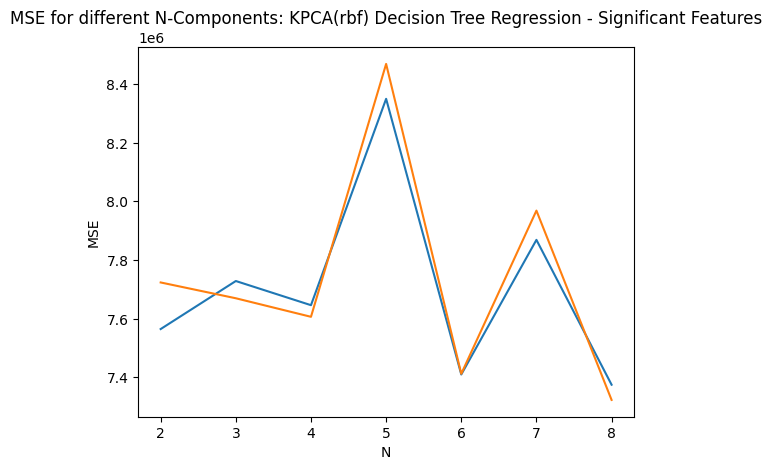

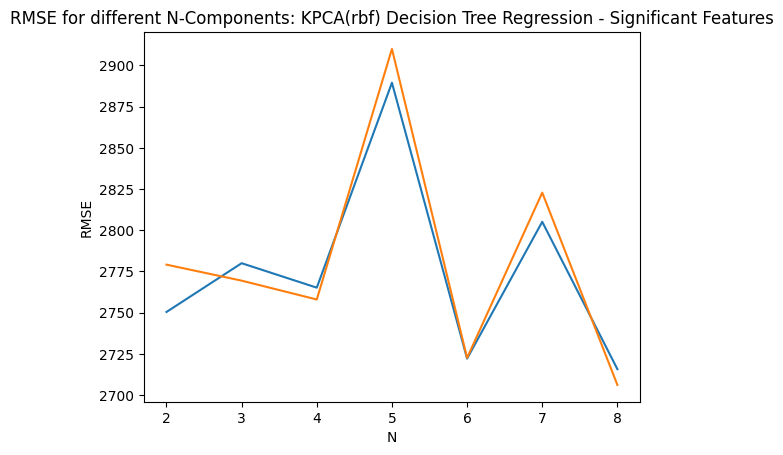

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.tree import DecisionTreeRegressor

x_axis_n = np.arange(2,9)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='rbf')

    X_train_kpca = kpcaObj.fit_transform(X_train_sig)
    X_val_kpca = kpcaObj.transform(X_val_sig)
    X_test_kpca = kpcaObj.transform(X_test_sig)

    DTReg = DecisionTreeRegressor()
    DTReg.fit(X_train_kpca,y_train)
    y_val_pred2 = DTReg.predict(X_val_kpca)
    y_test_pred2 = DTReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(rbf) Decision Tree Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(rbf) Decision Tree Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - rbf Decision Tree on significant features - Components = 6

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.tree import DecisionTreeRegressor

kpcaObj = KernelPCA(n_components=6, kernel='rbf')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

DTReg = DecisionTreeRegressor()
DTReg.fit(X_train_kpca,y_train)
y_val_pred2 = DTReg.predict(X_val_kpca)
y_test_pred2 = DTReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  7493240.69596084
MSE on Test Set:  7489848.518778668
RMSE on Val Set:  2737.378434919228
RMSE on Test Set:  2736.7587615240527


### KPCA - rbf Polynomial Regression on significant features


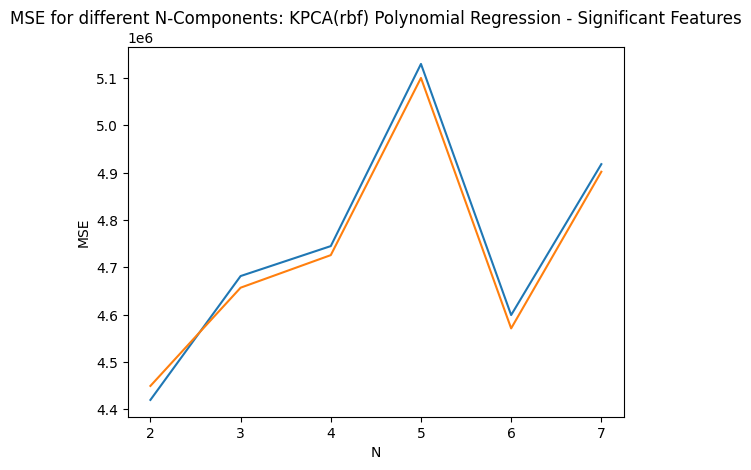

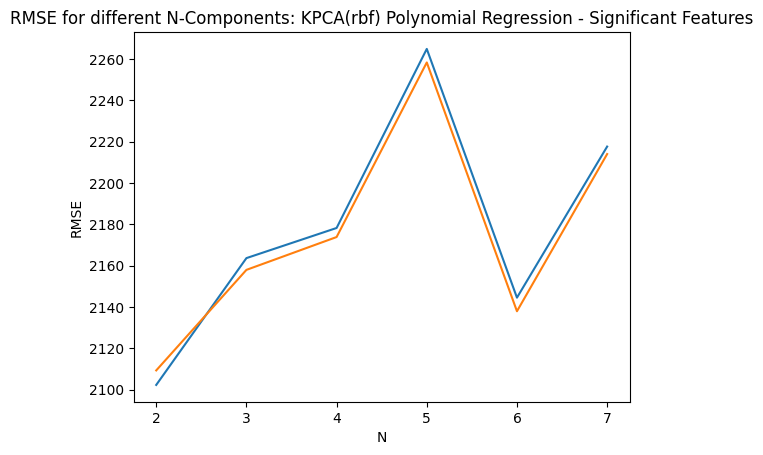

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []
degrees = np.arange(2,8)

kpcaObj = KernelPCA(n_components=3, kernel='rbf')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

for d in degrees:
    polyFeatureObj = PolynomialFeatures(degree=d)
    X_poly = polyFeatureObj.fit_transform(X_train_kpca)
    X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
    prObj = LinearRegression()
    prObj.fit(X_poly, y_train)

    #prediction on Val set
    v= polyFeatureObj.fit_transform(X_val_kpca)
    v = v[:,1:]
    y_val_pred=prObj.predict(v)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #prediction on Test set
    v= polyFeatureObj.fit_transform(X_test_kpca)
    v = v[:,1:]
    y_test_pred=prObj.predict(v)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(degrees, mse_val_list)
plt.plot(degrees, mse_test_list)
plt.title('MSE for different N-Components: KPCA(rbf) Polynomial Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(degrees, rmse_val_list)
plt.plot(degrees, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(rbf) Polynomial Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optiml - KPCA - rbf Polynomial Regression on significant features - Degrees = 2

In [ ]:
kpcaObj = KernelPCA(n_components=3, kernel='rbf')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

polyFeatureObj = PolynomialFeatures(degree=2)
X_poly = polyFeatureObj.fit_transform(X_train_kpca)
X_poly = X_poly[:,1:] #dropping the intercept column as that will be added by sklearn
prObj = LinearRegression()
prObj.fit(X_poly, y_train)

#prediction on Val set
v= polyFeatureObj.fit_transform(X_val_kpca)
v = v[:,1:]
y_val_pred=prObj.predict(v)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#prediction on Test set
v= polyFeatureObj.fit_transform(X_test_kpca)
v = v[:,1:]
y_test_pred=prObj.predict(v)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  4419746.5042245425
MSE on Test Set:  4449321.851689626
RMSE on Val Set:  2102.3193154762535
RMSE on Test Set:  2109.341568283721


### KPCA - rbf Random Forest Regression on significant features

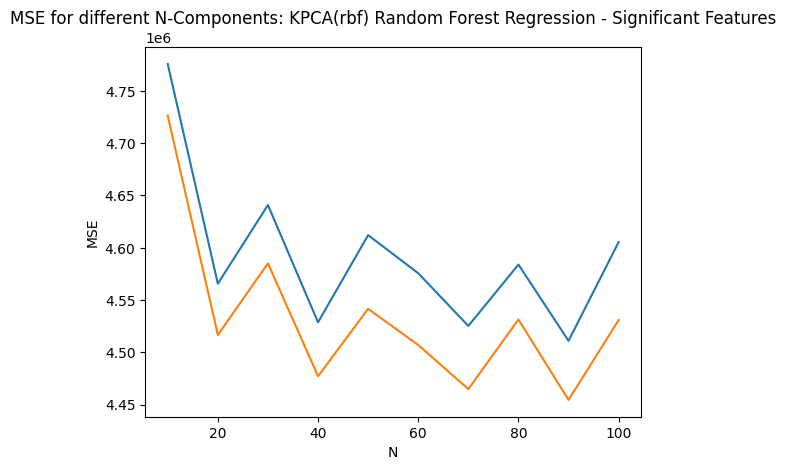

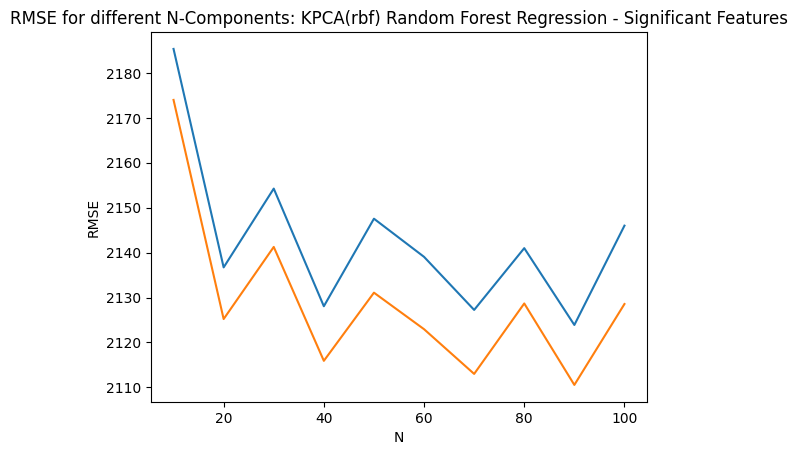

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import RandomForestRegressor

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

kpcaObj = KernelPCA(n_components = 3, kernel='rbf')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

tree_count= np.arange(10,110,10)
for trees in tree_count:
    RF_regObj = RandomForestRegressor(n_estimators=trees)
    RF_regObj.fit(X_train_kpca,y_train.ravel())

    #prediciton on Val set
    y_val_pred = RF_regObj.predict(X_val_kpca)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = sqrt(mse_val)

    #Prediction on Test Set
    y_test_pred = RF_regObj.predict(X_test_kpca)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = sqrt(mse_test)

    #Appending Lists
    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(tree_count, mse_val_list)
plt.plot(tree_count, mse_test_list)
plt.title('MSE for different N-Components: KPCA(rbf) Random Forest Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(tree_count, rmse_val_list)
plt.plot(tree_count, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(rbf) Random Forest Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - rbf Random Forest Regression on significant features - Estimators = 70

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import RandomForestRegressor

kpcaObj = KernelPCA(n_components = 3, kernel='rbf')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

RF_regObj = RandomForestRegressor(n_estimators=70)
RF_regObj.fit(X_train_kpca,y_train.ravel())

#prediciton on Val set
y_val_pred = RF_regObj.predict(X_val_kpca)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = sqrt(mse_val)

#Prediction on Test Set
y_test_pred = RF_regObj.predict(X_test_kpca)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  4617512.02705959
MSE on Test Set:  4535741.587117594
RMSE on Val Set:  2148.839693197143
RMSE on Test Set:  2129.7280547331843


### KPCA - rbf AdaBoost on significant features


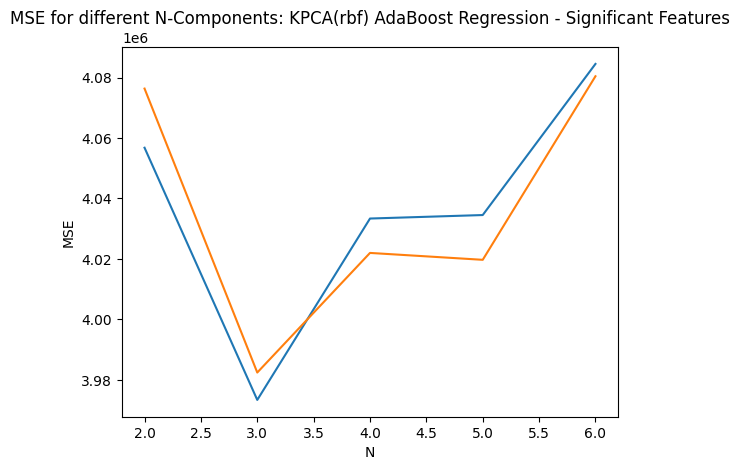

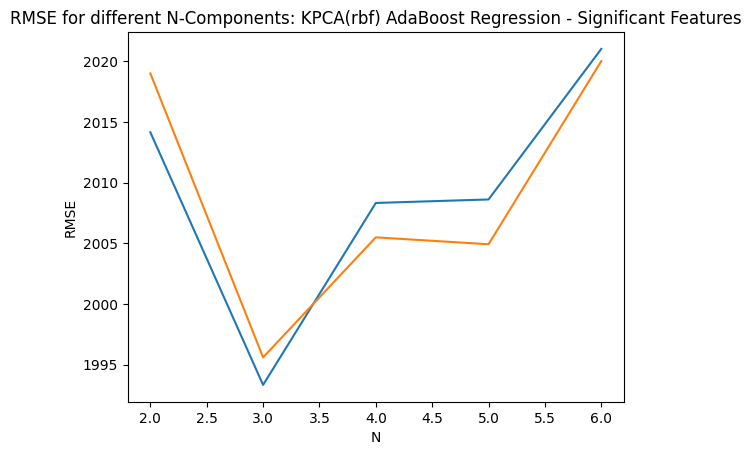

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import AdaBoostRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='rbf')

    X_train_kpca = kpcaObj.fit_transform(X_train_sig)
    X_val_kpca = kpcaObj.transform(X_val_sig)
    X_test_kpca = kpcaObj.transform(X_test_sig)

    ABReg = AdaBoostRegressor()
    ABReg.fit(X_train_kpca,y_train.ravel())
    y_val_pred2 = ABReg.predict(X_val_kpca)
    y_test_pred2 = ABReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(rbf) AdaBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(rbf) AdaBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - rbf AdaBoost on significant features - Components = 3

In [ ]:
kpcaObj = KernelPCA(n_components=3, kernel='rbf')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

ABReg = AdaBoostRegressor()
ABReg.fit(X_train_kpca,y_train.ravel())
y_val_pred2 = ABReg.predict(X_val_kpca)
y_test_pred2 = ABReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  3948951.31405807
MSE on Test Set:  3955911.983964156
RMSE on Val Set:  1987.1968483414194
RMSE on Test Set:  1988.947456310537


### KPCA - rbf GradientBoost on significant features


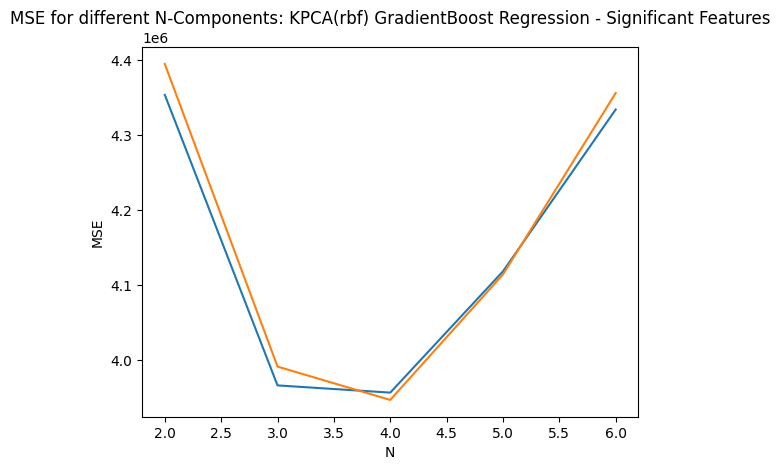

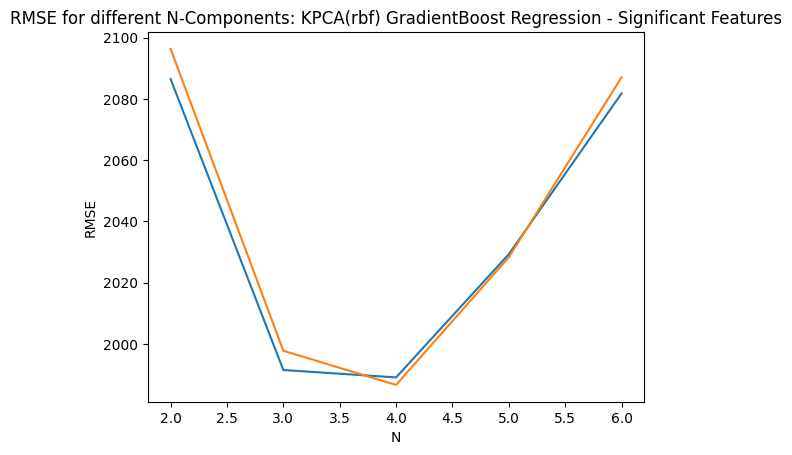

In [ ]:
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import GradientBoostingRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='rbf')

    X_train_kpca = kpcaObj.fit_transform(X_train_sig)
    X_val_kpca = kpcaObj.transform(X_val_sig)
    X_test_kpca = kpcaObj.transform(X_test_sig)

    GBReg = GradientBoostingRegressor()
    GBReg.fit(X_train_kpca,y_train.ravel())
    y_val_pred2 = GBReg.predict(X_val_kpca)
    y_test_pred2 = GBReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(rbf) GradientBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(rbf) GradientBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - rbf GradientBoost on significant features - Components = 3


In [ ]:
kpcaObj = KernelPCA(n_components=3, kernel='rbf')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

GBReg = GradientBoostingRegressor()
GBReg.fit(X_train_kpca,y_train.ravel())
y_val_pred2 = GBReg.predict(X_val_kpca)
y_test_pred2 = GBReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  3966008.4831155036
MSE on Test Set:  3991079.786159589
RMSE on Val Set:  1991.4839901730327
RMSE on Test Set:  1997.7687018670576


### KPCA - rbf XGBoost on significant features


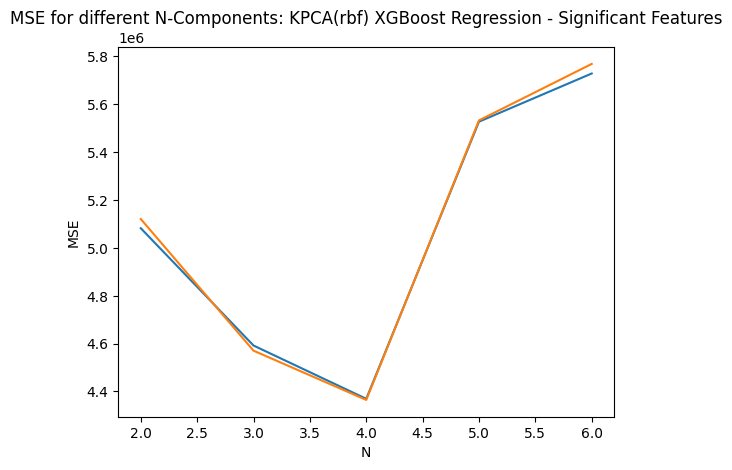

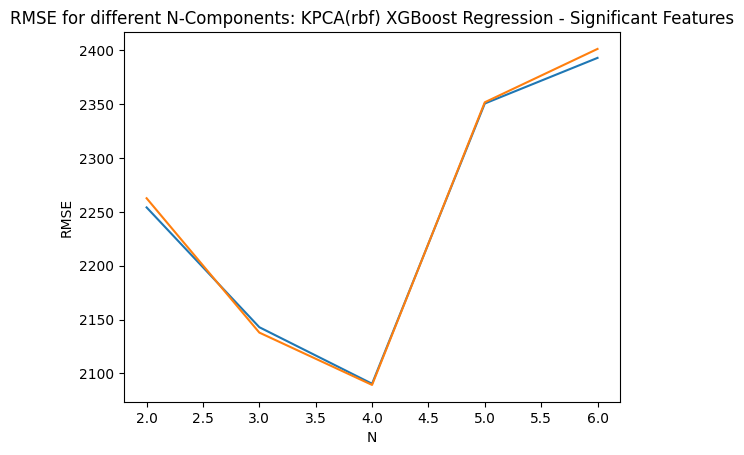

In [ ]:
from sklearn.decomposition import KernelPCA
from xgboost import XGBRegressor

x_axis_n = np.arange(2,7)

mse_val_list = []
mse_test_list = []
rmse_val_list = []
rmse_test_list = []

for i in x_axis_n:
    kpcaObj = KernelPCA(n_components=i, kernel='rbf')

    X_train_kpca = kpcaObj.fit_transform(X_train_sig)
    X_val_kpca = kpcaObj.transform(X_val_sig)
    X_test_kpca = kpcaObj.transform(X_test_sig)

    XGBReg = XGBRegressor()
    XGBReg.fit(X_train_kpca,y_train)
    y_val_pred2 = XGBReg.predict(X_val_kpca)
    y_test_pred2 = XGBReg.predict(X_test_kpca)

    mse_val = mean_squared_error(y_val, y_val_pred2)
    mse_test = mean_squared_error(y_test, y_test_pred2)

    rmse_val = sqrt(mse_val)
    rmse_test = sqrt(mse_test)

    mse_val_list.append(mse_val)
    mse_test_list.append(mse_test)
    rmse_val_list.append(rmse_val)
    rmse_test_list.append(rmse_test)

plt.plot(x_axis_n, mse_val_list)
plt.plot(x_axis_n, mse_test_list)
plt.title('MSE for different N-Components: KPCA(rbf) XGBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('MSE')
plt.show()

plt.plot(x_axis_n, rmse_val_list)
plt.plot(x_axis_n, rmse_test_list)
plt.title('RMSE for different N-Components: KPCA(rbf) XGBoost Regression - Significant Features')
plt.xlabel('N')
plt.ylabel('RMSE')
plt.show()

### Optimal - KPCA - rbf XGBoost on significant features - Components = 4


In [ ]:
kpcaObj = KernelPCA(n_components=4, kernel='rbf')

X_train_kpca = kpcaObj.fit_transform(X_train_sig)
X_val_kpca = kpcaObj.transform(X_val_sig)
X_test_kpca = kpcaObj.transform(X_test_sig)

XGBReg = XGBRegressor()
XGBReg.fit(X_train_kpca,y_train)
y_val_pred2 = XGBReg.predict(X_val_kpca)
y_test_pred2 = XGBReg.predict(X_test_kpca)

mse_val = mean_squared_error(y_val, y_val_pred2)
mse_test = mean_squared_error(y_test, y_test_pred2)

rmse_val = sqrt(mse_val)
rmse_test = sqrt(mse_test)

print("MSE on Val Set: ", mse_val)
print("MSE on Test Set: ", mse_test)
print("RMSE on Val Set: ", rmse_val)
print("RMSE on Test Set: ", rmse_test)

MSE on Val Set:  4369361.727546905
MSE on Test Set:  4364811.358373674
RMSE on Val Set:  2090.301826901298
RMSE on Test Set:  2089.2130954916192


### Scatter plot for all RMSEs

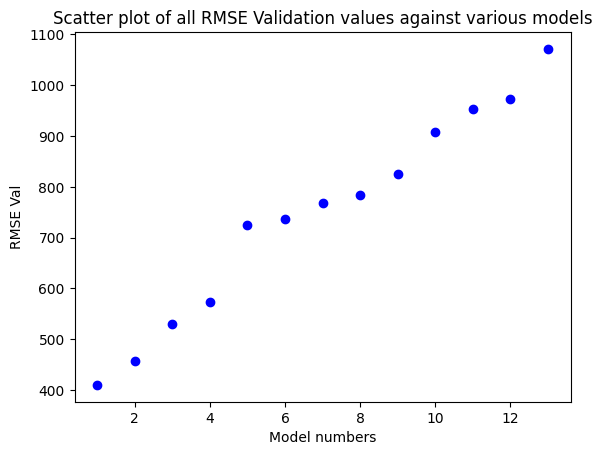

Text(0.5, 1.0, 'Scatter plot of all RMSE Test values against various models')

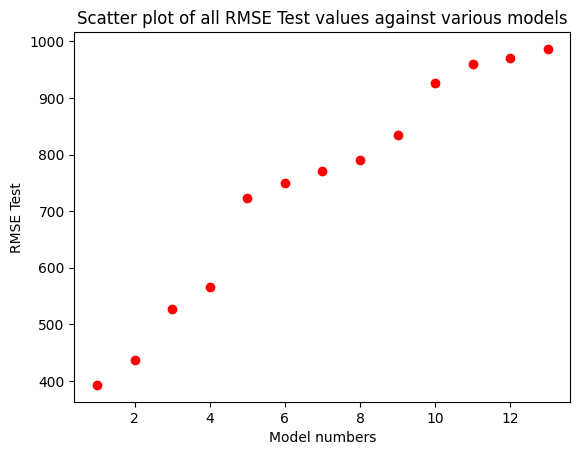

In [ ]:
import matplotlib.pyplot as plt

# Data
models = [1,2,3,4,5,6,7,8,9,10,11,12,13]

RMSE_val_values = [410.237088197826,457.4263691,530.8786136,573.5201977,725.843047,736.6866644,
           768.0479075,784.8369539,824.9060267,908.3335891,954.0752152,972.474116,1071.466857]

RMSE_test_values = [392.833583,437.2001729,527.2870597,565.5097967,723.2027152,750.4450973,
                    771.7396287,790.1314648,833.9347221,925.6635552,960.8551759,970.2666603,986.6381391]

# Creating Scatter Plot
plt.scatter(models, RMSE_val_values, color='blue', label='RMSE Validation')
plt.xlabel("Model numbers")
plt.ylabel("RMSE Val")
plt.title('Scatter plot of all RMSE Validation values against various models')
# Show the plot
plt.show()

# Creating Scatter Plot
plt.scatter(models, RMSE_test_values, color='red', label='RMSE Test')
plt.xlabel("Model numbers")
plt.ylabel("RMSE Test")
plt.title('Scatter plot of all RMSE Test values against various models')
# Show the plot
#plt.show()

### Below are the top performing models

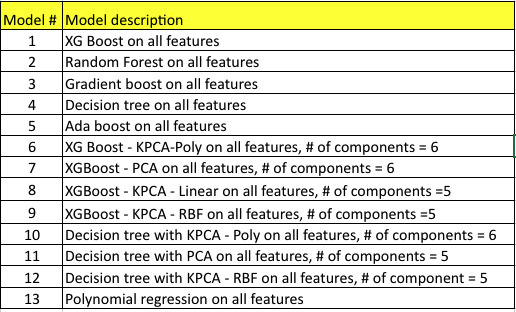



### Histogram of all models and their RMSEs

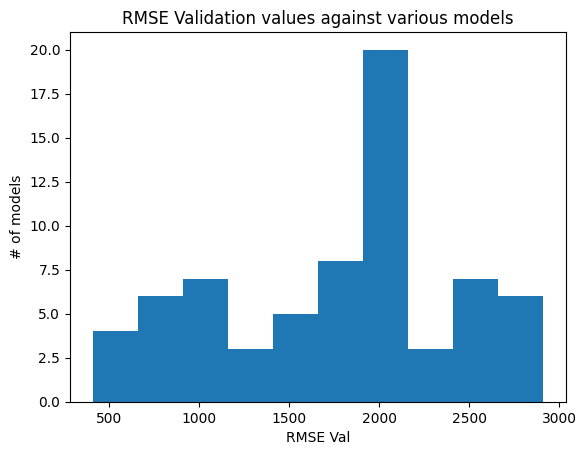

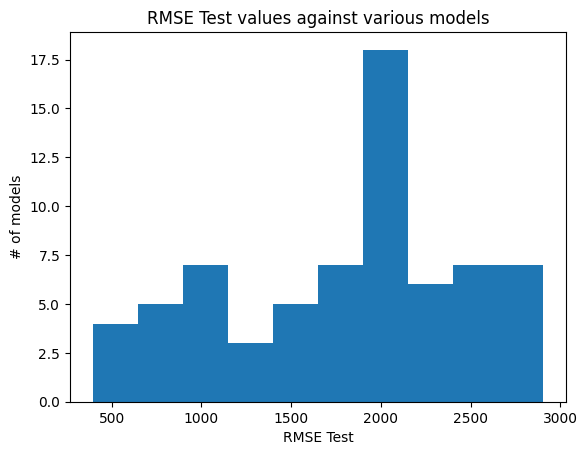

In [ ]:
import matplotlib.pyplot as plt

# Data
models = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,
          39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69]

values1 = [1804.422649, 573.5201977, 1071.466857, 457.4263691, 725.843047,
          530.8786136, 410.2370882, 2062.531958, 2762.929043,
          2584.104841, 2561.103162, 2745.178502, 2895.88736, 1804.788095,
          954.0752152, 1864.576551, 1135.331249, 1471.339957, 1193.675182,
          768.0479075, 2038.919451, 2590.186498, 2165.32991, 2498.956652,
          1996.575432, 2063.426339, 2149.338432, 1908.246513, 1140.473725,
          1701.444962, 1097.683601, 1720.858326, 1365.808336, 784.8369539,
          2038.919452, 2565.336409, 2165.329911, 2457.73092, 1997.27418,
          2063.42634, 2149.338433, 1980.12889, 908.3335891, 1964.678655,
          1519.70837, 1750.253774, 1596.942079, 736.6866644, 1980.125075,
          2759.492713, 2040.852165, 2911.256152, 2027.927858, 2187.891041,
          2629.328009, 1829.627905, 972.474116, 1524.192037, 1096.154293,
          1621.902482,1234.245746,824.9060267,1999.671514,2757.383432,2102.319315,2156.457179,2002.93661,
           1991.48399,2090.301827]

values2 = [1798.477695, 565.5097967, 986.6381391, 437.2001729, 723.2027152, 527.2870597, 392.833583,
          2069.098591, 2798.815483, 2588.441725, 2568.458604, 2735.825995, 2881.977817, 1799.989288,
          960.8551759, 1859.622089, 1137.995762, 1466.801689, 1183.820634, 771.7396287, 2043.196794,
          2572.94663, 2160.745716, 2484.990244, 1997.139375, 2066.11726, 2152.706477, 2056.591932,
          2812.820533, 1685.25366, 1089.083991, 1709.288407, 1356.216883, 790.1314648, 2043.196795,
          2546.735326, 2160.745717, 2448.028086, 1994.90819, 2066.11726, 2152.706478, 1979.253632,
          925.6635552, 1961.309146, 1534.768099, 1747.230853, 1596.131198, 750.4450973, 1979.323382,
           2761.429757, 2204.042109, 2906.7358, 2031.696334, 2190.488303, 2640.524189, 1819.804915,
          970.2666603, 1531.816365, 1086.76031, 1602.361135, 1221.231816, 833.9347221, 2003.200393,
          2759.741883, 2109.341568, 2145.235144, 2007.281251, 1997.768702, 2089.213095]



plt.hist(values1)
plt.xlabel("RMSE Val")
plt.ylabel("# of models")
plt.title('RMSE Validation values against various models')
plt.show()

plt.hist(values2)
plt.xlabel("RMSE Test")
plt.ylabel("# of models")
plt.title('RMSE Test values against various models')
plt.show()
